In [1]:
import pandas as pd
from pyspark import SparkConf
from pyspark.sql import SparkSession, functions as f, Window


In [2]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [3]:
parameters = {
    "spark.driver.maxResultSize": "3g",
    "spark.hadoop.fs.s3a.impl": "org.apache.hadoop.fs.s3a.S3AFileSystem",
    "spark.sql.execution.arrow.pyspark.enabled": True,

    # https://docs.kedro.org/en/stable/integrations/pyspark_integration.html#tips-for-maximising-concurrency-using-threadrunner
    "spark.scheduler.mode": "FAIR",
    "spark.driver.extraJavaOptions": "-Djava.security.manager=allow",
    "spark.executor.extraJavaOptions": "-Djava.security.manager=allow",
    # "spark.executor.heartbeatInterval": "3600s",
    # "spark.network.timeout": "3700s",

    "spark.sql.legacy.parquet.nanosAsLong": True,
    "spark.sql.legacy.timeParserPolicy": "LEGACY",
    "spark.driver.memory": "40g",
}

spark_conf = SparkConf().setAll(parameters.items())

In [4]:
# spark = SparkSession.builder.appName('').enableHiveSupport().config(conf=spark_conf).getOrCreate()

spark = SparkSession.builder.appName('APP').config(conf=spark_conf).getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/17 05:52:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/09/17 05:52:54 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [5]:
int_transactions = spark.read.parquet("../data/02_intermediate/int_transactions")
prm_spine = spark.read.parquet("../data/03_primary/prm_spine")
prm_branches = spark.read.parquet("../data/03_primary/prm_branches")
# ftr_transactions = spark.read.parquet("../data/04_feature/ftr_transactions")

In [6]:
int_transactions.groupBy("transaction_dt").count().orderBy(f.desc("transaction_dt")).show(truncate=False)

+-------------------+-----+
|transaction_dt     |count|
+-------------------+-----+
|2025-08-19 04:52:31|1    |
|2025-08-19 04:14:10|1    |
|2025-08-19 01:58:34|1    |
|2025-08-19 01:55:49|1    |
|2025-08-19 00:39:05|4    |
|2025-08-19 00:34:54|1    |
|2025-08-19 00:32:09|1    |
|2025-08-19 00:04:58|2    |
|2025-08-18 23:52:05|1    |
|2025-08-18 23:44:32|1    |
|2025-08-18 23:44:23|1    |
|2025-08-18 23:43:49|1    |
|2025-08-18 23:42:15|1    |
|2025-08-18 23:42:11|4    |
|2025-08-18 23:42:08|2    |
|2025-08-18 23:41:49|1    |
|2025-08-18 23:41:17|4    |
|2025-08-18 23:41:08|1    |
|2025-08-18 23:40:46|1    |
|2025-08-18 23:40:10|2    |
+-------------------+-----+
only showing top 20 rows



In [7]:
prm_branches.show()

+--------------------+---------+---------+-----------+-----------+---------+--------+
|           branch_id|longitude| latitude|branch_code|branch_type|is_active|    city|
+--------------------+---------+---------+-----------+-----------+---------+--------+
|003B2F44-3384-4D4...|      0.0|      0.0|       2280|       NULL|     true|AL KHARJ|
|006D8F31-428E-4FF...|    49.54|    25.36|       1206|         PE|     true|AL HASSA|
|00A68371-05D0-4B4...|46.634247|24.793606|       1838|         PE|    false|  RIYADH|
|017D919B-C594-487...|     NULL|     NULL|        129|       NULL|    false|  JEDDAH|
|01D07F68-67A3-42F...|    39.17| 21.56889|       1023|         PE|     true|  JEDDAH|
|01E30C30-B4B6-408...|46.818787|24.813774|       1728|         PE|     true|  RIYADH|
|01E52D08-5F0C-49E...|    46.55|    24.56|       1326|         PE|     true|  RIYADH|
|01E7599A-E311-45B...|    39.25|    21.46|       1072|         PE|     true|  JEDDAH|
|021D49AA-8189-489...|     NULL|     NULL|       1191|

In [8]:
transactions_data = int_transactions.withColumn(
    "_key",
    # f.col("customer_id")
    f.concat_ws("__", "customer_id", "customer_vehicle_id")
).withColumn(
    "_observ_end_dt",
    f.last_day(f.col("transaction_dt"))
    # f.to_date(f.date_trunc("quarter", f.col("transaction_dt")))
).filter(
    f.col("transaction_dt") < "2025-08-01"
)

In [9]:
# transactions_data.select(f.countDistinct("_key")).show()
# prm_spine.select(f.countDistinct("_id")).show()
# prm_spine.select(f.countDistinct("_key")).show()
# prm_spine.select("_key").distinct().join(
#     transactions_data.select("_key").distinct(),
#     on="_key",
#     how="inner"
# ).select(f.countDistinct("_key")).show()

In [10]:
base_sales = prm_spine.join(
    transactions_data,
    on=["_key", "_observ_end_dt"],
    how="left"
)

In [11]:
print(prm_spine.filter(
    f.col("_id") == "0001DND__966509106726"
).count())

63


In [12]:
# print(prm_spine.count())
# print(transactions_data.count())
# print(base_sales.count())
# print(base_sales.dropna(subset="transaction_id").count())

In [13]:
working_ids = [
    "403821AD-A894-4257-B8E1-63F1C14EFFBB__22EA1D18-6002-4F37-A2FF-CC088300DF12",
    "00000540-7986-4B85-A946-E1A9D913344F__F40BF538-A9A6-49E3-9623-9301AE9FD953",
    "00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477-4270-4547-B4CB-5706EA4479A0",
    "00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477-4270-4547-B4CB-5706EA4479A0",
    "00001CA5-294A-4B26-A4A1-A77D7B5B18CC__9946561B-097B-441A-BB89-95AF12D27759",
    "00001CA5-294A-4B26-A4A1-A77D7B5B18CC__9946561B-097B-441A-BB89-95AF12D27759",
    "A4F50776-4238-465E-AE0D-1C8C376CAEE2__37D422A0-E176-4D4F-8721-3B231E1ABAA0",
    "A4F507F5-769F-4C5E-9D3A-CBDD668AB6C8__4124CB72-D524-4A5E-8806-2D741083C98A",
    "A4F508D3-F915-4881-92E1-64E425B7FA71__DE8981C4-D7CF-46AC-8E18-5A844E1B5F7F",
    "A4F510D7-F015-432A-ABCB-E72594B42014__BD2B7690-017A-4437-9F8C-85518A3CF131",
    "A4F51822-9DBE-4CEF-834F-F5BC2DC179EC__B089C48B-85D1-4E8C-BBFC-33BEA68D5027",
    "A4F52279-0F64-4165-BB89-600CD3314D59__4D5A9841-55D7-492F-B695-78DE31B6A760", ## GOOD ID
    "A4F553E8-D26B-4BB7-90E3-75D3F2950064__D71989F6-16FF-48D5-919B-4BA2286EF08D", ## GOOD ID
    "ADF9EA7B-950A-4DF8-B3E4-FA44F535916A__E89BEB7A-E3C4-49B1-B137-5347EE53626D",
    "19D9BC46-B71F-46E1-8A7D-5A4F48AAE2FF__6B23EF10-4823-4457-A516-E3A69F2139BF",
    "7AE928E6-4908-4E9A-9B83-93B773ABC398__92F5C240-D131-43FF-B705-024580651AF3",
    "884884AE-CAAF-4257-B425-13E8FF898B6F__F0BA9438-43A9-457A-9E83-25D9443362CD",
    "B3A8C9F7-653F-4EDD-A9BB-43A1F78954BA__885CCCBF-9231-4F44-BB48-9742A3F40609",
    "81FD6E6F-27CB-42A6-AAF0-882F8A255DDB__B650A67C-B8FC-4730-8A86-3D4A481BABA0",
    "1B155384-09D1-478C-9EAA-99AC2D328D29__4A99289D-A72E-48AE-86B2-AD8A5E57FFD0",
    "B7C56453-865E-4417-BB3C-1BEEB4FF5816__6B6B5CB2-08B9-4182-AAC7-13D8D14B7BCB",
    "A4629DC6-6624-4D63-99AC-5D620DAFE670__507B34B6-F94A-4D27-BF3F-1543EFD6135A",
    "50908F70-D5E8-42A4-98E0-95D9589FF6DE__71404FD4-5CCF-486B-AC6C-60EDCA23E8F0",
]

In [14]:
# based on mileage

working_ids = [
    "4192SHB__966542578206", # Low
    "1701GVB__966555355204",
    "9106RJJ__966503888248",
    "5937ENJ__966561583777",
    "3485XHA__966552999169",
    "2060JRR__966550150127",
    "3751NUA__966545080503",
    "7045DED__966533405985",
    "5964TLA__966568910803",
    "9558TUB__966583067697",
    "7581DXD__966508439991", # MED
    "6121JUB__966552088719",
    "6689ZKB__966556778840",
    "1498LAD__966591339863",
    "2417HVA__966566796398",
    "8343TNJ__966568878313",
    "5572URB__966546619445",
    "5801KLB__966530520635",
    "1396KTD__966573315735",
    "5437NXD__966543167893",
    "7915KED__966557003376", # High
    "9754SXR__966537585441",
    "4613HSA__966539094675",
    "8573VED__966599203521",
    "8980ANR__966599517817",
    "8584XHD__966542995539",
    "2997HBB__966543564959",
    "2975NHA__966553817223",
    "4389LTB__966537422497",
    "2236SXB__966534646520",
]

# Mileage model

In [15]:
win_id = Window.partitionBy("_id")
win_id_monthly = Window.partitionBy("_id").orderBy("_observ_end_dt")

## Client Mileage Table

In [16]:
base_sales = base_sales.withColumn(
    "major_category",
    f.when(
        f.lower("product_category").isin("oil"),
        "oil"
    ).when(
        f.lower("product_category").isin("oil synthetic"),
        "oil_synthetic"
    ).when(
        f.contains(f.lower("product_category"), f.lit("oil filter")),
        "oil_filter"
    ).when(
        f.contains(f.lower("product_category"), f.lit("air filter")),
        "air_filter"
    ).when(
        f.contains(f.lower("product_category"), f.lit("ac ")),
        "ac"
    ).when(
        f.contains(f.lower("product_category"), f.lit("tyres")),
        "tyres"
    ).when(
        f.contains(f.lower("product_category"), f.lit("batt")),
        "batteries"
    ).when(
        f.contains(f.lower("product_category"), f.lit("transmission")),
        "transmission"
    ).when(
        f.contains(f.lower("product_category"), f.lit("engine")),
        "engine"
    ).when(
        f.contains(f.lower("product_category"), f.lit("additives")),
        "additives"
    ).when(
        f.contains(f.lower("product_category"), f.lit("plug")),
        "plug"
    ).when(
        f.contains(f.lower("product_category"), f.lit("fuel")),
        "fuel"
    ).when(
        f.contains(f.lower("product_category"), f.lit("gear")),
        "gear"
    ).when(
        f.contains(f.lower("product_category"), f.lit("brake")),
        "brake"
    ).when(
        f.contains(f.lower("product_category"), f.lit("coolant")),
        "coolant"
    ).otherwise("others")
)

In [17]:
w_id_all = Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)
w_id_last_3 = Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(-3, -1)
w_id_next_3 = Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(1, 3)

w_id_transactions = Window.partitionBy("_id").orderBy("transaction_dt")

w_id_past_transactions = Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(Window.unboundedPreceding, -1)
w_id_next_transactions = Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(1, Window.unboundedFollowing)


In [18]:
mileage_sales = base_sales.groupBy(
    "_id", "_observ_end_dt", "transaction_id", "transaction_dt"
).agg(
    f.min("current_mileage").alias("current_mileage"),
    f.max("current_mileage").alias("max_mileage")
).filter(
    f.col("transaction_id").isNotNull()
)

In [19]:
mileage_sales.filter(
    f.col("_id") == working_ids[0] # working_ids[10] # working_ids[20]
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

25/09/17 05:53:04 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


+---------------------+--------------+------------------------------------+-------------------+---------------+-----------+
|_id                  |_observ_end_dt|transaction_id                      |transaction_dt     |current_mileage|max_mileage|
+---------------------+--------------+------------------------------------+-------------------+---------------+-----------+
|4192SHB__966542578206|2023-06-30    |E9E3E648-9FCA-439C-A870-D5F209F592FB|2023-06-25 21:04:04|257810.0       |257810.0   |
|4192SHB__966542578206|2023-08-31    |6B6E099C-A0A9-47D9-8245-BDE7E7568148|2023-08-11 17:58:20|262757.0       |262757.0   |
|4192SHB__966542578206|2023-09-30    |352F9190-42BB-4CBD-9718-B9D33A4A44F1|2023-09-10 18:29:11|267798.0       |267798.0   |
|4192SHB__966542578206|2023-11-30    |A04E88DD-0656-4F12-A7B6-1505B5636034|2023-11-29 22:00:35|273224.0       |273224.0   |
|4192SHB__966542578206|2024-01-31    |C37F4806-BAA4-4D4A-8CE1-E5225531E3F7|2024-01-12 21:37:51|278227.0       |278227.0   |
|4192SHB

In [20]:
x = mileage_sales.withColumn(
    "current_mileage",
    f.when(
        (f.col("current_mileage").isNotNull()) &
        (f.col("current_mileage") < 100),
        None
    ).otherwise(f.col("current_mileage"))
).withColumn(
    "current_mileage",
    f.when(
        (f.col("current_mileage").isNotNull()) &
        (f.max("current_mileage").over(Window.partitionBy("_id").orderBy("transaction_dt").rowsBetween(Window.unboundedPreceding, -1)) > 900000) &
        (f.col("current_mileage") < 900000),
        f.col("current_mileage") + 1000000
    ).otherwise(f.col("current_mileage"))
).withColumn(
    "current_mileage",
    f.when(
        (f.col("current_mileage").isNotNull()) &
        (f.col("current_mileage") == f.last("current_mileage", ignorenulls=True).over(w_id_past_transactions)) &
        (f.date_diff("transaction_dt", f.last("transaction_dt", ignorenulls=True).over(w_id_past_transactions)) > 0),
        None
    ).otherwise(f.col("current_mileage"))
).withColumn(
    "transaction_dt",
    f.when(
        f.col("current_mileage").isNull(),
        None
    ).otherwise(f.col("transaction_dt"))
).withColumn(
    "last_transaction_dt",
    f.last("transaction_dt", ignorenulls=True).over(w_id_past_transactions),
).withColumn(
    "last_current_mileage",
    f.last("current_mileage", ignorenulls=True).over(w_id_past_transactions),
).withColumn(
    "last_2_transaction_dt",
    f.last("transaction_dt", ignorenulls=True).over(w_id_transactions.rowsBetween(Window.unboundedPreceding, -2)),
).withColumn(
    "last_2_current_mileage",
    f.last("current_mileage", ignorenulls=True).over(w_id_transactions.rowsBetween(Window.unboundedPreceding, -2)),
).withColumn(
    "run_mileage",
    f.col("current_mileage") - f.col("last_current_mileage")
).withColumn(
    "run_period",
    f.date_diff("transaction_dt", "last_transaction_dt")
).withColumn(
    "mpd",
    f.col("run_mileage") / f.col("run_period")
).withColumn(
    "run_mileage_2",
    f.col("current_mileage") - f.col("last_2_current_mileage")
).withColumn(
    "run_period_2",
    f.date_diff("transaction_dt", "last_2_transaction_dt")
).withColumn(
    "mpd_2",
    f.col("run_mileage_2") / f.col("run_period_2")
).withColumn(
    "avg_mpd",
    f.mean("mpd").over(w_id_past_transactions)
).withColumn(
    "std_mpd",
    f.std("mpd").over(w_id_past_transactions)
).withColumn(
    "delta_mpd",
    f.abs(f.col("mpd") - f.mean("mpd").over(w_id_past_transactions))
).withColumn(
    "current_mileage",
    f.when(
        (f.abs(f.col("mpd") - f.mean("mpd").over(w_id_past_transactions)) > (f.std("mpd").over(w_id_past_transactions) * 2)) &
        (f.abs(f.col("mpd_2") - f.mean("mpd").over(w_id_past_transactions)) > (f.std("mpd").over(w_id_past_transactions) * 2)),
        None
    ).otherwise(f.col("current_mileage"))
).withColumn(
    "transaction_dt",
    f.when(
        f.col("current_mileage").isNull(),
        None
    ).otherwise(f.col("transaction_dt"))
).withColumn(
    "last_transaction_dt",
    f.last("transaction_dt", ignorenulls=True).over(w_id_past_transactions),
).withColumn(
    "last_current_mileage",
    f.last("current_mileage", ignorenulls=True).over(w_id_past_transactions),
).withColumn(
    "run_mileage",
    f.col("current_mileage") - f.col("last_current_mileage")
).withColumn(
    "run_period",
    f.date_diff("transaction_dt", "last_transaction_dt")
).withColumn(
    "mpd",
    f.col("run_mileage") / f.col("run_period")
).withColumn(
    "first_mpd",
    f.round(f.first("mpd", ignorenulls=True).over(w_id_next_transactions))
).withColumn(
    "mpd",
    f.when(
        f.col("mpd").isNull(),
        f.round(f.first("mpd", ignorenulls=True).over(w_id_next_transactions))
    ).otherwise(f.col("mpd"))
)

In [21]:
# # 2m

# x.select(
#     f.mean(
#         f.when(
#             (f.col("mpd") > 300),
#             1
#         ).otherwise(0)
#     ),
#     f.mean(
#         f.when(
#             f.col("mpd") < 0,
#             1
#         ).otherwise(0)
#     ),
#     f.round(f.min("mpd")),
#     f.round(f.median("mpd")),
#     f.round(f.percentile("mpd", 0.05)),
#     f.round(f.percentile("mpd", 0.1)),
#     f.round(f.percentile("mpd", 0.25)),
#     f.round(f.percentile("mpd", 0.5)),
#     f.round(f.percentile("mpd", 0.75)),
#     f.round(f.percentile("mpd", 0.9)),
#     f.round(f.percentile("mpd", 0.95)),
#     f.round(f.std("mpd")),
#     f.round(f.mean(
#         f.when(
#             (f.col("mpd") >= 16) &
#             (f.col("mpd") < 309),
#             f.col("mpd")
#         ).otherwise(None)
#     )).alias("filtered_avg"),
#     f.round(f.std(
#         f.when(
#             (f.col("mpd") >= 16) &
#             (f.col("mpd") < 309),
#             f.col("mpd")
#         ).otherwise(None)
#     )).alias("filtered_std"),
#     f.round(f.mean("mpd")),
#     f.round(f.max("mpd")),
# ).show()

In [22]:
# 2m

client_mileage_df = x.select(
    "_id",
    "_observ_end_dt",
    "transaction_id",
    "current_mileage"
)

# client_mileage_df.show(5, truncate=False)

In [23]:
client_mileage_df.filter(
    f.col("_id") == working_ids[0] # working_ids[10] # working_ids[20]
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+------------------------------------+---------------+
|_id                  |_observ_end_dt|transaction_id                      |current_mileage|
+---------------------+--------------+------------------------------------+---------------+
|4192SHB__966542578206|2023-06-30    |E9E3E648-9FCA-439C-A870-D5F209F592FB|257810.0       |
|4192SHB__966542578206|2023-08-31    |6B6E099C-A0A9-47D9-8245-BDE7E7568148|262757.0       |
|4192SHB__966542578206|2023-09-30    |352F9190-42BB-4CBD-9718-B9D33A4A44F1|267798.0       |
|4192SHB__966542578206|2023-11-30    |A04E88DD-0656-4F12-A7B6-1505B5636034|273224.0       |
|4192SHB__966542578206|2024-01-31    |C37F4806-BAA4-4D4A-8CE1-E5225531E3F7|278227.0       |
|4192SHB__966542578206|2024-03-31    |5C55BD00-F03A-411B-9AA0-575C6685AAD1|288226.0       |
|4192SHB__966542578206|2024-07-31    |AA2FEF4D-273A-46FE-95FA-8994B2A310F4|292570.0       |
|4192SHB__966542578206|2024-11-30    |6120D3F5-B32F-4F17-9AEE-8308EEB3F30B|29895

## Client Product Mileage Pivot Table

In [24]:
w_id_observ = Window.partitionBy("_id").orderBy("_observ_end_dt")
w_id_past_observ = Window.partitionBy("_id").orderBy("_observ_end_dt").rowsBetween(Window.unboundedPreceding, -1)
w_id_next_observ = Window.partitionBy("_id").orderBy("_observ_end_dt").rowsBetween(1, Window.unboundedFollowing)

In [25]:
# 2m

client_product_df = base_sales.select(
    "_id", "_observ_end_dt", "transaction_id", "transaction_dt", "major_category"
).filter(
    f.col("transaction_id").isNotNull()
).drop("transaction_id")

# client_product_df.show(5, truncate=False)

In [26]:
client_product_df.filter(
    f.col("_id") == working_ids[0] # working_ids[10] # working_ids[20]
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+-------------------+--------------+
|_id                  |_observ_end_dt|transaction_dt     |major_category|
+---------------------+--------------+-------------------+--------------+
|4192SHB__966542578206|2023-06-30    |2023-06-25 21:04:04|oil           |
|4192SHB__966542578206|2023-08-31    |2023-08-11 17:58:20|oil           |
|4192SHB__966542578206|2023-09-30    |2023-09-10 18:29:11|oil           |
|4192SHB__966542578206|2023-11-30    |2023-11-29 22:00:35|oil           |
|4192SHB__966542578206|2024-01-31    |2024-01-12 21:37:51|oil           |
|4192SHB__966542578206|2024-03-31    |2024-03-09 17:05:03|oil           |
|4192SHB__966542578206|2024-07-31    |2024-07-25 20:57:12|oil           |
|4192SHB__966542578206|2024-11-30    |2024-11-10 21:09:38|oil           |
+---------------------+--------------+-------------------+--------------+



In [27]:
# 5m

client_product_mileage_df = base_sales.select(
    "_id", "_observ_end_dt"
).distinct().join(
    client_mileage_df,
    on=["_id", "_observ_end_dt"],
    how="left"
).join(
    client_product_df,
    on=["_id", "_observ_end_dt"],
    how="left"
).orderBy("_id", "_observ_end_dt")


In [28]:
# client_product_mileage_df.show(50, truncate=False)

client_product_mileage_df.filter(
    f.col("_id") == working_ids[0] # working_ids[10] # working_ids[20]
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+------------------------------------+---------------+-------------------+--------------+
|_id                  |_observ_end_dt|transaction_id                      |current_mileage|transaction_dt     |major_category|
+---------------------+--------------+------------------------------------+---------------+-------------------+--------------+
|4192SHB__966542578206|2023-06-30    |E9E3E648-9FCA-439C-A870-D5F209F592FB|257810.0       |2023-06-25 21:04:04|oil           |
|4192SHB__966542578206|2023-07-31    |NULL                                |NULL           |NULL               |NULL          |
|4192SHB__966542578206|2023-08-31    |6B6E099C-A0A9-47D9-8245-BDE7E7568148|262757.0       |2023-08-11 17:58:20|oil           |
|4192SHB__966542578206|2023-09-30    |352F9190-42BB-4CBD-9718-B9D33A4A44F1|267798.0       |2023-09-10 18:29:11|oil           |
|4192SHB__966542578206|2023-10-31    |NULL                                |NULL           |NULL               |

## Client Product Features Pivot Table

In [29]:
# 18m

mileage_pivot_product_view_df = client_product_mileage_df.filter(
    f.col("major_category").isin(f.lit("oil"), f.lit("oil_synthetic"))
).groupBy(
    "_id", "_observ_end_dt",
).pivot(
    "major_category"
).agg(
    f.last("transaction_dt", ignorenulls=True).alias("last_transaction_dt"), 
    f.last("current_mileage", ignorenulls=True).alias("last_mileage"),
)

drop_columns = [col for col in mileage_pivot_product_view_df.columns if "null" in col]

mileage_pivot_product_view_df = mileage_pivot_product_view_df.drop(*drop_columns)

# print(mileage_pivot_product_view_df.count())

In [30]:
mileage_pivot_product_view_df.filter(
    f.col("_id") == working_ids[0] # working_ids[10] # working_ids[20]
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+-----------------------+----------------+---------------------------------+--------------------------+
|_id                  |_observ_end_dt|oil_last_transaction_dt|oil_last_mileage|oil_synthetic_last_transaction_dt|oil_synthetic_last_mileage|
+---------------------+--------------+-----------------------+----------------+---------------------------------+--------------------------+
|4192SHB__966542578206|2023-06-30    |2023-06-25 21:04:04    |257810.0        |NULL                             |NULL                      |
|4192SHB__966542578206|2023-08-31    |2023-08-11 17:58:20    |262757.0        |NULL                             |NULL                      |
|4192SHB__966542578206|2023-09-30    |2023-09-10 18:29:11    |267798.0        |NULL                             |NULL                      |
|4192SHB__966542578206|2023-11-30    |2023-11-29 22:00:35    |273224.0        |NULL                             |NULL                      |
|4192SHB__966

In [31]:
# 10m

mileage_pivot_customer_view_df = client_product_mileage_df.groupBy(
    "_id", "_observ_end_dt"
).agg(
    f.last("transaction_dt", ignorenulls=True).alias("customer_transaction_dt"),
    f.last("transaction_id", ignorenulls=True).alias("customer_last_monthly_transaction_id"),
    f.last("current_mileage", ignorenulls=True).alias("customer_current_mileage"),
)

# join product and customer tables
client_mileage_product_pivot = mileage_pivot_customer_view_df.join(
    mileage_pivot_product_view_df,
    on=["_id", "_observ_end_dt"],
    how="left"
)

In [32]:
# 3m

client_mileage_product_pivot.filter(
    f.col("_id") == working_ids[0] # working_ids[10] # working_ids[20]
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+-----------------------+------------------------------------+------------------------+-----------------------+----------------+---------------------------------+--------------------------+
|_id                  |_observ_end_dt|customer_transaction_dt|customer_last_monthly_transaction_id|customer_current_mileage|oil_last_transaction_dt|oil_last_mileage|oil_synthetic_last_transaction_dt|oil_synthetic_last_mileage|
+---------------------+--------------+-----------------------+------------------------------------+------------------------+-----------------------+----------------+---------------------------------+--------------------------+
|4192SHB__966542578206|2023-06-30    |2023-06-25 21:04:04    |E9E3E648-9FCA-439C-A870-D5F209F592FB|257810.0                |2023-06-25 21:04:04    |257810.0        |NULL                             |NULL                      |
|4192SHB__966542578206|2023-07-31    |NULL                   |NULL                          

In [33]:
major_categories_list = ["ac", "additives", "air_filter", "batteries", "brake", "coolant", "engine", "fuel", "gear", "oil", "oil_filter", "oil_synthetic", "plug", "transmission", "tyres"]
major_categories_list = ["oil","oil_synthetic"]
major_categories_list = ["customer"]

In [34]:
# 8m

# for cat in major_categories_list:

client_mileage_product_pivot = client_mileage_product_pivot.withColumn(
    f"customer_last_current_mileage",
    f.last(f"customer_current_mileage", ignorenulls=True).over(w_id_past_observ)
).withColumn(
    f"customer_last_transaction_dt",
    f.last(f"customer_transaction_dt", ignorenulls=True).over(w_id_past_observ)
).withColumn(
    f"customer_last_transaction_id",
    f.last(f"customer_last_monthly_transaction_id", ignorenulls=True).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
).withColumn(
    f"customer_run_mileage",
    f.col(f"customer_current_mileage") - f.col(f"customer_last_current_mileage")
).withColumn(
    f"customer_run_period",
    f.date_diff(f"customer_transaction_dt", f"customer_last_transaction_dt")
).withColumn(
    f"customer_mileage_per_day",
    f.col(f"customer_run_mileage") / f.col(f"customer_run_period")
).withColumn(
    f"customer_mileage_per_day",
    f.when(
        f.col(f"customer_mileage_per_day") < 0,
        None
    ).when(
        f.col(f"customer_mileage_per_day") > 700,
        None
    ).otherwise(f.col(f"customer_mileage_per_day"))
).withColumn(
    f"customer_filled_mileage_per_day",
    f.when(
        f.col("customer_mileage_per_day").isNull(),
        f.first(f"customer_mileage_per_day", ignorenulls=True).over(w_id_next_observ)
    ).otherwise(f.col("customer_mileage_per_day"))
).withColumn(
    f"customer_avg_mileage_per_day",
    f.when(
        f.col("customer_mileage_per_day").isNotNull(),
        f.mean(
            f.when(
                f.col("customer_mileage_per_day").isNull(),
                f.first(f"customer_mileage_per_day", ignorenulls=True).over(w_id_next_observ)
            ).otherwise(f.col("customer_mileage_per_day"))
        ).over(w_id_observ.rowsBetween(-11, 0))
    ).otherwise(None)
).withColumn(
#     f"customer_avg_mileage_per_day",
#     f.when(
#         f.col(f"customer_avg_mileage_per_day").isNull(),
#         f.round(f.first(f"customer_avg_mileage_per_day", ignorenulls=True).over(w_id_next_observ))
#     ).otherwise(f.col(f"customer_avg_mileage_per_day"))
# ).withColumn(
    f"customer_avg_mileage_per_day",
    f.when(
        f.col(f"customer_mileage_per_day").isNull(),
        f.round(f.last(f"customer_avg_mileage_per_day", ignorenulls=True).over(w_id_past_observ))
    ).otherwise(f.col(f"customer_avg_mileage_per_day"))
).withColumn(
    f"customer_last_mileage_per_day",
    f.last(f"customer_mileage_per_day", ignorenulls=True).over(w_id_observ.rowsBetween(-11, -1))
)

mileage_selected_cols = [col for col in client_mileage_product_pivot.columns if "mileage" in col]
last_trx_selected_cols = [col for col in client_mileage_product_pivot.columns if "_last_transaction" in col]

client_mileage_product_pivot_selected = client_mileage_product_pivot.select("_id", "_observ_end_dt", *mileage_selected_cols, *last_trx_selected_cols)

In [35]:
# # 4m

# client_mileage_product_pivot_selected.filter(
#     f.col("_id") == working_ids[10] # working_ids[10] # working_ids[20]
# ).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

In [36]:
# for id in ["1439URD__966546646220", "2895UXD__966541124089", "1397KDB__966575626543", "1945RUJ__966531861683", "6360GBJ__966500771836", "2611TGJ__966552702166", "7602XJB__966544041767"]:
#     client_mileage_product_pivot.filter(
#         f.col("_id") == id
#     ).select("_id", "_observ_end_dt", "customer_current_mileage", "customer_transaction_dt", "customer_last_current_mileage", "customer_last_transaction_dt", "customer_run_mileage", "customer_run_period", "customer_mileage_per_day").orderBy("_id", "_observ_end_dt").show(60, truncate=False)

#     client_mileage_product_pivot.filter(
#         f.col("_id") == id
#     ).select("_id", "_observ_end_dt", "customer_current_mileage", "customer_transaction_dt", "customer_last_current_mileage", "customer_last_transaction_dt", "customer_run_mileage", "customer_run_period", "customer_mileage_per_day").orderBy("_id", "_observ_end_dt").write.csv(f"month_by_month_visits_id__{id}.csv", mode="overwrite")

In [37]:
# # 4m

# client_mileage_product_pivot_selected.groupBy(
#     "_id"
# ).agg(
#     f.sum(f.col("customer_mileage_per_day").isNotNull().cast('int')).alias("n_mileages"),
#     f.last("customer_mileage_per_day", ignorenulls=True).alias("last_mileage")
# ).orderBy(f.desc("n_mileages"), f.desc("last_mileage")).show(50, truncate=False)

In [38]:
# client_mileage_product_pivot.count(), base_sales.select("_id", "_observ_end_dt").distinct().count()

In [39]:
# # 2m

# client_mileage_product_pivot.filter(
#     f.col("_id") == "0016VBD__966501222843"
# ).show(50, truncate=False)

## Client Product Forecast info

In [40]:
# client_mileage_product_pivot.count(), base_sales.select("_id", "_observ_end_dt").distinct().count()

In [41]:
# 0m

client_mileage_product_forecast = base_sales.select(
    "_id", "_observ_end_dt"
).distinct().join(
    client_mileage_product_pivot_selected,
    on=["_id", "_observ_end_dt"],
    how="left"
).orderBy("_id", "_observ_end_dt")

# client_mileage_product_forecast.show(50, truncate=False)

In [42]:
# 6m
client_mileage_product_forecast.filter(
    f.col("_id") == working_ids[0] # working_ids[10] # working_ids[20]
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+------------------------+----------------+--------------------------+-----------------------------+--------------------+------------------------+-------------------------------+----------------------------+-----------------------------+-----------------------+---------------------------------+----------------------------+------------------------------------+
|_id                  |_observ_end_dt|customer_current_mileage|oil_last_mileage|oil_synthetic_last_mileage|customer_last_current_mileage|customer_run_mileage|customer_mileage_per_day|customer_filled_mileage_per_day|customer_avg_mileage_per_day|customer_last_mileage_per_day|oil_last_transaction_dt|oil_synthetic_last_transaction_dt|customer_last_transaction_dt|customer_last_transaction_id        |
+---------------------+--------------+------------------------+----------------+--------------------------+-----------------------------+--------------------+------------------------+-------------------

In [43]:
# 2m

# client_mileage_product_forecast.count(), base_sales.select("_id", "_observ_end_dt").distinct().count()

In [44]:
# 6m

client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    f"customer_days_since_last_trx",
    f.date_diff("_observ_end_dt", f"customer_last_transaction_dt")
).withColumn(
    f"customer_mileage_per_day",
    f.when(
        f.col(f"customer_mileage_per_day") < 0,
        f.lit(None)
    ).otherwise(f.col(f"customer_mileage_per_day"))
).withColumn(
    f"customer_avg_mileage_per_day",
    f.when(
        f.col(f"customer_avg_mileage_per_day").isNull(),
        f.lit(55) # 25000 km in a year
    ).otherwise(f.col(f"customer_avg_mileage_per_day"))
).withColumn(
    f"customer_last_mileage_per_day",
    f.when(
        f.col(f"customer_last_mileage_per_day").isNull(),
        f.lit(44) # 25000 km in a year
    ).otherwise(f.col(f"customer_last_mileage_per_day"))
).withColumn(
#     f"customer_days_until_change",
#     f.when(
#         f.lit(cat == "oil"),
#         f.floor(f.lit(5000) / f.col(f"customer_avg_mileage_per_day"))
#     ).when(
#         f.lit(cat == "oil_synthetic"),
#         f.floor(f.lit(10000) / f.col(f"customer_avg_mileage_per_day"))
#     ).otherwise(None)
# ).withColumn(
    f"customer_mileage_delta",
    f.when(
        f.col("customer_current_mileage").isNull(),
        f.col(f"customer_days_since_last_trx") * f.col(f"customer_avg_mileage_per_day")
    ).otherwise(f.col(f"customer_current_mileage"))
).withColumn(
    f"customer_mileage_forecast",
    f.when(
        f.col("customer_current_mileage").isNull(),
        f.col(f"customer_mileage_delta") + f.col("customer_last_current_mileage")
    ).otherwise(f.col("customer_current_mileage"))
).withColumn(
    f"customer_mileage_last_forecast",
    f.lag(f"customer_mileage_forecast").over(w_id_observ)
).withColumn(
    f"customer_mileage_last_forecast",
    f.when(
        f.col(f"customer_mileage_last_forecast") > f.col(f"customer_mileage_forecast"),
        None
    ).otherwise(f.col(f"customer_mileage_last_forecast"))
)

# client_mileage_product_forecast.filter(
#     f.col("_id") == "0001AUV__966551386197"
# ).show(70, truncate=False)

In [45]:
client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    "oil_last_mileage",
    f.when(
        f.col("oil_last_mileage").isNull(),
        f.last("oil_last_mileage", ignorenulls=True).over(w_id_past_observ)
    ).otherwise(f.col("oil_last_mileage"))
).withColumn(
    "oil_synthetic_last_mileage",
    f.when(
        f.col("oil_synthetic_last_mileage").isNull(),
        f.last("oil_synthetic_last_mileage", ignorenulls=True).over(w_id_past_observ)
    ).otherwise(f.col("oil_synthetic_last_mileage"))
).withColumn(
    "oil_last_transaction_dt",
    f.when(
        f.col("oil_last_transaction_dt").isNull(),
        f.last("oil_last_transaction_dt", ignorenulls=True).over(w_id_past_observ)
    ).otherwise(f.col("oil_last_transaction_dt"))
).withColumn(
    "oil_synthetic_last_transaction_dt",
    f.when(
        f.col("oil_synthetic_last_transaction_dt").isNull(),
        f.last("oil_synthetic_last_transaction_dt", ignorenulls=True).over(w_id_past_observ)
    ).otherwise(f.col("oil_synthetic_last_transaction_dt"))
).withColumn(
    "delta_last_mineral_oil_change",
    f.col("customer_mileage_forecast") - f.col("oil_last_mileage")
).withColumn(
    "delta_last_synthetic_oil_change",
    f.col("customer_mileage_forecast") - f.col("oil_synthetic_last_mileage")
).withColumn(
    "last_delta_last_mineral_oil_change",
    f.lag("delta_last_mineral_oil_change").over(w_id_observ)
).withColumn(
    "last_delta_last_synthetic_oil_change",
    f.lag("delta_last_synthetic_oil_change").over(w_id_observ)
).withColumn(
    "customer_mineral_oil",
    f.when(
        (f.col("oil_last_transaction_dt").isNotNull()) &
        (f.col("oil_synthetic_last_transaction_dt").isNull()),
        f.lit(1)
    ).when(
        (f.col("oil_last_transaction_dt").isNotNull()) &
        (f.col("oil_last_transaction_dt") > f.col("oil_synthetic_last_transaction_dt")),
        f.lit(1)
    ).otherwise(0)
).withColumn(
    "customer_synthetic_oil",
    f.when(
        (f.col("oil_synthetic_last_transaction_dt").isNotNull()) &
        (f.col("oil_last_transaction_dt").isNull()),
        f.lit(1)
    ).when(
        (f.col("oil_synthetic_last_transaction_dt").isNotNull()) &
        (f.col("oil_synthetic_last_transaction_dt") > f.col("oil_last_transaction_dt")),
        f.lit(1)
    ).otherwise(0)
).withColumn(
    "is_due_mineral_oil",
    f.when(
        (f.col("customer_mineral_oil") == f.lit(1)) &
        (f.floor(f.col("last_delta_last_mineral_oil_change") / f.lit(5000)) < f.floor(f.col("delta_last_mineral_oil_change") / f.lit(5000))),
        f.lit(1)
    ).otherwise(f.lit(0))
).withColumn(
    "is_due_synthetic_oil",
    f.when(
        (f.col("customer_synthetic_oil") == f.lit(1)) &
        (f.floor(f.col("last_delta_last_synthetic_oil_change") / f.lit(10000)) < f.floor(f.col("delta_last_synthetic_oil_change") / f.lit(10000))),
        f.lit(1)
    ).otherwise(f.lit(0))
).withColumn(
    "floor_last_delta_last_mineral_oil_change",
    f.floor(f.col("last_delta_last_mineral_oil_change") / f.lit(5000))
).withColumn(
    "floor_delta_last_mineral_oil_change",
    f.floor(f.col("delta_last_mineral_oil_change") / f.lit(5000))
)

In [46]:
# 4m 

client_mileage_product_forecast.filter(
    f.col("_id") == working_ids[10] # working_ids[10] # working_ids[20]
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

25/09/17 05:59:32 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------------------+--------------+------------------------+----------------+--------------------------+-----------------------------+--------------------+------------------------+-------------------------------+----------------------------+-----------------------------+-----------------------+---------------------------------+----------------------------+------------------------------------+----------------------------+----------------------+-------------------------+------------------------------+-----------------------------+-------------------------------+----------------------------------+------------------------------------+--------------------+----------------------+------------------+--------------------+----------------------------------------+-----------------------------------+
|_id                  |_observ_end_dt|customer_current_mileage|oil_last_mileage|oil_synthetic_last_mileage|customer_last_current_mileage|customer_run_mileage|customer_mileage_per_day|customer_fille

In [47]:
# 4m
client_mileage_product_forecast.filter(
    f.col("_id") == "0023XNG__966536071111"
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+------------------------+----------------+--------------------------+-----------------------------+--------------------+------------------------+-------------------------------+----------------------------+-----------------------------+-----------------------+---------------------------------+----------------------------+------------------------------------+----------------------------+----------------------+-------------------------+------------------------------+-----------------------------+-------------------------------+----------------------------------+------------------------------------+--------------------+----------------------+------------------+--------------------+----------------------------------------+-----------------------------------+
|_id                  |_observ_end_dt|customer_current_mileage|oil_last_mileage|oil_synthetic_last_mileage|customer_last_current_mileage|customer_run_mileage|customer_mileage_per_day|customer_fille

In [48]:
# 4m

client_mileage_product_forecast.filter(
    f.col("_id") == working_ids[1] # working_ids[10] # working_ids[20]
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+------------------------+----------------+--------------------------+-----------------------------+--------------------+------------------------+-------------------------------+----------------------------+-----------------------------+-----------------------+---------------------------------+----------------------------+------------------------------------+----------------------------+----------------------+-------------------------+------------------------------+-----------------------------+-------------------------------+----------------------------------+------------------------------------+--------------------+----------------------+------------------+--------------------+----------------------------------------+-----------------------------------+
|_id                  |_observ_end_dt|customer_current_mileage|oil_last_mileage|oil_synthetic_last_mileage|customer_last_current_mileage|customer_run_mileage|customer_mileage_per_day|customer_fille

# Add Vehicle Information

In [49]:
int_vehicle = spark.read.parquet("../data/02_intermediate/int_vehicles")
prm_customer = spark.read.parquet("../data/03_primary/prm_customers")
prm_vehicles = spark.read.parquet("../data/03_primary/prm_vehicles")

In [50]:
int_transactions.show()

+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------+------+---------------+----------------+------------+-----------+--------+--------+--------+---------------+----------------+--------------------+------------+------------+---------------------+------------+-------------+------------------+
|      transaction_id|         customer_id| customer_vehicle_id|           branch_id|     transaction_dt|      product_family|    product_category|product_sub_category|        product_code|        package_name|          product_id|is_fleet|is_pms|current_mileage|previous_mileage|new_customer|new_vehicle|warranty|quantity|net_cost|discount_amount|sales_amount_net|sales_amount_catalog|sales_amount|total_profit|sales_amount_net_perc|has_discount|delta_mileage|delta_mileage_perc|
+--------------------+----------------

In [51]:
prm_customer_vehicles = prm_customer.join(
    prm_vehicles,
    on="customer_id",
    how="inner"
)

prm_customer_vehicles = prm_customer_vehicles.withColumn(
    "_id",
    f.concat_ws("__", "plate_number", "mobile")
)

prm_customer_vehicles = prm_customer_vehicles.groupBy(
    "_id"
).agg(
    f.mode("nationality").alias("nationality"),
    f.mode("maker").alias("maker"),
    f.mode("model").alias("model"),
    f.mode("model_year").alias("model_year"),
)

In [52]:
prm_customer_vehicles.show(5, truncate=False)

+---------------------+-----------+-------+------------+----------+
|_id                  |nationality|maker  |model       |model_year|
+---------------------+-----------+-------+------------+----------+
|0000000__966505177775|Saudi      |LEXUS  |NX300       |2021.0    |
|0000000__966537445153|NULL       |TOYOTA |LAND CRUISER|2016.0    |
|0000000__966538855512|NULL       |NISSAN |NAVARA      |2016.0    |
|0000001__966563479222|Saudi      |LEXUS  |GS 300      |2021.0    |
|0000004__966555555555|Austrian   |HYUNDAI|45          |2019.0    |
+---------------------+-----------+-------+------------+----------+
only showing top 5 rows



In [53]:
prm_customer_vehicles.filter(
    f.col("_id") == "5092XDD__966555351219"
).show(truncate=False)

+---------------------+-----------+------+------------+----------+
|_id                  |nationality|maker |model       |model_year|
+---------------------+-----------+------+------------+----------+
|5092XDD__966555351219|NULL       |TOYOTA|LAND CRUISER|2018.0    |
+---------------------+-----------+------+------------+----------+



In [54]:
# 13m

client_mileage_product_forecast = client_mileage_product_forecast.join(
    prm_customer_vehicles.select("_id", "nationality", "maker", "model", "model_year").drop_duplicates(),
    on="_id",
    how="left"
)

# client_mileage_product_forecast.show(5, truncate=False)

In [55]:
# 3m

client_mileage_product_forecast.filter(
    f.col("_id") == "0001DND__966509106726"
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+------------------------+----------------+--------------------------+-----------------------------+--------------------+------------------------+-------------------------------+----------------------------+-----------------------------+-----------------------+---------------------------------+----------------------------+------------------------------------+----------------------------+----------------------+-------------------------+------------------------------+-----------------------------+-------------------------------+----------------------------------+------------------------------------+--------------------+----------------------+------------------+--------------------+----------------------------------------+-----------------------------------+-----------+--------+-----+----------+
|_id                  |_observ_end_dt|customer_current_mileage|oil_last_mileage|oil_synthetic_last_mileage|customer_last_current_mileage|customer_run_mileage|c

In [56]:
# client_mileage_product_forecast.count(), base_sales.select("_id", "_observ_end_dt").distinct().count()

In [57]:
# client_mileage_product_forecast.groupBy("_id").agg(f.count("_observ_end_dt").alias("count")).orderBy(f.desc("count")).show(50, truncate=False)

In [58]:
# # 3m

# client_mileage_product_forecast.groupBy(
#     "maker"
# ).agg(
#     f.countDistinct("_id").alias("n_cars")
# ).orderBy(
#     f.desc("n_cars")
# ).show(20, truncate=False)

# client_mileage_product_forecast.groupBy(
#     "model"
# ).agg(
#     f.countDistinct("_id").alias("n_cars")
# ).orderBy(
#     f.desc("n_cars")
# ).show(20, truncate=False)

In [59]:
# # 2m

# window_gen_spec = Window.partitionBy().orderBy()

# client_mileage_product_forecast.groupBy(
#     "model"
# ).agg(
#     f.countDistinct("_id").alias("n_cars")
# ).withColumn(
#     "total_cars",
#     f.sum("n_cars").over(window_gen_spec)
# ).withColumn(
#     "perc_cars",
#     f.col("n_cars") / f.col("total_cars")
# ).withColumn(
#     "acc_perc_cars",
#     f.sum("perc_cars").over(Window.orderBy(f.desc("n_cars")).rangeBetween(Window.unboundedPreceding, 0))
# ).orderBy(
#     f.desc("n_cars")
# ).show(50, truncate=False)

# Generate Loyalty

In [60]:
import pandas as pd

In [61]:
promo_list_df = pd.read_parquet("../data/01_raw/raw_promos.parquet")

In [62]:
promo_list = promo_list_df["Promo"].to_list()
print(*promo_list)

1 Ltr Synthetic Oil Free 169 SAR Synthetic Oil Promo 180 Synthetic Oil Promo 195 Synthetic Oil 20W50 Offer (2013 Models) 3 Let 20W50 Offer (2013 Models) 4 Let 89 SAR Mineral Oil 179 Synthetic Oil Ramadan2025 Offer 79 Mineral Oil Ramadan2025 Offer Pirelli founding day offer 25% Dot 2023   AC Bright package AC Quick Gas with Mighty Cabin Filter SEDAN Bundle 1 (AF + CAF + EF) Clean Drive Combo - Special Offer Mineral Oil Combo Offer – Cabin AC Filter & Air Filter Egyptian national day Promo 179 Synthetic Free Oil Filter Change (Platinum Loyalty)  Ramadan offer! Buy 4 Tires Nexen & get free Oil 79 SAR Mineral Oil Promo 95 Mineral Oil SAB Mineral Oil Offer SAB Synthetic Oil Offer AC Service + AC Filter + ECOWASH with Engine Foam Clean Drive Combo - Special Offer Synthetic Oil Foundation Day 169 Foundation Day 89 FOUNDATION DAY PROMO SYNTHETIC OIL Free Oil Change (Platinum Loyalty)   Happy Hour Offer– SAR 89 for 4L Petromin Mineral Oil  Happy Hour PROMO Packages Synthetic Oil LC Oil Change 8

In [63]:
# TODO add IsPMS flag and try to pivot on it
ftr_monthly_trx = base_sales.groupBy(
    ["_id", "_observ_end_dt"]
).agg(
    f.sum("sales_amount_net").alias("month_net_sales"),
    f.countDistinct("transaction_id").alias("month_distinct_transactions"),
)

ftr_pms_monthly_trx = base_sales.filter(
    f.col("is_pms") == f.lit(1)
).groupBy(
    ["_id", "_observ_end_dt"]
).agg(
    f.sum("sales_amount_net").alias("pms_month_net_sales"),
    f.countDistinct("transaction_id").alias("pms_month_distinct_transactions"),
)

ftr_promo_monthly_trx = base_sales.withColumn(
    "has_promo",
    f.when(
        f.upper("package_name").isin(*[promo.upper() for promo in promo_list]),
        f.lit(1)
    ).otherwise(f.lit(0))
).groupBy(
    ["_id", "_observ_end_dt", "transaction_id"]
).agg(
    f.sum("sales_amount_net").alias("sales_amount_net"),
    f.max("has_promo").alias("has_promo"),
).filter(
    f.col("has_promo") > f.lit(0)
).groupBy(
    ["_id", "_observ_end_dt",]
).agg(
    f.sum("sales_amount_net").alias("promo_month_net_sales"),
    f.countDistinct("transaction_id").alias("promo_month_distinct_transactions"),
)

ftr_promos_monthly_trx = base_sales.withColumn(
    "has_promo",
    f.when(
        f.upper("package_name").isin(*[promo.upper() for promo in promo_list]),
        f.lit(1)
    ).otherwise(f.lit(0))
).filter(
    f.col("has_promo") > f.lit(0)
).groupBy(
    ["_id", "_observ_end_dt", "transaction_id"]
).agg(
    f.concat_ws("| ", f.collect_list("package_name")).alias("all_packages")
).groupBy(
    ["_id", "_observ_end_dt",]
).agg(
    f.concat_ws(" | ", f.collect_list("all_packages")).alias("all_packages")
)


ftr_all_monthly_trx = base_sales.select(
    "_id", "_observ_end_dt"
).distinct().join(
    ftr_monthly_trx,
    on=["_id", "_observ_end_dt"],
    how="left"
).join(
    ftr_pms_monthly_trx,
    on=["_id", "_observ_end_dt"],
    how="left"
).join(
    ftr_promo_monthly_trx,
    on=["_id", "_observ_end_dt"],
    how="left"
).join(
    ftr_promos_monthly_trx,
    on=["_id", "_observ_end_dt"],
    how="left"
).fillna(0)

In [64]:
ftr_all_monthly_trx.filter(
    f.col("_id") == "0001DND__966509106726"
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+---------------+---------------------------+-------------------+-------------------------------+---------------------+---------------------------------+------------+
|_id                  |_observ_end_dt|month_net_sales|month_distinct_transactions|pms_month_net_sales|pms_month_distinct_transactions|promo_month_net_sales|promo_month_distinct_transactions|all_packages|
+---------------------+--------------+---------------+---------------------------+-------------------+-------------------------------+---------------------+---------------------------------+------------+
|0001DND__966509106726|2021-05-31    |413.9130859375 |1                          |0.0                |0                              |0.0                  |0                                |NULL        |
|0001DND__966509106726|2021-06-30    |0.0            |0                          |0.0                |0                              |0.0                  |0                           

In [65]:
w11 = Window.partitionBy("_id").orderBy(f.col("_observ_end_dt")).rowsBetween(-11, 0)

client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    "month_avg_mileage_per_day_mean_past_11_next_0_months",
    f.avg("customer_avg_mileage_per_day").over(w11)
)

In [66]:
client_mileage_product_forecast = client_mileage_product_forecast.join(
    ftr_all_monthly_trx,
    on=["_id", "_observ_end_dt"],
    how="left"
)

In [67]:
# 9m

client_mileage_product_forecast.filter(
    f.col("_id") == "0001DND__966509106726"
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+------------------------+----------------+--------------------------+-----------------------------+--------------------+------------------------+-------------------------------+----------------------------+-----------------------------+-----------------------+---------------------------------+----------------------------+------------------------------------+----------------------------+----------------------+-------------------------+------------------------------+-----------------------------+-------------------------------+----------------------------------+------------------------------------+--------------------+----------------------+------------------+--------------------+----------------------------------------+-----------------------------------+-----------+--------+-----+----------+----------------------------------------------------+---------------+---------------------------+-------------------+-------------------------------+-----------

In [68]:
def _compute_segment_features(ftr_sales):

    win_id_transaction = Window.partitionBy("_id").orderBy(f.col("_observ_end_dt"))

    out = ftr_sales.withColumn(
        "first_visit_dt",
        f.first("customer_last_transaction_dt", ignorenulls=True).over(win_id_transaction.rowsBetween(Window.unboundedPreceding, 0))
    ).withColumn(
        "months_since_first_visit",
        f.floor(f.months_between(f.col("_observ_end_dt"), f.col("first_visit_dt")))
    ).withColumn(
        "months_since_last_visit",
        f.floor(f.months_between(f.col("_observ_end_dt"), f.col("customer_last_transaction_dt")))
    ).withColumn(
        "total_number_of_visits",
        f.sum("month_distinct_transactions").over(win_id_transaction.rowsBetween(Window.unboundedPreceding, 0))
    ).withColumn(
        "total_number_of_promo_visits",
        f.sum("promo_month_distinct_transactions").over(win_id_transaction.rowsBetween(Window.unboundedPreceding, 0))
    ).withColumn(
        "total_number_of_pms_visits",
        f.sum("pms_month_distinct_transactions").over(win_id_transaction.rowsBetween(Window.unboundedPreceding, 0))
    ).withColumn(
        "total_number_of_visits_last_12_months",
        f.sum("month_distinct_transactions").over(win_id_transaction.rowsBetween(-11, 0))
    ).withColumn(
        "total_number_of_promo_visits_last_12_months",
        f.sum("promo_month_distinct_transactions").over(win_id_transaction.rowsBetween(-11, 0))
    ).withColumn(
        "total_number_of_pms_visits_last_12_months",
        f.sum("pms_month_distinct_transactions").over(win_id_transaction.rowsBetween(-11, 0))
    ).withColumn(
        "total_revenue",
        f.sum("month_net_sales").over(win_id_transaction.rowsBetween(Window.unboundedPreceding, 0))
    ).withColumn(
        "total_promo_revenue",
        f.sum("promo_month_net_sales").over(win_id_transaction.rowsBetween(Window.unboundedPreceding, 0))
    ).withColumn(
        "total_pms_revenue",
        f.sum("pms_month_net_sales").over(win_id_transaction.rowsBetween(Window.unboundedPreceding, 0))
    ).withColumn(
        "total_revenue_last_12_months",
        f.sum("month_net_sales").over(win_id_transaction.rowsBetween(-11, 0))
    ).withColumn(
        "total_promo_revenue_last_12_months",
        f.sum("promo_month_net_sales").over(win_id_transaction.rowsBetween(-11, 0))
    ).withColumn(
        "total_pms_revenue_last_12_months",
        f.sum("pms_month_net_sales").over(win_id_transaction.rowsBetween(-11, 0))
    ).withColumn(
        "expected_number_of_visits_mineral_oil",
        f.floor((f.col("month_avg_mileage_per_day_mean_past_11_next_0_months") * f.lit(365)) / 5000)
    ).withColumn(
        "expected_number_of_visits_synthetic_oil",
        f.floor((f.col("month_avg_mileage_per_day_mean_past_11_next_0_months") * f.lit(365)) / 10000)
    ).withColumn(
        "is_new_joiner",
        f.when(
            (f.col("total_number_of_visits") == 1) &
            (f.col("months_since_last_visit") < 12) &
            (f.col("months_since_first_visit") < 12),
            1
        ).otherwise(0)
    ).withColumn(
        "is_loyal",
        f.when(
            (f.col("total_number_of_visits_last_12_months") >= 3) &
            (((f.col("customer_mineral_oil") > 0) & (f.col("total_number_of_visits_last_12_months") >= f.col("expected_number_of_visits_mineral_oil"))) |
            ((f.col("customer_synthetic_oil") > 0) & (f.col("total_number_of_visits_last_12_months") >= f.col("expected_number_of_visits_synthetic_oil")))),
            1
        ).otherwise(0)
    ).withColumn(
        "is_potential_loyal",
        f.when(
            (f.col("total_number_of_visits_last_12_months") >= 2) &
            (((f.col("customer_mineral_oil") > 0) & (f.col("total_number_of_visits_last_12_months") > (f.col("expected_number_of_visits_mineral_oil") * 0.7))) |
            ((f.col("customer_synthetic_oil") > 0) & (f.col("total_number_of_visits_last_12_months") > (f.col("expected_number_of_visits_synthetic_oil") * 0.7)))) &
            (f.col("is_loyal") == 0),
            1
        ).otherwise(0)
    ).withColumn(
        "is_uncommited",
        f.when(
            (f.col("total_number_of_visits_last_12_months") >= 1) &
            (f.col("months_since_last_visit") < 12) &
            (f.col("is_new_joiner") == 0) &
            (f.col("is_loyal") == 0) &
            (f.col("is_potential_loyal") == 0),
            1
        ).otherwise(0)
    ).withColumn(
        "is_lost",
        f.when(
            (f.col("months_since_last_visit") > 11) &
            (f.col("months_since_last_visit") <= 24),
            1
        ).otherwise(0)
    ).withColumn(
        "is_gone",
        f.when(
            (f.col("months_since_last_visit") > 24),
            1
        ).otherwise(0)
    ).withColumn(
        "is_promo_hunter",
        f.when(
            (f.col("total_number_of_visits_last_12_months") > 0) &
            (f.col("total_number_of_visits_last_12_months") == f.col("total_number_of_promo_visits_last_12_months")),
            1
        ).otherwise(0)
    ).withColumn(
        "is_full_price",
        f.when(
            (f.col("total_number_of_visits_last_12_months") > 0) &
            (f.col("total_number_of_promo_visits_last_12_months") == 0),
            1
        ).otherwise(0)
    ).withColumn(
        "is_mixed_price",
        f.when(
            (f.col("is_promo_hunter") < 1) &
            (f.col("is_full_price") < 1),
            1
        ).otherwise(0)
    )

    # breakpoint()

    return out.orderBy(["_id", "_observ_end_dt"])

In [69]:
client_mileage_product_forecast = _compute_segment_features(client_mileage_product_forecast)

In [70]:
# 14m

client_mileage_product_forecast.filter(
    f.col("_id") == "0001DND__966509106726"
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+---------------------+--------------+------------------------+----------------+--------------------------+-----------------------------+--------------------+------------------------+-------------------------------+----------------------------+-----------------------------+-----------------------+---------------------------------+----------------------------+------------------------------------+----------------------------+----------------------+-------------------------+------------------------------+-----------------------------+-------------------------------+----------------------------------+------------------------------------+--------------------+----------------------+------------------+--------------------+----------------------------------------+-----------------------------------+-----------+--------+-----+----------+----------------------------------------------------+---------------+---------------------------+-------------------+-------------------------------+-----------

In [71]:
client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") == "2025-06-30"
).groupBy(
    "_observ_end_dt"
).agg(
    f.sum("is_loyal").alias("loyal")
).orderBy("_observ_end_dt").show(50, truncate=False)

+--------------+------+
|_observ_end_dt|loyal |
+--------------+------+
|2025-06-30    |173429|
+--------------+------+



## Read Service data

In [72]:
oem_rules = pd.read_csv("Servicing Rules.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Servicing Rules.csv'

In [ ]:
oem_rules

,category,product,TP,mileages,car brand,car model,servicing BU
0,OEM,Cabin AC Filter,141.38,"20,000",TOYOTA,All,PE
1,OEM,Air Filter,111.45,"40,000",TOYOTA,All,PE
2,OEM,Fuel Additive,63.44,"10,000",TOYOTA,All,PE
3,OEM,Brake Fluid,65.00,"40,000",TOYOTA,All,PAC
4,OEM,Coolant,232.18,"80,000",TOYOTA,All,PE
5,OEM,Differential Oil,180.00,"40,000",TOYOTA,All,PAC
6,OEM,Fuel Filter,100.00,"80,000",TOYOTA,All,PAC
7,OEM,Spark Plugs,322.43,"20,000",TOYOTA,All,PE
8,OEM,Spark Plugs,322.43,"100,000",TOYOTA,All,PE
9,OEM,ATF,265.91,"40,000",TOYOTA,All,PAC


In [ ]:
oem_rules["car model"] = oem_rules["car model"].replace("All", None)

In [ ]:
oem_rules["mileages"] = oem_rules["mileages"].str.split(",").str.join("").astype(int)
# oem_rules["mileages"] = oem_rules["mileages"].str.replace(",").str.join("").astype(float)

In [ ]:
oem_rules.head()

,category,product,TP,mileages,car brand,car model,servicing BU
0,OEM,Cabin AC Filter,141.38,20000,TOYOTA,None,PE
1,OEM,Air Filter,111.45,40000,TOYOTA,None,PE
2,OEM,Fuel Additive,63.44,10000,TOYOTA,None,PE
3,OEM,Brake Fluid,65.00,40000,TOYOTA,None,PAC
4,OEM,Coolant,232.18,80000,TOYOTA,None,PE


In [ ]:
oem_rules.tail()

,category,product,TP,mileages,car brand,car model,servicing BU
120,Analytics,AC Services,105.92,50000,All,None,PE
121,Analytics,Headlight Polishing,76.60,75000,All,None,PE
122,Analytics,Suspension,1370.00,75000,All,None,PE
123,Oil Change,Mineral Oil,112.76,5000,All,None,PE
124,Oil Change,Synthetic Oil,204.66,10000,All,None,PE


In [ ]:
oem_rules.set_index("product").to_dict("dict").keys()


dict_keys(['category', 'TP', 'mileages', 'car brand', 'car model', 'servicing BU'])

In [ ]:
oem_rules.set_index("product").to_dict("dict")["car model"]


{'Cabin AC Filter': None,
 'Air Filter': None,
 'Fuel Additive': None,
 'Brake Fluid': None,
 'Coolant': None,
 'Differential Oil': None,
 'Fuel Filter': None,
 'Spark Plugs': None,
 'ATF': None,
 'CVT Oil': None,
 'Drive Belt': None,
 'Canister': None,
 'Timing Belt': None,
 'Power Steering Pump Belt': 'H9',
 'ATF Filter': None,
 'PMS': None,
 'Tires': None,
 'Engine Flush': None,
 'Battery': None,
 'AC Services': None,
 'Headlight Polishing': None,
 'Suspension': None,
 'Mineral Oil': None,
 'Synthetic Oil': None}

In [ ]:
oem_rules[oem_rules["product"] == "Spark Plugs"]

,category,product,TP,mileages,car brand,car model,servicing BU
7,OEM,Spark Plugs,322.43,20000,TOYOTA,None,PE
8,OEM,Spark Plugs,322.43,100000,TOYOTA,None,PE
18,OEM,Spark Plugs,322.43,60000,HYUNDAI,None,PE
27,OEM,Spark Plugs,322.43,40000,GEELY,None,PE
37,OEM,Spark Plugs,322.43,40000,KIA,None,PE
47,OEM,Spark Plugs,322.43,60000,MAZDA,CX9 2.5L,PE
48,OEM,Spark Plugs,322.43,120000,MAZDA,Mazda 3 2.0L,PE
49,OEM,Spark Plugs,322.43,40000,MAZDA,Mazda 3 1.6L,PE
50,OEM,Spark Plugs,322.43,120000,MAZDA,CX5 2.5L,PE
51,OEM,Spark Plugs,322.43,120000,MAZDA,Mazda 6,PE


In [ ]:
filter_product = oem_rules["product"] == "Spark Plugs"
filter_all_cars = oem_rules["car model"].isna()

filter_model = filter_product & (~filter_all_cars)
filter_brand = filter_product & filter_all_cars

In [ ]:
oem_rules[filter_model].set_index("car model").to_dict()["mileages"]

{'CX9 2.5L': 60000,
 'Mazda 3 2.0L': 120000,
 'Mazda 3 1.6L': 40000,
 'CX5 2.5L': 120000,
 'Mazda 6': 120000,
 'RX5 2.0L': 20000,
 'H6 III': 42500,
 'Joilion': 20000,
 'H9': 20000,
 'H6 II': 20000,
 'H2': 20000}

In [ ]:

oem_rules[filter_brand].set_index("car brand").to_dict()["mileages"]

{'TOYOTA': 100000,
 'HYUNDAI': 60000,
 'GEELY': 40000,
 'KIA': 40000,
 'MG': 40000,
 'Changan': 85000,
 'Nissan': 40000}

In [ ]:
# tp_dict = 
oem_rules.set_index("product").to_dict()["TP"]

{'Cabin AC Filter': 141.38,
 'Air Filter': 111.45,
 'Fuel Additive': 63.44,
 'Brake Fluid': 65.0,
 'Coolant': 232.18,
 'Differential Oil': 180.0,
 'Fuel Filter': 100.0,
 'Spark Plugs': 322.43,
 'ATF': 265.91,
 'CVT Oil': 420.0,
 'Drive Belt': 160.0,
 'Canister': 320.0,
 'Timing Belt': 950.0,
 'Power Steering Pump Belt': 120.0,
 'ATF Filter': 60.0,
 'PMS': 430.0,
 'Tires': 1100.0,
 'Engine Flush': 332.32,
 'Battery': 293.77,
 'AC Services': 105.92,
 'Headlight Polishing': 76.6,
 'Suspension': 1370.0,
 'Mineral Oil': 112.76,
 'Synthetic Oil': 204.66}

In [ ]:
bu_dict = oem_rules.set_index("product").to_dict()["servicing BU"]

In [ ]:
product_list = oem_rules["product"].unique()
bu_dict = oem_rules.set_index("product").to_dict()["servicing BU"]

In [ ]:
def _update_filter(product):
    filter_product = oem_rules["product"] == product
    filter_all_cars = oem_rules["car model"].isna()

    filter_model = filter_product & (~filter_all_cars)
    filter_brand = filter_product & filter_all_cars

    return filter_model, filter_brand

In [ ]:
for product in product_list:
    filter_model, filter_brand = _update_filter(product)
    model_mileage_dict = oem_rules[filter_model].set_index("car model").to_dict()["mileages"]
    brand_mileage_dict = oem_rules[filter_brand].set_index("car brand").to_dict()["mileages"]
    product_TP_dict = oem_rules.set_index("product").to_dict()["TP"]

    for model, mileage in model_mileage_dict.items():
        print(model.upper(), mileage)
    for brand, mileage in brand_mileage_dict.items():
        print(brand.upper(), mileage)

H6 III 12500
JOILION 12500
H9 20000
H6 II 20000
H2 20000
TOYOTA 20000
HYUNDAI 10000
GEELY 10000
KIA 20000
MAZDA 20000
MG 20000
CHANGAN 10000
NISSAN 10000
H2 20000
H6 12500
JOILION 12500
H9 12500
TOYOTA 40000
HYUNDAI 10000
GEELY 10000
KIA 20000
MAZDA 40000
MG 10000
CHANGAN 10000
NISSAN 20000
TOYOTA 10000
HYUNDAI 10000
KIA 10000
MAZDA 10000
H6 III 40000
JOILION 40000
H9 42500
H6 II 42500
H2 40000
TOYOTA 40000
HYUNDAI 40000
GEELY 40000
KIA 40000
MAZDA 40000
MG 60000
CHANGAN 65000
NISSAN 40000
H6 III 40000
JOILION 40000
H9 42500
H6 II 42500
H2 60000
TOYOTA 80000
HYUNDAI 50000
GEELY 40000
KIA 50000
MAZDA 100000
MG 80000
CHANGAN 85000
RX5 2.0L 80000
H9 57500
TOYOTA 40000
CHANGAN 65000
TOYOTA 80000
HYUNDAI 60000
GEELY 30000
KIA 60000
MAZDA 60000
MG 60000
HAVAL 20000
CHANGAN 85000
CX9 2.5L 60000
MAZDA 3 2.0L 120000
MAZDA 3 1.6L 40000
CX5 2.5L 120000
MAZDA 6 120000
RX5 2.0L 20000
H6 III 42500
JOILION 20000
H9 20000
H6 II 20000
H2 20000
TOYOTA 100000
HYUNDAI 60000
GEELY 40000
KIA 40000
MG 40000


In [ ]:
for product in product_list:
    if product in ["Mineral Oil", "Synthetic Oil"]:
        continue
    filter_model, filter_brand = _update_filter(product)
    model_mileage_dict = oem_rules[filter_model].set_index("car model").to_dict()["mileages"]
    brand_mileage_dict = oem_rules[filter_brand].set_index("car brand").to_dict()["mileages"]

    client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
            f"is_due_{product.replace(" ", "_").lower()}",
            f.lit(0)
        )

    for model, mileage in model_mileage_dict.items():
        client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
            f"is_due_{product.replace(" ", "_").lower()}",
            f.when(
                (f.col("model") == f.lit(model.upper())) &
                (f.floor(f.col("customer_mileage_last_forecast") / mileage) < f.floor(f.col("customer_mileage_forecast") / mileage)),
                1
            ).otherwise(f.col(f"is_due_{product.replace(" ", "_").lower()}"))
        )

    for brand, mileage in brand_mileage_dict.items():
        client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
            f"is_due_{product.replace(" ", "_").lower()}",
            f.when(
                (f.col(f"is_due_{product.replace(" ", "_").lower()}") < 1) &
                (f.col("maker") == f.lit(brand.upper())) &
                (f.floor(f.col("customer_mileage_last_forecast") / mileage) < f.floor(f.col("customer_mileage_forecast") / mileage)),
                1
            ).when(
                (f.col(f"is_due_{product.replace(" ", "_").lower()}") < 1) &
                (f.lit(brand.upper()) == f.lit("ALL")) &
                (f.floor(f.col("customer_mileage_last_forecast") / mileage) < f.floor(f.col("customer_mileage_forecast") / mileage)),
                1
            ).otherwise(f.col(f"is_due_{product.replace(" ", "_").lower()}"))
        )


for product in product_list:
    product_TP_val = oem_rules.set_index("product").to_dict()["TP"][product]
    client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
            f"expected_revenue_{product.replace(" ", "_").lower()}",
            f.col(f"is_due_{product.replace(" ", "_").lower()}") * f.lit(product_TP_val)
        )

client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    "is_due_PE",
    f.lit(0)
).withColumn(
    "is_due_PAC",
    f.lit(0)
).withColumn(
    "expected_revenue_PE",
    f.lit(0)
).withColumn(
    "expected_revenue_PAC",
    f.lit(0)
)

for product, bu in bu_dict.items():
    client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
        f"is_due_{bu}",
        f.when(
            f.col(f"is_due_{product.replace(" ", "_").lower()}") > 0,
            1
        ).otherwise(f.col(f"is_due_{bu}"))
    ).withColumn(
        f"expected_revenue_{bu}",
        f.when(
            f.col(f"is_due_{product.replace(" ", "_").lower()}") > 0,
            f.col(f"expected_revenue_{bu}") + f.col(f"expected_revenue_{product.replace(" ", "_").lower()}")
        ).otherwise(f.col(f"expected_revenue_{bu}"))
    )

client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    "is_due_PE",
    f.when(
        f.col(f"is_due_PAC") > 0,
        0
    ).otherwise(f.col("is_due_PE"))
).withColumn(
    "expected_revenue_PAC",
    f.when(
        f.col(f"expected_revenue_PAC") > 0,
        f.col(f"expected_revenue_PAC") + f.col(f"expected_revenue_PE")
    ).otherwise(f.col("expected_revenue_PAC"))
).withColumn(
    "expected_revenue_PE",
    f.when(
        f.col(f"expected_revenue_PAC") > 0,
        0
    ).otherwise(f.col("expected_revenue_PE"))
).withColumn(
    "monthly_expected_revenue",
    f.expr(" + ".join([f"expected_revenue_{product.replace(" ", "_").lower()}" for product in product_list]))
)

25/07/20 00:36:50 WARN Column: Constructing trivially true equals predicate, 'ALL = ALL'. Perhaps you need to use aliases.
25/07/20 00:36:50 WARN Column: Constructing trivially true equals predicate, 'ALL = ALL'. Perhaps you need to use aliases.
25/07/20 00:36:50 WARN Column: Constructing trivially true equals predicate, 'ALL = ALL'. Perhaps you need to use aliases.
25/07/20 00:36:50 WARN Column: Constructing trivially true equals predicate, 'ALL = ALL'. Perhaps you need to use aliases.
25/07/20 00:36:50 WARN Column: Constructing trivially true equals predicate, 'ALL = ALL'. Perhaps you need to use aliases.
25/07/20 00:36:50 WARN Column: Constructing trivially true equals predicate, 'ALL = ALL'. Perhaps you need to use aliases.
25/07/20 00:36:50 WARN Column: Constructing trivially true equals predicate, 'ALL = ALL'. Perhaps you need to use aliases.


In [ ]:
# 10m

client_mileage_product_forecast.filter(
    f.col("_id") == "0001DND__966509106726"
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

25/06/23 10:33:44 WARN DAGScheduler: Broadcasting large task binary with size 1069.1 KiB


+---------------------+--------------+------------------------+----------------+--------------------------+-----------------------------+--------------------+------------------------+----------------------------+-----------------------------+-----------------------+---------------------------------+----------------------------+------------------------------------+----------------------------+----------------------+-------------------------+------------------------------+-----------------------------+-------------------------------+----------------------------------+------------------------------------+--------------------+----------------------+------------------+--------------------+-----------+--------+-----+----------+----------------------------------------------------+---------------+---------------------------+-------------------+-------------------------------+---------------------+---------------------------------+------------+-------------------+------------------------+------

In [ ]:
# 18m

client_mileage_product_forecast.groupBy(
    f.col("_observ_end_dt")
).agg(
    f.sum("is_due_PE").alias("total_due_PE"),
    f.sum("is_due_PAC").alias("total_due_PAC"),
    f.sum("expected_revenue_PE").alias("total_revenue_PE"),
    f.sum("expected_revenue_PAC").alias("total_revenue_PAC"),
    f.sum("monthly_expected_revenue").alias("total_revenue"),
).orderBy(f.desc("_observ_end_dt")).show(20, truncate=False)

+--------------+------------+-------------+--------------------+--------------------+-------------------+
|_observ_end_dt|total_due_PE|total_due_PAC|total_revenue_PE    |total_revenue_PAC   |total_revenue      |
+--------------+------------+-------------+--------------------+--------------------+-------------------+
|2026-06-30    |1177078     |183204       |5.354405380599167E8 |3.784425730900038E8 |9.138831111499399E8|
|2026-05-31    |1200006     |188917       |5.499180848599145E8 |3.904107393400037E8 |9.403288241999658E8|
|2026-04-30    |1171307     |184685       |5.3638244092992055E8|3.8129278136000377E8|9.176752222899451E8|
|2026-03-31    |1209133     |190122       |5.555320706399133E8 |3.9369157635000384E8|9.492236469899756E8|
|2026-02-28    |1107584     |171849       |5.020183428899304E8 |3.5508875316000324E8|8.571070960498863E8|
|2026-01-31    |1180321     |190448       |5.506436491399162E8 |3.950126833400039E8 |9.456563324799694E8|
|2025-12-31    |1193315     |190193       |5.5

In [ ]:
ftr_city_trx = base_sales.select(
    "transaction_id", "branch_id"
).distinct().join(
    prm_branches.select("branch_id", "city").distinct(),
    on="branch_id",
    how="left"
).select("transaction_id", "city")

In [ ]:
client_mileage_product_forecast = client_mileage_product_forecast.join(
    ftr_city_trx.withColumnRenamed("transaction_id", "customer_last_transaction_id"),
    on="customer_last_transaction_id",
    how="left"
).withColumn(
     "is_pac_city",
     f.when(
         f.upper("city").isin(
            "ABHA",
            "BURAIDAH",
            "DAMMAM",
            "DWADMI",
            "DUBA",
            "HASSA",
            "JEDDAH",
            "JIZAN",
            "JUBAIL",
            "KHAFJI",
            "KHAMIS",
            "KHARJ",
            "KHOBAR",
            "MADINAH",
            "MAKKAH",
            "MUHYAIL",
            "RIYADH",
            "SAKAKA",
            "TABUK",
            "TAIF",
            "UNAIZAH",
            "YANBU"
        ),
        1
     ).otherwise(0)
)

In [ ]:
client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    "mobile",
    f.split("_id", "__")[1]
).withColumn(
    "reference_digits",
    f.substring("mobile", -2, 2)
).withColumn(
    "campaign_group",
    f.when(
        f.col("reference_digits").isin("00", "01", "02", "03", "04"),
        "control"
    ).otherwise("test")
)

In [ ]:
ftr_mobile_trx = client_mileage_product_forecast.groupBy(
    "mobile", "_observ_end_dt"
).agg(
    f.sum("total_number_of_visits").alias("mobile_total_number_of_visits"),
    f.sum("total_number_of_promo_visits").alias("mobile_total_number_of_promo_visits"),
    f.sum("total_number_of_pms_visits").alias("mobile_total_number_of_pms_visits"),
    f.sum("total_number_of_visits_last_12_months").alias("mobile_total_number_of_visits_last_12_months"),
    f.sum("total_number_of_promo_visits_last_12_months").alias("mobile_total_number_of_promo_visits_last_12_months"),
    f.sum("total_number_of_pms_visits_last_12_months").alias("mobile_total_number_of_pms_visits_last_12_months"),
    f.sum("total_revenue").alias("mobile_total_revenue"),
    f.sum("total_promo_revenue").alias("mobile_total_promo_revenue"),
    f.sum("total_pms_revenue").alias("mobile_total_pms_revenue"),
    f.sum("total_revenue_last_12_months").alias("mobile_total_revenue_last_12_months"),
    f.sum("total_promo_revenue_last_12_months").alias("mobile_total_promo_revenue_last_12_months"),
    f.sum("total_pms_revenue_last_12_months").alias("mobile_total_pms_revenue_last_12_months"),
    f.max("customer_last_transaction_dt").alias("mobile_last_transaction_dt"),
    f.max("total_revenue").alias("mobile_highest_revenue"),
)

In [ ]:
client_mileage_product_forecast = client_mileage_product_forecast.join(
    ftr_mobile_trx,
    on=["mobile", "_observ_end_dt"],
    how="left"
).withColumn(
    "is_highest_revenue_car",
    f.when(
        f.col("total_revenue") == f.col("mobile_highest_revenue"),
        1
    ).otherwise(0)
)

In [ ]:
client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    "customer_mileage_forecast_bucket",
    f.floor(f.col("customer_mileage_forecast") / f.lit(10000)) * f.lit(10000)
).withColumn(
    "customer_mileage_last_forecast_bucket",
    f.floor(f.col("customer_mileage_last_forecast") / f.lit(10000)) * f.lit(10000)
).withColumn(
    "crossing_10k_threshold",
    f.when(
        f.col("customer_mileage_last_forecast_bucket") < f.col("customer_mileage_forecast_bucket"),
        1
    ).otherwise(0)
)

client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    "is_due",
    f.lit("")
)

for product in ["Mineral Oil", "Synthetic Oil", "AC Services", "Battery", "Engine Flush", "Tires", "Air Filter", "Cabin AC Filter", "Coolant", "Spark Plugs"]:
    client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    "is_due",
    f.when(
        (f.col(f"is_due_{product.replace(" ", "_").lower()}") > 0),
        f.col("is_due") + f.lit(f"__{product.replace(" ", "_").lower()}")
    ).otherwise(f.col("is_due"))
)

In [ ]:
df_columns = client_mileage_product_forecast.columns

selected_cols = ["_id", "_observ_end_dt", "customer_current_mileage", "customer_mineral_oil", "customer_synthetic_oil", "", "customer_last_transaction_dt", "customer_mileage_forecast", "maker", "model", "model_year", ]

ago_cols = ["total_number_of_visits", "total_number_of_promo_visits", "total_number_of_visits_last_12_months", "total_number_of_promo_visits_last_12_months"]
is_due_cols = [col for col in df_columns if "is_due" in col]
expected_revenue_cols = [col for col in df_columns if "expected_revenue" in col]

In [ ]:
client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    "preferred_language",
    f.when(
        f.upper("nationality").isin(
            ['EGYPTIAN', 'SAUDI', 'EMIRATI', 'KUWAITI', "JORDANIAN", "LEBANESE", "SYRIAN", "IRAQI",
             "SUDANESE", "OMANI", "QATARI", "BAHRAINI", "TUNISIAN","ALGERIAN","MOROCCAN", "LIBYAN",
             "YEMENI", "OTHERS"]
        ),
        f.lit('AR')
    ).when(
        f.col("nationality").isNull(),
        f.lit('AR')
    ).otherwise(f.lit('EN'))
).withColumn(
    "is_chinese_brand",
    f.when(
        f.upper("maker").isin(['CHANGAN', 'GEELY', 'HAVAL', 'MG']),
        f.lit(1)
    ).otherwise(f.lit(0))
# ).withColumn(
#     "is_chinese_brand_new",
#     f.when(
#         f.lower("maker").isin(
#             ["byd", "geely", "chery", "gwm", "faw", "jac", "mg",
#                 "gac", "jetour", "haval", "changan", "isuzu"]
#         ),
#         1
#     ).otherwise(0)
)

In [ ]:
# 2m

trx_promos = base_sales.withColumn(
    "has_promo",
    f.when(
        f.upper("package_name").isin(*[promo.upper() for promo in promo_list]),
        f.lit(1)
    ).otherwise(f.lit(0))
).filter(
    f.col("has_promo") > f.lit(0)
).groupBy(
    ["transaction_id", "package_name"]
).agg(
    f.countDistinct("product_id").alias("count")
).groupBy(
    ["transaction_id"]
).agg(
    f.concat_ws(" | ", f.collect_list("package_name")).alias("last_promo")
).withColumnRenamed(
    "transaction_id", "customer_last_transaction_id"
).orderBy(f.desc("customer_last_transaction_id"))

trx_promos.show(truncate=False)

+------------------------------------+-----------------------------------------------------+
|customer_last_transaction_id        |last_promo                                           |
+------------------------------------+-----------------------------------------------------+
|FFFFF918-128C-4D7A-92E2-27AF85BD5F4D|PURE AIR OFFER - AIR & CABIN FILTER COMBO            |
|FFFFF761-EA38-4363-8267-6F2255E2E884|SPECIAL OFFER MINERAL GOLD SERVICE                   |
|FFFFF617-676F-4AE0-BDFC-53B53115E587|SAUDI NATIONAL DAY SYNTHETIC OFFER                   |
|FFFFF56E-DB56-4602-B0AD-3F021BD7C2FC|SPECIAL OFFER SERVICE                                |
|FFFFE7CD-FADA-4C54-9257-C1EADD0DD620|20W50 OFFER (2013 MODELS) 4 LET                      |
|FFFFDBC7-48CD-4C3C-8532-C122926BE7CA|PROMO MINERAL OIL PACKAGE 89 SR INCL. VAT            |
|FFFFD554-2D8D-4375-861E-4918F86AC2A6|PE SAR 180 SYNTHETIC OIL PACKAGE                     |
|FFFFCC24-A42E-4FE5-9446-D552857D4E47|PROMO MINERAL OIL PACKAGE 89 SR 

In [ ]:
# 10m

client_mileage_product_forecast = client_mileage_product_forecast.join(
    trx_promos,
    on=["customer_last_transaction_id"],
    how="left"
)

In [ ]:
# 2m

trx_branch = base_sales.groupBy(
    ["transaction_id",]
).agg(
    f.mode("branch_id").alias("branch_id")
).withColumnRenamed(
    "transaction_id", "customer_last_transaction_id"
).orderBy(f.desc("customer_last_transaction_id"))

trx_branch.show(truncate=False)

+------------------------------------+------------------------------------+
|customer_last_transaction_id        |branch_id                           |
+------------------------------------+------------------------------------+
|FFFFFFD1-ACCE-4239-B828-BF2854CDE907|D060A0D7-6BFC-48F8-A9AD-6F24E93C189C|
|FFFFFF0C-A01D-401D-974B-8DEC39DBDA40|AF55463B-AFE9-4AA7-9DC7-CB89F029F43C|
|FFFFFE5C-87D8-4B31-9CAF-DD1A993F87BE|D4918402-C81C-4AA4-952B-4CDD49914817|
|FFFFFDA0-767D-4E75-8A8E-51BB4BB9E034|8426FDA7-C72D-4D39-9C2C-1D780CFE46B7|
|FFFFFC55-2812-4D1E-960E-B5E5FC8271CA|F118F7AD-F3D7-4C0A-A7E1-794CB8418990|
|FFFFFA8F-A8F2-4CD8-BA6A-3F9A69AAD7A5|57CAE8F9-4A18-451C-931A-9C3D2C856E69|
|FFFFFA45-FFB7-495D-9660-F9320C80EF98|C9F04252-697A-4927-A1D8-197911ED8334|
|FFFFF918-128C-4D7A-92E2-27AF85BD5F4D|92A4EA9C-91ED-4ABE-8CB2-F4CAE0F2621F|
|FFFFF8A4-07AF-4F05-85F0-F79CF144DCF9|031E1A15-C88F-47A9-8101-57318DBD4576|
|FFFFF761-EA38-4363-8267-6F2255E2E884|831F9AD6-769D-4102-93A8-B4FAC2171859|
|FFFFF617-67

In [ ]:
# 10m

client_mileage_product_forecast = client_mileage_product_forecast.join(
    trx_branch,
    on=["customer_last_transaction_id"],
    how="left"
)

In [ ]:
client_mileage_product_forecast = client_mileage_product_forecast.join(
    prm_branches.select("branch_id", "branch_code"),
    on=["branch_id"],
    how="left"
)

In [ ]:
client_mileage_product_forecast = client_mileage_product_forecast.withColumn(
    "ratio_pms_total_visits_last_12_months",
    f.col("total_number_of_pms_visits_last_12_months") / f.col("total_number_of_visits_last_12_months")
).withColumn(
    "car_age",
    f.when(
        (f.col("model_year") <= 2025) & (f.col("model_year") >= 2000),
        f.lit(2025) - f.col("model_year")
    ).otherwise(f.lit(-1))
)

In [ ]:
# # 23m

# client_mileage_product_forecast.filter(
#     f.col("_id") == "0001DND__966509106726"
# ).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

25/06/23 23:05:02 WARN DAGScheduler: Broadcasting large task binary with size 1265.9 KiB
25/06/23 23:12:26 WARN DAGScheduler: Broadcasting large task binary with size 1507.8 KiB
25/06/23 23:13:25 WARN DAGScheduler: Broadcasting large task binary with size 1564.9 KiB


+------------------------------------+------------------------------------+------------+--------------+---------------------+------------------------+----------------+--------------------------+-----------------------------+--------------------+------------------------+----------------------------+-----------------------------+-----------------------+---------------------------------+----------------------------+----------------------------+----------------------+-------------------------+------------------------------+-----------------------------+-------------------------------+----------------------------------+------------------------------------+--------------------+----------------------+------------------+--------------------+-----------+--------+-----+----------+----------------------------------------------------+---------------+---------------------------+-------------------+-------------------------------+---------------------+---------------------------------+------------+-

In [ ]:
# 8m

client_mileage_product_forecast.count(), base_sales.select("_id", "_observ_end_dt").distinct().count()

(152540059, 152540059)

In [ ]:
# # 41m

# client_mileage_product_forecast.filter(
#     f.col("_observ_end_dt") >= "2024-01-01"
# ).filter(
#     f.col("_observ_end_dt") < "2025-01-01"
# ).write.parquet("mileage_forecast_full_2024.parquet", mode="overwrite")

25/06/25 16:45:56 WARN DAGScheduler: Broadcasting large task binary with size 1319.8 KiB
25/06/25 16:46:40 WARN DAGScheduler: Broadcasting large task binary with size 1554.9 KiB
25/06/25 16:47:55 WARN DAGScheduler: Broadcasting large task binary with size 1838.4 KiB


In [ ]:
# 40m

client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") >= "2025-01-01"
).write.parquet("mileage_forecast_2025.parquet", mode="overwrite")

25/07/20 01:18:10 WARN DAGScheduler: Broadcasting large task binary with size 1335.6 KiB
25/07/20 01:19:28 WARN DAGScheduler: Broadcasting large task binary with size 1572.8 KiB
25/07/20 01:21:09 WARN DAGScheduler: Broadcasting large task binary with size 1857.2 KiB


In [ ]:
# 41m

client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") >= "2025-01-01"
).write.parquet("mileage_forecast_full.parquet", mode="overwrite")

25/06/24 23:01:52 WARN DAGScheduler: Broadcasting large task binary with size 1319.2 KiB
25/06/24 23:03:02 WARN DAGScheduler: Broadcasting large task binary with size 1554.0 KiB
25/06/24 23:04:27 WARN DAGScheduler: Broadcasting large task binary with size 1837.4 KiB


In [ ]:
import time

In [ ]:
time.gmtime()

time.struct_time(tm_year=2025, tm_mon=7, tm_mday=20, tm_hour=4, tm_min=23, tm_sec=54, tm_wday=6, tm_yday=201, tm_isdst=0)

In [ ]:
# client_mileage_product_forecast = spark.read.parquet("mileage_forecast_full.parquet")

# Read Forecast data

TODO Add:
- decile per trailing revenue (done)
- churn prediction (done)
- churn bucket prediction (done)
- last promo name (done)
- concatenate only (done)
    - Mineral Oil
    - Synthetic Oil
    - ac
    - battery
    - engine flush
    - tires
    - air filter
    - cabin ac filter
    - coolant
    - spark plugs
- 2025 - model year, bucketize, remove outliers (done)
- PMS / total vistis (trailing 12 months) | bucketize 20% (done)
- Last branch id (done)


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [ ]:
forecast_df = pd.read_parquet("mileage_forecast_2025.parquet", engine="fastparquet") # 2025
# forecast_df = pd.read_parquet("mileage_forecast_full.parquet", engine="fastparquet") # full
# forecast_df = pd.read_parquet("mileage_forecast_full_2024.parquet", engine="fastparquet")

In [ ]:
forecast_df.columns.to_list()

['branch_id',
 'customer_last_transaction_id',
 'mobile',
 '_observ_end_dt',
 '_id',
 'customer_current_mileage',
 'oil_last_mileage',
 'oil_synthetic_last_mileage',
 'customer_last_current_mileage',
 'customer_run_mileage',
 'customer_mileage_per_day',
 'customer_filled_mileage_per_day',
 'customer_avg_mileage_per_day',
 'customer_last_mileage_per_day',
 'oil_last_transaction_dt',
 'oil_synthetic_last_transaction_dt',
 'customer_last_transaction_dt',
 'customer_days_since_last_trx',
 'customer_mileage_delta',
 'customer_mileage_forecast',
 'customer_mileage_last_forecast',
 'delta_last_mineral_oil_change',
 'delta_last_synthetic_oil_change',
 'last_delta_last_mineral_oil_change',
 'last_delta_last_synthetic_oil_change',
 'customer_mineral_oil',
 'customer_synthetic_oil',
 'is_due_mineral_oil',
 'is_due_synthetic_oil',
 'floor_last_delta_last_mineral_oil_change',
 'floor_delta_last_mineral_oil_change',
 'nationality',
 'maker',
 'model',
 'model_year',
 'month_avg_mileage_per_day_mean_

In [ ]:
forecast_df["customer_expected_visits"] = np.where(forecast_df["customer_mineral_oil"] == 1, forecast_df["expected_number_of_visits_mineral_oil"], forecast_df["expected_number_of_visits_synthetic_oil"])

In [ ]:
forecast_df["loyalty_segment"] = None
forecast_df["loyalty_segment"] = np.where(forecast_df["is_new_joiner"]==1, "New Joiner",forecast_df["loyalty_segment"])
forecast_df["loyalty_segment"] = np.where(forecast_df["is_uncommited"]==1, "Uncommited",forecast_df["loyalty_segment"])
forecast_df["loyalty_segment"] = np.where(forecast_df["is_potential_loyal"]==1, "Potential Loyal",forecast_df["loyalty_segment"])
forecast_df["loyalty_segment"] = np.where(forecast_df["is_loyal"]==1, "Loyal",forecast_df["loyalty_segment"])
forecast_df["loyalty_segment"] = np.where(forecast_df["is_lost"]==1, "Lost",forecast_df["loyalty_segment"])
forecast_df["loyalty_segment"] = np.where(forecast_df["is_gone"]==1, "Gone",forecast_df["loyalty_segment"])

In [ ]:
forecast_df["price_segment"] = None
forecast_df["price_segment"] = np.where(forecast_df["is_full_price"]==1, "Full price",forecast_df["price_segment"])
forecast_df["price_segment"] = np.where(forecast_df["is_promo_hunter"]==1, "Promo hunter",forecast_df["price_segment"])
forecast_df["price_segment"] = np.where(forecast_df["is_mixed_price"]==1, "Mixed price",forecast_df["price_segment"])

In [ ]:
forecast_df["customer_expected_visits_bucket"] = pd.cut(forecast_df["customer_expected_visits"], bins=[np.NINF, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, np.PINF], labels=["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "10+"])
forecast_df["total_number_of_visits_last_12_months_bucket"] = pd.cut(forecast_df["total_number_of_visits_last_12_months"], bins=[np.NINF, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, np.PINF], labels=["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "10+"])

In [ ]:
filter_month = forecast_df["_observ_end_dt"] == "2025-08-31"
filter_actives = ~forecast_df["loyalty_segment"].isin(["Lost", "Gone"])
filters = filter_month & filter_actives

In [ ]:

x = forecast_df[filters].groupby(
    ["customer_expected_visits_bucket", "total_number_of_visits_last_12_months_bucket"], as_index=True
).agg({"_id": "nunique"}).pivot_table(
    "_id",
    "customer_expected_visits_bucket",
    "total_number_of_visits_last_12_months_bucket"
)
x

/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_42144/3312786785.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = forecast_df[filters].groupby(
/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_42144/3312786785.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ).agg({"_id": "nunique"}).pivot_table(


total_number_of_visits_last_12_months_bucket,0,1,2,3,4,5,6,7,8,9,10,10+
customer_expected_visits_bucket,,,,,,,,,,,,
0,0.0,17937.0,3331.0,550.0,68.0,18.0,3.0,3.0,2.0,7.0,5.0,1.0
1,0.0,76312.0,35729.0,4472.0,522.0,66.0,29.0,6.0,3.0,5.0,1.0,1.0
2,0.0,175523.0,73389.0,21765.0,2996.0,494.0,100.0,26.0,4.0,3.0,2.0,4.0
3,0.0,48187.0,52251.0,33993.0,9324.0,1569.0,359.0,87.0,25.0,10.0,2.0,5.0
4,0.0,144871.0,34895.0,26428.0,14870.0,3913.0,835.0,227.0,69.0,29.0,7.0,12.0
5,0.0,23148.0,20907.0,17173.0,13243.0,6652.0,1811.0,427.0,139.0,37.0,14.0,16.0
6,0.0,16332.0,13861.0,11235.0,9250.0,6612.0,2996.0,862.0,242.0,78.0,34.0,22.0
7,0.0,11710.0,9584.0,7652.0,6319.0,5190.0,3478.0,1443.0,487.0,159.0,42.0,36.0
8,0.0,8622.0,6851.0,5191.0,4421.0,3831.0,2928.0,1763.0,792.0,236.0,72.0,56.0


In [ ]:
(x.div(x.sum(1), 0) * 100).round(0)
# x.sum(1)

total_number_of_visits_last_12_months_bucket,0,1,2,3,4,5,6,7,8,9,10,10+
customer_expected_visits_bucket,,,,,,,,,,,,
0,0.0,80.0,17.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,61.0,34.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,66.0,24.0,8.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,33.0,34.0,23.0,8.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,68.0,14.0,9.0,6.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,29.0,25.0,19.0,15.0,9.0,3.0,1.0,0.0,0.0,0.0,0.0
6,0.0,27.0,23.0,17.0,14.0,10.0,6.0,2.0,1.0,0.0,0.0,0.0
7,0.0,26.0,22.0,16.0,13.0,10.0,7.0,4.0,1.0,0.0,0.0,0.0
8,0.0,26.0,21.0,15.0,12.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0


25/06/26 01:10:21 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 224317 ms exceeds timeout 120000 ms
25/06/26 01:10:21 WARN SparkContext: Killing executors is not supported by current scheduler.
25/06/26 01:10:28 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

: 

In [ ]:
print(forecast_df[filters].groupby(
    ["customer_expected_visits_bucket", "total_number_of_visits_last_12_months_bucket"], as_index=True
).agg({"_id": "nunique"}).pivot_table(
    "_id",
    "customer_expected_visits_bucket",
    "total_number_of_visits_last_12_months_bucket"
).to_csv())

/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_14636/2330777812.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(forecast_df[filters].groupby(


customer_expected_visits_bucket,0,1,2,3,4,5,6,7,8,9,10,10+
0,0.0,16421.0,3393.0,488.0,118.0,8.0,8.0,8.0,2.0,3.0,1.0,0.0
1,0.0,67162.0,36709.0,4892.0,624.0,97.0,24.0,7.0,2.0,1.0,1.0,2.0
2,0.0,183284.0,67350.0,22628.0,3665.0,606.0,116.0,25.0,9.0,2.0,3.0,2.0
3,0.0,44000.0,45561.0,30351.0,10370.0,2014.0,356.0,108.0,23.0,6.0,2.0,2.0
4,0.0,154657.0,31811.0,21696.0,14320.0,4610.0,1037.0,257.0,72.0,25.0,5.0,3.0
5,0.0,21225.0,18566.0,14226.0,10797.0,6441.0,2140.0,524.0,150.0,51.0,12.0,12.0
6,0.0,14789.0,12633.0,9479.0,7467.0,5475.0,3057.0,1004.0,297.0,93.0,21.0,19.0
7,0.0,10677.0,8856.0,6520.0,5205.0,4021.0,2929.0,1516.0,491.0,176.0,55.0,27.0
8,0.0,7806.0,6322.0,4595.0,3595.0,2935.0,2294.0,1566.0,752.0,256.0,92.0,62.0
9,0.0,5933.0,4673.0,3314.0,2559.0,2128.0,1644.0,1278.0,821.0,367.0,155.0,80.0
10,0.0,4291.0,3431.0,2410.0,1896.0,1543.0,1299.0,917.0,738.0,425.0,220.0,114.0
10+,0.0,14887.0,11995.0,8771.0,6440.0,5151.0,4169.0,3394.0,2749.0,2213.0,1767.0,3697.0



/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_14636/2330777812.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ).agg({"_id": "nunique"}).pivot_table(


In [ ]:
forecast_df["decile"] = -1

In [ ]:
forecast_df.loc[forecast_df["total_revenue_last_12_months"] > 0, "decile"] = forecast_df[forecast_df["total_revenue_last_12_months"] > 0].groupby(['_observ_end_dt'])['total_revenue_last_12_months'].transform(lambda x: pd.qcut(x, 10, labels=np.arange(10, 0, -1)))

In [ ]:
# forecast_df["ratio_pms_total_visits_last_12_months"] = forecast_df["total_number_of_pms_visits_last_12_months"] / forecast_df["total_number_of_visits_last_12_months"]

In [ ]:
# forecast_df["ratio_pms_total_visits_last_12_months_bucket"] = -1

forecast_df["ratio_pms_total_visits_last_12_months_bucket"] = pd.cut(forecast_df["ratio_pms_total_visits_last_12_months"], bins=[-1, 0, 0.2, 0.4, 0.6, 0.8, 1], labels=[0.0, "0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"], right=True)

In [ ]:
forecast_df["car_age_bucket"] = pd.cut(forecast_df["car_age"], bins=[-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, np.PINF], labels=["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "10+"], right=False)

In [ ]:
forecast_df.head()

,branch_id,customer_last_transaction_id,mobile,_observ_end_dt,_id,customer_current_mileage,oil_last_mileage,oil_synthetic_last_mileage,customer_last_current_mileage,customer_run_mileage,customer_mileage_per_day,customer_filled_mileage_per_day,customer_avg_mileage_per_day,customer_last_mileage_per_day,oil_last_transaction_dt,oil_synthetic_last_transaction_dt,customer_last_transaction_dt,customer_days_since_last_trx,customer_mileage_delta,customer_mileage_forecast,customer_mileage_last_forecast,delta_last_mineral_oil_change,delta_last_synthetic_oil_change,last_delta_last_mineral_oil_change,last_delta_last_synthetic_oil_change,customer_mineral_oil,customer_synthetic_oil,is_due_mineral_oil,is_due_synthetic_oil,floor_last_delta_last_mineral_oil_change,floor_delta_last_mineral_oil_change,nationality,maker,model,model_year,month_avg_mileage_per_day_mean_past_11_next_0_months,month_net_sales,month_distinct_transactions,pms_month_net_sales,pms_month_distinct_transactions,promo_month_net_sales,promo_month_distinct_transactions,all_packages,first_visit_dt,months_since_first_visit,months_since_last_visit,total_number_of_visits,total_number_of_promo_visits,total_number_of_pms_visits,total_number_of_visits_last_12_months,total_number_of_promo_visits_last_12_months,total_number_of_pms_visits_last_12_months,total_revenue,total_promo_revenue,total_pms_revenue,total_revenue_last_12_months,total_promo_revenue_last_12_months,total_pms_revenue_last_12_months,expected_number_of_visits_mineral_oil,expected_number_of_visits_synthetic_oil,is_new_joiner,is_loyal,is_potential_loyal,is_uncommited,is_lost,is_gone,is_promo_hunter,is_full_price,is_mixed_price,is_due_cabin_ac_filter,is_due_air_filter,is_due_fuel_additive,is_due_brake_fluid,is_due_coolant,is_due_differential_oil,is_due_fuel_filter,is_due_spark_plugs,is_due_atf,is_due_cvt_oil,is_due_drive_belt,is_due_canister,is_due_timing_belt,is_due_power_steering_pump_belt,is_due_atf_filter,is_due_pms,is_due_tires,is_due_engine_flush,is_due_battery,is_due_ac_services,is_due_headlight_polishing,is_due_suspension,expected_revenue_cabin_ac_filter,expected_revenue_air_filter,expected_revenue_fuel_additive,expected_revenue_brake_fluid,expected_revenue_coolant,expected_revenue_differential_oil,expected_revenue_fuel_filter,expected_revenue_spark_plugs,expected_revenue_atf,expected_revenue_cvt_oil,expected_revenue_drive_belt,expected_revenue_canister,expected_revenue_timing_belt,expected_revenue_power_steering_pump_belt,expected_revenue_atf_filter,expected_revenue_pms,expected_revenue_tires,expected_revenue_engine_flush,expected_revenue_battery,expected_revenue_ac_services,expected_revenue_headlight_polishing,expected_revenue_suspension,expected_revenue_mineral_oil,expected_revenue_synthetic_oil,is_due_PE,is_due_PAC,expected_revenue_PE,expected_revenue_PAC,monthly_expected_revenue,city,is_pac_city,reference_digits,campaign_group,mobile_total_number_of_visits,mobile_total_number_of_promo_visits,mobile_total_number_of_pms_visits,mobile_total_number_of_visits_last_12_months,mobile_total_number_of_promo_visits_last_12_months,mobile_total_number_of_pms_visits_last_12_months,mobile_total_revenue,mobile_total_promo_revenue,mobile_total_pms_revenue,mobile_total_revenue_last_12_months,mobile_total_promo_revenue_last_12_months,mobile_total_pms_revenue_last_12_months,mobile_last_transaction_dt,mobile_highest_revenue,is_highest_revenue_car,customer_mileage_forecast_bucket,customer_mileage_last_forecast_bucket,crossing_10k_threshold,is_due,preferred_language,is_chinese_brand,last_promo,branch_code,ratio_pms_total_visits_last_12_months,car_age,customer_expected_visits,loyalty_segment,price_segment,customer_expected_visits_bucket,total_number_of_visits_last_12_months_bucket,decile,ratio_pms_total_visits_last_12_months_bucket,car_age_bucket
0,44ECF8FC-5F0F-404C-B1D4-65BD0FB2E0BC,000F8633-72BE-4507-9F57-75F7465A476B,966532894604,2026-02-28,0006KTS__966532894604,NaN,NaN,82345.0,82345.0,NaN,NaN,NaN,55.0,44.0,NaT,2024-04-13 10:59:29,2

In [ ]:
forecast_df["mpd_bucket"] = pd.cut(forecast_df["customer_mileage_per_day"], bins=[0, 25, 50, 75, 100, 125, 150, 175, 200, 300, 500, 1000, np.PINF], labels=["0-25", "25-50", "50-75", "75-100", "100-125", "125-150", "150-175", "175-200", "200-300", "300-500", "500-1000", "1000+"])

In [ ]:
# x = forecast_df[forecast_df["customer_synthetic_oil"] == 0].groupby(["_observ_end_dt", "mpd_bucket"], as_index=True).agg({"_id": "nunique"}).pivot_table("_id", "_observ_end_dt", "mpd_bucket")
x = forecast_df.groupby(["_observ_end_dt", "mpd_bucket"], as_index=True).agg({"_id": "nunique"}).pivot_table("_id", "_observ_end_dt", "mpd_bucket")
x

/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_42144/1512690006.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = forecast_df.groupby(["_observ_end_dt", "mpd_bucket"], as_index=True).agg({"_id": "nunique"}).pivot_table("_id", "_observ_end_dt", "mpd_bucket")
/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_42144/1512690006.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  x = forecast_df.groupby(["_observ_end_dt", "mpd_bucket"], as_index=True).agg({"_id": "nunique"}).pivot_table("_id", "_observ_end_dt", "mpd_bucket")


mpd_bucket,0-25,25-50,50-75,75-100,100-125,125-150,150-175,175-200,200-300,300-500,500-1000,1000+
_observ_end_dt,,,,,,,,,,,,
2025-01-31,7164.0,25293.0,33393.0,30647.0,23749.0,16895.0,11629.0,7779.0,13976.0,5726.0,1291.0,0.0
2025-02-28,8858.0,29211.0,37031.0,32593.0,24183.0,17063.0,11894.0,8126.0,14403.0,5654.0,1236.0,0.0
2025-03-31,7248.0,26176.0,34965.0,31173.0,23331.0,16484.0,11235.0,7657.0,13670.0,5360.0,1200.0,0.0
2025-04-30,7185.0,24167.0,34019.0,32179.0,24259.0,17130.0,11503.0,7691.0,13360.0,5358.0,1189.0,0.0
2025-05-31,8851.0,29326.0,40093.0,35011.0,26396.0,17955.0,12296.0,8241.0,14421.0,5885.0,1364.0,0.0
2025-06-30,6250.0,22467.0,29752.0,27595.0,20465.0,14522.0,10025.0,6736.0,11898.0,4729.0,1153.0,0.0
2025-07-31,5021.0,16632.0,21037.0,18853.0,13516.0,9621.0,6390.0,4439.0,8285.0,3337.0,616.0,0.0
2025-08-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-09-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
x / x.sum(1).to_frame()

,0,0-25,100-125,1000+,125-150,150-175,175-200,200-300,25-50,300-500,50-75,500-1000,75-100
_observ_end_dt,,,,,,,,,,,,,
2025-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
forecast_df.groupby(["_observ_end_dt", "mpd_bucket"], as_index=True).agg({"_id": "nunique"}).pivot_table("_id", "_observ_end_dt", "mpd_bucket").sum(1)

/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_14636/1377791267.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  forecast_df.groupby(["_observ_end_dt", "mpd_bucket"], as_index=True).agg({"_id": "nunique"}).pivot_table("_id", "_observ_end_dt", "mpd_bucket").sum(1)
/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_14636/1377791267.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  forecast_df.groupby(["_observ_end_dt", "mpd_bucket"], as_index=True).agg({"_id": "nunique"}).pivot_table("_id", "_observ_end_dt", "mpd_bucket").sum(1)


_observ_end_dt
2025-01-31    2712545.0
2025-02-28    2746507.0
2025-03-31    2778874.0
2025-04-30    2809139.0
2025-05-31    2850049.0
2025-06-30    2850453.0
2025-07-31    2850452.0
2025-08-31    2850452.0
2025-09-30    2850452.0
2025-10-31    2850452.0
2025-11-30    2850452.0
2025-12-31    2850452.0
2026-01-31    2850452.0
2026-02-28    2850452.0
2026-03-31    2850452.0
2026-04-30    2850452.0
2026-05-31    2850452.0
2026-06-30    2850452.0
dtype: float64

In [ ]:
station_df = pd.read_excel("closed_stations.xlsx")

In [ ]:
closed_station_list = station_df["BE#"].to_list()

In [ ]:
closed_station_list

[1243, 1590, 1436, 1230, 1093, 1511]

In [ ]:
forecast_df["is_station_closed"] = np.where(forecast_df["branch_code"].isin([str(station) for station in closed_station_list]), 1, 0)

In [ ]:
churn_df = pd.read_parquet("../data/07_model_output/churn/predict/mdl_churn_predicted")

In [ ]:
churn_df["_observ_end_dt"].value_counts()

_observ_end_dt
2025-07-31    3080060
Name: count, dtype: int64

In [ ]:
(churn_df["_observ_end_dt"] + pd.DateOffset(days=1) + pd.offsets.MonthEnd()).value_counts()

_observ_end_dt
2025-08-31    3080060
Name: count, dtype: int64

In [ ]:
# churn_df.head(2)

In [ ]:
churn_df["_observ_end_dt"] = (churn_df["_observ_end_dt"] + pd.DateOffset(days=1) + pd.offsets.MonthEnd())

In [ ]:
churn_df["_observ_end_dt"].value_counts()

_observ_end_dt
2025-08-31    3080060
Name: count, dtype: int64

In [ ]:
churn_buckets_labels = [
    "0.00 - 0.05", "0.05 - 0.10", "0.10 - 0.15", "0.15 - 0.20", "0.20 - 0.25", "0.25 - 0.30", "0.30 - 0.35", "0.35 - 0.40", "0.40 - 0.45", "0.45 - 0.50",
    "0.50 - 0.55", "0.55 - 0.60", "0.60 - 0.65", "0.65 - 0.70", "0.70 - 0.75", "0.75 - 0.80", "0.80 - 0.85", "0.85 - 0.90", "0.90 - 0.95", "0.95 - 1.00",
    "1.00 - 1.05"
]

In [ ]:
churn_df = pd.read_csv("june_data/churn_only_output_20250630.csv", sep=";")
churn_df["_observ_end_dt"] = (pd.to_datetime(churn_df["_observ_end_dt"]).dt.date + pd.DateOffset(months=2))
churn_df["_observ_end_dt"] = pd.to_datetime(churn_df["_observ_end_dt"])
churn_df['churn_bucket'] = pd.cut(churn_df["churn_probability"], bins=np.arange(0, 1.1, 0.05), labels=churn_buckets_labels, right=False)
churn_df.head(2)

,_id,_observ_end_dt,plate_number,mobile,churn_probability,churn_bucket
0,0000AAB__966561191005,2025-07-31,0000AAB,561191005,0.815452,0.80 - 0.85
1,0000ABA__966550891141,2025-07-31,0000ABA,550891141,0.834815,0.80 - 0.85


In [ ]:
extended_forecast_df = pd.merge(
    forecast_df,
    churn_df[["_id", "_observ_end_dt", "churn_probability", "churn_bucket"]],
    on=["_id", "_observ_end_dt"],
    how="left"
)

In [ ]:
filter_date_2025 = extended_forecast_df["_observ_end_dt"] == "2025-08-31"
filtered_forecast_df = extended_forecast_df[filter_date_2025]

In [ ]:
filtered_forecast_df.shape, filtered_forecast_df.drop_duplicates().shape

((3080060, 161), (3080060, 161))

In [ ]:
product_is_due_dict = {f"is_due_{product.replace(" ", "_").lower()}": "sum" for product in product_list}

In [ ]:
filtered_forecast_df.groupby(["_observ_end_dt", "loyalty_segment", "price_segment"]).agg(product_is_due_dict)

is_due_cabin_ac_filter  is_due_air_filter  is_due_fuel_additive  is_due_brake_fluid  is_due_coolant  is_due_differential_oil  is_due_fuel_filter  is_due_spark_plugs  is_due_atf  is_due_cvt_oil  is_due_drive_belt  is_due_canister  is_due_timing_belt  is_due_power_steering_pump_belt  is_due_atf_filter  is_due_pms  is_due_tires  is_due_engine_flush  is_due_battery  is_due_ac_services  is_due_headlight_polishing  is_due_suspension  is_due_mineral_oil  is_due_synthetic_oil
_observ_end_dt loyalty_segment price_segment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
2025-08-31     Gone            Mixed price                    159967             119057                197335               57317           31735                    26840               30089               33711       43501           20345              16097               77                 117                               15                272      167310         67375                34187           45073               67375                       45073              45073              382272                116120
               Lost            Mixed price                     77433              57909                 92910               28142           14958                    13478               14372               16501       21298            9207               7347               51                  64                                6                183       79198         31964                15306           20575               31964                       20575              20575              172829                 69853
               Loyal           Full price                      11620               8657                 12796                4239            2077                     1685                2033                2463        3002            1090               1126               11                   5                                0                 20       11695          4714                 1946            2913                4714                        2913               2913                9568                 10418
                               Mixed price                      6498               5065                  7459                2217            1280                      810                1207                1368        1652             708                777                3                   1                                0                  5        5949          2349                 1128            1586                2349                        1586               1586                7387                  4102
                               Promo hunter                      809                617                   975                 298             132                      130                 136                 181         222              65                 93                0                   0                                0                  0         684           278                   99             170                 278                         170                170                  80                   846
               New Joiner      Full price                      15166              11354                 16921                4100            2103                     1873                2085                2314        3000            1124               1052               16                  26                                1                 68       15616          4889                 2032            2905    

In [ ]:
filtered_forecast_df.groupby(
    ["_observ_end_dt", "loyalty_segment", "price_segment"]
).agg({
    "is_due_PE": "sum",
    "is_due_PAC": "sum",
    "expected_revenue_PE": "sum",
    "expected_revenue_PE": "sum",
    "monthly_expected_revenue": "sum"
})

is_due_PE  is_due_PAC  expected_revenue_PE  monthly_expected_revenue
_observ_end_dt loyalty_segment price_segment                                                                      
2025-08-31     Gone            Mixed price       566070       80211         2.486911e+08              4.109160e+08
               Lost            Mixed price       267297       39684         1.188378e+08              1.958562e+08
               Loyal           Full price         28281        6155         1.608118e+07              2.656463e+07
                               Mixed price        15288        3324         8.060736e+06              1.416677e+07
                               Promo hunter        1399         463         9.066093e+05              1.631876e+06
               New Joiner      Full price         58713        6129         2.187710e+07              3.222865e+07
                               Promo hunter       13374        1462         4.674198e+06              7.291185e+06
               Potential Loyal Full price         44965        8518         2.463794e+07              3.970392e+07
                               Mixed price        18201        3451         9.100267e+06              1.567811e+07
                               Promo hunter        3088         680         1.656435e+06              2.797746e+06
               Uncommited      Full price        220077       39973         1.133698e+08              1.909444e+08
                               Mixed price        41264        8683         1.993237e+07              3.747906e+07
                               Promo hunter       33195        5992         1.555700e+07              2.688223e+07

In [ ]:
# last_message_df = pd.read_csv("LastMessageDate_Targetlist.csv", sep=",").loc[1:]
last_message_df = pd.read_csv("20250717_Consolidated_Targetlist_JulyW2.csv", sep=",") #.loc[1:]

/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_42144/1189037770.py:2: DtypeWarning: Columns (1,2,3,4,5,6,8,12,14,15,16,17,18,29) have mixed types. Specify dtype option on import or set low_memory=False.
  last_message_df = pd.read_csv("20250717_Consolidated_Targetlist_JulyW2.csv", sep=",") #.loc[1:]


In [ ]:
last_message_df.head()

,Mobile,PlateNumber,Make,Model,Nationality,Language,Price_Cohort,Campaign,Launch Date,Month,Wave,Test_Group,HasControl?,Churn,churn_bucket,Loyalty_Cohort,Offer,Product_1,Product_2,is_AC_offer,is_EngineFlush_offer,is_CAF_offer,is_Battery_offer,is_AF_offer,is_Tires_offer,is_ComboACAF_offer,is_Brakes_offer,is_HLP_offer,is_PMS_offer,source
0,966500000000,NaN,HONDA,ODYSSEY,NaN,NaN,NaN,Outlier Reminder,2025-02-28,#03. March,Wave 1,TEST,N,NaN,Unknown,5. Outlier,Reminder,Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Original
1,966500000000,NaN,KIA,SELTOS,NaN,NaN,NaN,Women's Day 69/169,2025-03-07,#03. March,Wave 1,TEST,N,NaN,Unknown,5. Outlier,69/169,Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Original
2,966500000001,NaN,TOYOTA,CAMRY,NaN,NaN,NaN,Outlier Reminder,2025-02-28,#03. March,Wave 1,TEST,N,NaN,Unknown,5. Outlier,Reminder,Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Original
3,966500000001,NaN,TOYOTA,YARIS,NaN,NaN,NaN,Women's Day 69/169,2025-03-07,#03. March,Wave 1,TEST,N,NaN,Unknown,5. Outlier,69/169,Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Original
4,966500000004,NaN,TOYOTA,CAMRY,NaN,NaN,NaN,Potential Loyal Reminder,2025-02-28,#03. March,Wave 1,TEST,N,NaN,Unknown,3. Potential Loyal,Reminder,Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Original


In [ ]:
filtered_last_message_df = last_message_df.sort_values(["Launch Date", "Mobile"]).drop_duplicates(subset="Mobile", keep="last")

In [ ]:
extended_forecast_df["mobile"] = extended_forecast_df["mobile"].astype("string")
filtered_last_message_df["mobile"] = filtered_last_message_df["Mobile"].astype("string")

In [ ]:
filtered_last_message_df["Month_Wave"] = filtered_last_message_df["Month"].astype("string") + "_" + filtered_last_message_df["Wave"].astype("string")

In [ ]:
# june_extended_forecast_df = extended_forecast_df[extended_forecast_df["_observ_end_dt"] == "2025-06-30"][["_id", "_observ_end_dt", "is_due_mineral_oil", "is_due_synthetic_oil"]]
# july_extended_forecast_df = extended_forecast_df[extended_forecast_df["_observ_end_dt"] == "2025-07-31"]


In [ ]:
# june_extended_forecast_df["is_due_mineral_oil_june"] = june_extended_forecast_df["is_due_mineral_oil"]
# june_extended_forecast_df["is_due_synthetic_oil_june"] = june_extended_forecast_df["is_due_synthetic_oil"]

In [ ]:
# monthly_extended_forecast_df = pd.merge(
#     july_extended_forecast_df,
#     june_extended_forecast_df[["_id", "is_due_mineral_oil_june", "is_due_synthetic_oil_june"]],
#     on="_id",
#     how="left"
# )

In [ ]:
# monthly_extended_forecast_df["is_due_mineral_oil"] = np.where(
#     (monthly_extended_forecast_df["is_due_mineral_oil"] > 0) | (monthly_extended_forecast_df["is_due_mineral_oil_june"] > 0),
#     1,
#     0
# )

# monthly_extended_forecast_df["is_due_synthetic_oil"] = np.where(
#     (monthly_extended_forecast_df["is_due_synthetic_oil"] > 0) | (monthly_extended_forecast_df["is_due_synthetic_oil_june"] > 0),
#     1,
#     0
# )

In [ ]:
monthly_extended_forecast_df = extended_forecast_df[extended_forecast_df["_observ_end_dt"] == "2025-08-31"]

In [ ]:
target_list_df = pd.merge(
    monthly_extended_forecast_df,
    filtered_last_message_df[["mobile", "Month_Wave", "Launch Date"]],
    on="mobile",
    how="left"
)

target_list_df["Month_Wave"].value_counts()

Month_Wave
#06. June_L&G Wave     680581
#06. June_Wave 2       479880
#05. May_Wave 3        285268
#07. July_Wave 2       206510
#04. April_Wave 1      162927
#06. June_Wave 1        79655
#03. March_Wave 2       74114
#07. July_Wave 1        69735
#03. March_Wave 1       53316
#05. May_Wave 2         37786
#04. April_Wave 4       31104
#05. May_Wave 1         18259
#03. March_Wave 3        8461
#04. April_Wave 3        7217
#04. April_Wave 2        3891
#04. April_L&G Wave      3445
#05. May_L&G Wave         678
Name: count, dtype: Int64

In [ ]:
target_list_df["churn_bucket"].value_counts()

churn_bucket
0.00 - 0.05    0
0.55 - 0.60    0
0.95 - 1.00    0
0.90 - 0.95    0
0.85 - 0.90    0
0.80 - 0.85    0
0.75 - 0.80    0
0.70 - 0.75    0
0.65 - 0.70    0
0.60 - 0.65    0
0.50 - 0.55    0
0.05 - 0.10    0
0.45 - 0.50    0
0.40 - 0.45    0
0.35 - 0.40    0
0.30 - 0.35    0
0.25 - 0.30    0
0.20 - 0.25    0
0.15 - 0.20    0
0.10 - 0.15    0
1.00 - 1.05    0
Name: count, dtype: int64

In [ ]:
ago_cols = [
    "_id",
    "_observ_end_dt",
    "car_age_bucket",
    "mobile",
    "maker",
    "model",
    "loyalty_segment",
    "price_segment",
    "nationality",
    "preferred_language",
    "campaign_group",
    "decile",
    "is_due",
    "is_due_pms",
    "is_due_mineral_oil",
    "is_due_synthetic_oil",
    "is_due_mineral_synthetic",
    "is_chinese_brand",
    "is_toyota",
    "is_station_closed",
    "is_pac_city",
    "is_due_PAC",
    "churn_bucket",
    "churn_bucket",
    "customer_last_transaction_dt",
    "Month_Wave",
    "Launch Date",
    "customer_mileage_forecast_bucket",
    "total_number_of_visits_last_12_months",
    'total_number_of_promo_visits_last_12_months',
    'total_number_of_pms_visits_last_12_months',
    "mobile_total_number_of_visits_last_12_months",
    'mobile_total_number_of_promo_visits_last_12_months',
    'mobile_total_number_of_pms_visits_last_12_months',
    "last_promo",
    "is_on_warranty_period",
    "is_pms_final_flag"
]

In [ ]:
# target_list_df.drop(columns=["is_due_mineral_oil_june", "is_due_synthetic_oil_june"], inplace=True)

In [ ]:
# target_list_df.columns[target_list_df.columns.str.contains("last")]

In [ ]:
target_list_df["is_toyota"] = np.where(target_list_df["maker"].str.lower() == "toyota", 1, 0)

In [ ]:
target_list_df["is_due_mineral_synthetic"] = np.where(
    (target_list_df["is_due_mineral_oil"] == 1) | (target_list_df["is_due_synthetic_oil"] == 1),
    1, 
    0
)

In [ ]:
target_list_df["is_on_warranty_period"] = np.where(
    ((target_list_df["maker"].str.lower().isin(["cadillac", "lexus"])) & ((target_list_df["car_age"] >= 0) & (target_list_df["car_age"] < 5))) |
    ((target_list_df["maker"].str.lower().isin(["hyundai", "kia", "changan", "renault", "jetour", "land rover"])) & ((target_list_df["car_age"] >= 0) & (target_list_df["car_age"] < 6))) |
    ((target_list_df["maker"].str.lower().isin(["mg", "chery", "haval"])) & ((target_list_df["car_age"] >= 0) & (target_list_df["car_age"] < 7))) |
    ((target_list_df["maker"].str.lower().isin(["geely"])) & ((target_list_df["car_age"] >= 0) & (target_list_df["car_age"] < 8))) |
    ((~target_list_df["maker"].str.lower().isin(["cadillac", "lexus", "hyundai", "kia", "changan", "renault", "jetour", "land rover", "mg", "chery", "haval", "geely", ])) & ((target_list_df["car_age"] >= 0) & (target_list_df["car_age"] < 4))),
    1,
    0
)

In [ ]:
target_list_df["is_pms_final_flag"] = np.where(
    (target_list_df["total_number_of_pms_visits_last_12_months"] > 0) &
    (target_list_df["is_on_warranty_period"] > 0) &
    (target_list_df["maker"].str.lower().isin(["geely", "haval", "hyundai", "kia", "mazda", "mg", "nissan", "toyota"])),
    1,
    0
)

In [ ]:
filter_oil = target_list_df["is_due_mineral_synthetic"] > 0
filter_active_clients = target_list_df["active_client"] = np.where(~target_list_df["loyalty_segment"].isin(["Lost", "Gone"]), 1, 0)
filters = filter_oil & filter_active_clients

target_list_df["new_waves"] = np.where(target_list_df["Month_Wave"].isna(), "NONE", target_list_df["Month_Wave"])

target_list_df[filters].groupby("new_waves").agg({"_id": "nunique"})

,_id
new_waves,
#03. March_Wave 1,4700
#03. March_Wave 2,10832
#03. March_Wave 3,784
#04. April_L&G Wave,442
#04. April_Wave 1,18171
#04. April_Wave 2,895
#04. April_Wave 3,1602
#04. April_Wave 4,3358
#05. May_L&G Wave,31


In [ ]:
target_list_df[filters].groupby("new_waves").agg({"_id": "nunique"}).sum()

_id    418799
dtype: int64

In [ ]:
546608 - 205058

341550

In [ ]:
file_1_filter = target_list_df["is_pms_final_flag"] > 0
file_2_filter = target_list_df["is_due_mineral_synthetic"] > 0
file_3_filter = target_list_df["is_due"].isna() == False

file_2_filter = ~file_1_filter & file_2_filter
file_3_filter = ~(file_1_filter | file_2_filter) & file_3_filter

In [ ]:
target_list_df[file_1_filter][ago_cols].to_csv("forecast_mileage_model_aug_selected_cols_filtro_1.csv", header=True, index=False)
target_list_df[file_2_filter][ago_cols].to_csv("forecast_mileage_model_aug_selected_cols_filtro_2.csv", header=True, index=False)
target_list_df[file_3_filter][ago_cols].to_csv("forecast_mileage_model_aug_selected_cols_filtro_3.csv", header=True, index=False)

In [ ]:
# target_list_df[ago_cols]

In [ ]:
filter_active_clients = ~target_list_df["loyalty_segment"].isin(["Lost", "Gone"])

In [ ]:
# forecast_df[forecast_df["_observ_end_dt"] == "2025-06-30"].drop_duplicates().to_csv("forecast_mileage_model_june.csv", header=True, index=False)
target_list_df.drop_duplicates().to_csv("forecast_mileage_model_aug_old.csv", header=True, index=False)
target_list_df[filter_active_clients].drop_duplicates().to_csv("forecast_mileage_model_aug.csv", header=True, index=False)
target_list_df.drop_duplicates()[ago_cols].to_csv("forecast_mileage_model_aug_selected_cols.csv", header=True, index=False)

In [ ]:

target_list_df[filter_active_clients]["loyalty_segment"].value_counts()

loyalty_segment
Uncommited         625641
New Joiner         215044
Potential Loyal    182553
Loyal              114874
Name: count, dtype: int64

In [ ]:
pd.read_csv("forecast_mileage_model_july.csv")["churn_bucket"].value_counts()

churn_bucket
0.75 - 0.80    278578
0.80 - 0.85    263663
0.70 - 0.75    185438
0.65 - 0.70     72606
0.60 - 0.65     67141
0.55 - 0.60     50948
0.45 - 0.50     27720
0.30 - 0.35     15295
0.50 - 0.55     11593
0.40 - 0.45      8975
0.20 - 0.25      8520
0.15 - 0.20      8451
0.35 - 0.40      7627
0.10 - 0.15      6263
0.25 - 0.30      5124
0.85 - 0.90      4025
0.05 - 0.10       660
0.90 - 0.95       352
0.95 - 1.00        15
Name: count, dtype: int64

In [ ]:
# kedro run --pipeline transactions_pipeline --from-nodes "transactions.create_prm_transactions" && kedro run --pipeline predict_churn  

In [ ]:
file_1 = target_list_df.drop_duplicates()[ago_cols]

## Validation

In [ ]:
extended_forecast_df["active_client"] = np.where(~extended_forecast_df["loyalty_segment"].isin(["Lost", "Gone"]), 1, 0)
extended_forecast_df["is_due_mineral_synthetic"] = np.where(
    (extended_forecast_df["is_due_mineral_oil"] == 1) | (extended_forecast_df["is_due_synthetic_oil"] == 1),
    1, 
    0
)

In [ ]:
filter_year = extended_forecast_df["_observ_end_dt"].dt.year >= 2025
filter_active_client = extended_forecast_df["active_client"] == 1
filter_is_due_oil = extended_forecast_df["is_due_mineral_synthetic"] == 1
filters = filter_year & filter_active_client & filter_is_due_oil

extended_forecast_df[
    filters
].groupby(
    ["_observ_end_dt", "active_client"]
).agg({"_id": "nunique"})

,,_id
_observ_end_dt,active_client,
2025-01-31,1,282696
2025-02-28,1,250345
2025-03-31,1,276192
2025-04-30,1,267898
2025-05-31,1,260966
2025-06-30,1,311028
2025-07-31,1,358956
2025-08-31,1,368319
2025-09-30,1,318209


In [ ]:
# jan_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-01-31")]["_id"].to_list()
# feb_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-02-28")]["_id"].to_list()
# mar_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-03-31")]["_id"].to_list()
# apr_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-04-30")]["_id"].to_list()
# may_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-05-31")]["_id"].to_list()
jun_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-06-30")]["_id"].to_list()
jul_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-07-31")]["_id"].to_list()
aug_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-08-31")]["_id"].to_list()
sep_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-09-30")]["_id"].to_list()
oct_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-10-31")]["_id"].to_list()
nov_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-11-30")]["_id"].to_list()
dec_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2025-12-31")]["_id"].to_list()
jan_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2026-01-31")]["_id"].to_list()
feb_ids = extended_forecast_df[filters & (extended_forecast_df["_observ_end_dt"] == "2026-02-29")]["_id"].to_list()

In [ ]:
# overlap_jan_feb = set(jan_ids).intersection(set(feb_ids))
# overlap_feb_mar = set(feb_ids).intersection(set(mar_ids))
# overlap_mar_apr = set(mar_ids).intersection(set(apr_ids))
# overlap_apr_may = set(apr_ids).intersection(set(may_ids))
# overlap_may_jun = set(may_ids).intersection(set(jun_ids))
overlap_jun_jul = set(jun_ids).intersection(set(jul_ids))
overlap_jul_aug = set(jul_ids).intersection(set(aug_ids))
overlap_aug_sep = set(aug_ids).intersection(set(sep_ids))
overlap_sep_oct = set(sep_ids).intersection(set(oct_ids))
overlap_oct_nov = set(oct_ids).intersection(set(nov_ids))
overlap_nov_dec = set(nov_ids).intersection(set(dec_ids))
overlap_dec_jan = set(dec_ids).intersection(set(jan_ids))
overlap_jan_feb = set(jan_ids).intersection(set(feb_ids))

len(overlap_jun_jul), len(overlap_jul_aug), len(overlap_aug_sep), len(overlap_sep_oct), len(overlap_oct_nov), len(overlap_nov_dec), len(overlap_dec_jan), len(overlap_jan_feb)

(108519, 118723, 106261, 98922, 91235, 83186, 77970, 0)

In [ ]:
sorted(overlap_june_july)[:10]

['0002ALA__966554217273',
 '0002JED__966501130156',
 '0002SAD__966508414198',
 '0007AGG__966503724539',
 '0011SAD__966557862650',
 '0011SLE__966555015550',
 '0015ABG__966540514191',
 '0015AGD__966573007404',
 '0019RZH__966554206486',
 '0023ENB__966549454039']

In [ ]:
[col for col in forecast_df.columns if "synthetic" in col]

['oil_synthetic_last_mileage',
 'oil_synthetic_last_transaction_dt',
 'delta_last_synthetic_oil_change',
 'last_delta_last_synthetic_oil_change',
 'customer_synthetic_oil',
 'is_due_synthetic_oil',
 'expected_number_of_visits_synthetic_oil',
 'expected_revenue_synthetic_oil']

In [ ]:
forecast_df[
    (forecast_df["_id"].isin(overlap_jun_jul)) &
    (forecast_df["_observ_end_dt"] == "2025-07-31") &
    (forecast_df["customer_avg_mileage_per_day"] < 100)
][["_id", "customer_avg_mileage_per_day", "customer_synthetic_oil"]].head(10)

,_id,customer_avg_mileage_per_day,customer_synthetic_oil
24831,8660SBB__966541114077,89.0,0
25167,6121JUB__966552088719,91.0,0
31477,4166EVD__966551767809,90.0,0
32801,8343TNJ__966568878313,97.0,0
39625,5572URB__966546619445,95.0,0
52215,9599EAR__966502936559,98.0,0
88111,5756RTR__966546857153,86.0,0
103629,8537VRB__966533554952,94.0,0
123175,5305UND__966598440783,94.0,0
125584,8752UTB__966558147542,96.0,0


In [ ]:
forecast_df[
    (forecast_df["_id"].isin(overlap_jun_jul)) &
    (forecast_df["_observ_end_dt"] == "2025-07-31") &
    (forecast_df["customer_avg_mileage_per_day"] < 100)
][["_id", "customer_avg_mileage_per_day", "customer_synthetic_oil"]].groupby(
    "customer_synthetic_oil"
).agg(
    {"_id": "nunique"}
)

,_id
customer_synthetic_oil,
0,3467


In [ ]:
overlap_validation_df = forecast_df[
    (forecast_df["_id"].isin(overlap_june_july)) &
    (forecast_df["_observ_end_dt"] == "2025-06-30")
][["_id", "customer_avg_mileage_per_day"]]
overlap_validation_df["customer_avg_mileage_per_day_bucket"] = np.floor(overlap_validation_df["customer_avg_mileage_per_day"].clip(upper=400) / 50) * 50

In [ ]:
overlap_validation_df[
    (overlap_validation_df["customer_avg_mileage_per_day_bucket"] > 400) &
    (overlap_validation_df["customer_avg_mileage_per_day_bucket"] < 1500)
].groupby("customer_avg_mileage_per_day_bucket").agg({"_id": "nunique"}).sum()

_id    0
dtype: int64

In [ ]:
overlap_validation_df[
    # (overlap_validation_df["customer_avg_mileage_per_day_bucket"] > 400) &
    (overlap_validation_df["customer_avg_mileage_per_day_bucket"] < 1500)
].groupby("customer_avg_mileage_per_day_bucket").agg({"_id": "nunique"})

,_id
customer_avg_mileage_per_day_bucket,
50.0,3467
100.0,31041
150.0,30391
200.0,17493
250.0,10781
300.0,6792
350.0,3662
400.0,4892


In [ ]:
forecast_df[
    (forecast_df["_id"].isin(overlap_june_july)) &
    (forecast_df["_observ_end_dt"] == "2025-06-30") &
    (forecast_df["customer_avg_mileage_per_day"] < 100)
][["_id", "customer_avg_mileage_per_day"]].min()

_id                             0023XNG__966536071111
customer_avg_mileage_per_day                     76.0
dtype: object

In [ ]:
client_mileage_product_pivot_selected.filter(
    f.col("_id") == "0023XNG__966536071111"
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

ERROR:root:KeyboardInterrupt while sending command. 200][Stage 3192:(38 + 1) / 200]]
Traceback (most recent call last):
  File "/Users/Andre_Barbosa/anaconda3/envs/petromin/lib/python3.12/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Andre_Barbosa/anaconda3/envs/petromin/lib/python3.12/site-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Andre_Barbosa/anaconda3/envs/petromin/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
low_working_ids = forecast_df[
    (forecast_df["_id"].isin(overlap_june_july)) &
    (forecast_df["_observ_end_dt"] == "2025-06-30") &
    (forecast_df["customer_avg_mileage_per_day"] < 50)
]["_id"].to_list()[:10]
med_working_ids = forecast_df[
    (forecast_df["_id"].isin(overlap_june_july)) &
    (forecast_df["_observ_end_dt"] == "2025-06-30") &
    (forecast_df["customer_avg_mileage_per_day"] < 100) & 
    (forecast_df["customer_avg_mileage_per_day"] > 50)
]["_id"].to_list()[:10]
hig_working_ids = forecast_df[
    (forecast_df["_id"].isin(overlap_june_july)) &
    (forecast_df["_observ_end_dt"] == "2025-06-30") &
    (forecast_df["customer_avg_mileage_per_day"] > 200)
]["_id"].to_list()[:10]

In [ ]:
low_working_ids

[]

In [ ]:
working_ids = [
    "4192SHB__966542578206",
    "1701GVB__966555355204",
    "9106RJJ__966503888248",
    "5937ENJ__966561583777",
    "3485XHA__966552999169",
    "2060JRR__966550150127",
    "3751NUA__966545080503",
    "7045DED__966533405985",
    "5964TLA__966568910803",
    "9558TUB__966583067697",
    "7581DXD__966508439991",
    "6121JUB__966552088719",
    "6689ZKB__966556778840",
    "1498LAD__966591339863",
    "2417HVA__966566796398",
    "8343TNJ__966568878313",
    "5572URB__966546619445",
    "5801KLB__966530520635",
    "1396KTD__966573315735",
    "5437NXD__966543167893",
    "7915KED__966557003376",
    "9754SXR__966537585441",
    "4613HSA__966539094675",
    "8573VED__966599203521",
    "8980ANR__966599517817",
    "8584XHD__966542995539",
    "2997HBB__966543564959",
    "2975NHA__966553817223",
    "4389LTB__966537422497",
    "2236SXB__966534646520",
]

In [ ]:
forecast_df[forecast_df["_id"] == "0007AGG__966503724539"].sort_values(["_id", "_observ_end_dt"])

,branch_id,customer_last_transaction_id,mobile,_observ_end_dt,_id,customer_current_mileage,oil_last_mileage,oil_synthetic_last_mileage,customer_last_current_mileage,customer_run_mileage,customer_mileage_per_day,customer_avg_mileage_per_day,customer_last_mileage_per_day,oil_last_transaction_dt,oil_synthetic_last_transaction_dt,customer_last_transaction_dt,customer_days_since_last_trx,customer_mileage_delta,customer_mileage_forecast,customer_mileage_last_forecast,delta_last_mineral_oil_change,delta_last_synthetic_oil_change,last_delta_last_mineral_oil_change,last_delta_last_synthetic_oil_change,customer_mineral_oil,customer_synthetic_oil,is_due_mineral_oil,is_due_synthetic_oil,nationality,maker,model,model_year,month_avg_mileage_per_day_mean_past_11_next_0_months,month_net_sales,month_distinct_transactions,pms_month_net_sales,pms_month_distinct_transactions,promo_month_net_sales,promo_month_distinct_transactions,all_packages,first_visit_dt,months_since_first_visit,months_since_last_visit,total_number_of_visits,total_number_of_promo_visits,total_number_of_pms_visits,total_number_of_visits_last_12_months,total_number_of_promo_visits_last_12_months,total_number_of_pms_visits_last_12_months,total_revenue,total_promo_revenue,total_pms_revenue,total_revenue_last_12_months,total_promo_revenue_last_12_months,total_pms_revenue_last_12_months,expected_number_of_visits_mineral_oil,expected_number_of_visits_synthetic_oil,is_new_joiner,is_loyal,is_potential_loyal,is_uncommited,is_lost,is_gone,is_promo_hunter,is_full_price,is_mixed_price,is_due_cabin_ac_filter,is_due_air_filter,is_due_fuel_additive,is_due_brake_fluid,is_due_coolant,is_due_differential_oil,is_due_fuel_filter,is_due_spark_plugs,is_due_atf,is_due_cvt_oil,is_due_drive_belt,is_due_canister,is_due_timing_belt,is_due_power_steering_pump_belt,is_due_atf_filter,is_due_pms,is_due_tires,is_due_engine_flush,is_due_battery,is_due_ac_services,is_due_headlight_polishing,is_due_suspension,expected_revenue_cabin_ac_filter,expected_revenue_air_filter,expected_revenue_fuel_additive,expected_revenue_brake_fluid,expected_revenue_coolant,expected_revenue_differential_oil,expected_revenue_fuel_filter,expected_revenue_spark_plugs,expected_revenue_atf,expected_revenue_cvt_oil,expected_revenue_drive_belt,expected_revenue_canister,expected_revenue_timing_belt,expected_revenue_power_steering_pump_belt,expected_revenue_atf_filter,expected_revenue_pms,expected_revenue_tires,expected_revenue_engine_flush,expected_revenue_battery,expected_revenue_ac_services,expected_revenue_headlight_polishing,expected_revenue_suspension,expected_revenue_mineral_oil,expected_revenue_synthetic_oil,is_due_PE,is_due_PAC,expected_revenue_PE,expected_revenue_PAC,monthly_expected_revenue,city,is_pac_city,reference_digits,campaign_group,mobile_total_number_of_visits,mobile_total_number_of_promo_visits,mobile_total_number_of_pms_visits,mobile_total_number_of_visits_last_12_months,mobile_total_number_of_promo_visits_last_12_months,mobile_total_number_of_pms_visits_last_12_months,mobile_total_revenue,mobile_total_promo_revenue,mobile_total_pms_revenue,mobile_total_revenue_last_12_months,mobile_total_promo_revenue_last_12_months,mobile_total_pms_revenue_last_12_months,mobile_last_transaction_dt,mobile_highest_revenue,is_highest_revenue_car,customer_mileage_forecast_bucket,customer_mileage_last_forecast_bucket,crossing_10k_threshold,is_due,preferred_language,is_chinese_brand,last_promo,branch_code,ratio_pms_total_visits_last_12_months,car_age,loyalty_segment,price_segment,decile,ratio_pms_total_visits_last_12_months_bucket,car_age_bucket,is_station_closed
24424980,4771D0E0-6142-4F74-B93C-E5331AAA11A6,C8E95B37-A67A-4873-AFEC-698F12FC856D,966503724539,2025-01-31,0007AGG__966503724539,NaN,NaN,418209.0,418209.0,NaN,NaN,220.187329,206.900000,NaT,2024-12-26 21:26:09,2024-12-26 21:26:09,35.0,7706.556510,425915.556510,418209.000000,NaN,7706.556510,NaN,0.000000,0,1,0,0,Bangladeshi,TOYOTA,LAND CRUISER PRADO,2018.0,228.818879,0.000000,0,0.0,0,0.

In [ ]:
int_transactions.columns

['transaction_id',
 'customer_id',
 'customer_vehicle_id',
 'branch_id',
 'transaction_dt',
 'product_family',
 'product_category',
 'product_sub_category',
 'product_code',
 'package_name',
 'product_id',
 'is_fleet',
 'is_pms',
 'current_mileage',
 'previous_mileage',
 'new_customer',
 'new_vehicle',
 'warranty',
 'quantity',
 'net_cost',
 'discount_amount',
 'sales_amount_net',
 'sales_amount_catalog',
 'sales_amount',
 'total_profit',
 'sales_amount_net_perc',
 'has_discount',
 'delta_mileage',
 'delta_mileage_perc']

In [ ]:
base_sales.filter(
    f.col("_id") == "0007AGG__966503724539"
).orderBy("_id", "_observ_end_dt").show()

+--------------------+--------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------+------------------+--------------------+--------------------+--------------------+--------------------+--------+------+---------------+----------------+------------+-----------+--------+--------+--------+---------------+----------------+--------------------+------------+------------+---------------------+------------+-------------+------------------+
|                _key|_observ_end_dt|                 _id|      transaction_id|         customer_id| customer_vehicle_id|           branch_id|     transaction_dt|     product_family|  product_category|product_sub_category|        product_code|        package_name|          product_id|is_fleet|is_pms|current_mileage|previous_mileage|new_customer|new_vehicle|warranty|quantity|net_cost|discount_amount|sales_amount_net|sales_amount_catalog|sales_amount|total_profit

In [ ]:
extended_forecast_df[
    filters
].groupby(
    ["active_client"]
).agg({"_id": "nunique"})

,_id
active_client,
1,1157148


In [ ]:
extended_forecast_df[
    filters
].groupby(
    ["_observ_end_dt", "active_client"]
).agg({"_id": "nunique"}).groupby("active_client").agg({"_id": "sum"})

,_id
active_client,
1,3556215


In [ ]:
base_sales.show(2)

+--------------------+--------------+--------------------+--------------+-----------+-------------------+---------+--------------+--------------+----------------+--------------------+------------+------------+----------+--------+------+---------------+----------------+------------+-----------+--------+--------+--------+---------------+----------------+--------------------+------------+------------+---------------------+------------+-------------+------------------+--------------+
|                _key|_observ_end_dt|                 _id|transaction_id|customer_id|customer_vehicle_id|branch_id|transaction_dt|product_family|product_category|product_sub_category|product_code|package_name|product_id|is_fleet|is_pms|current_mileage|previous_mileage|new_customer|new_vehicle|warranty|quantity|net_cost|discount_amount|sales_amount_net|sales_amount_catalog|sales_amount|total_profit|sales_amount_net_perc|has_discount|delta_mileage|delta_mileage_perc|major_category|
+--------------------+--------

In [ ]:
ftr_promos_monthly_trx.filter(f.col("_observ_end_dt") == "2025-05-31").show(truncate=False)

+---------------------+--------------+---------------------------------------------------------------------------------------------------------------------------+
|_id                  |_observ_end_dt|all_packages                                                                                                               |
+---------------------+--------------+---------------------------------------------------------------------------------------------------------------------------+
|0009GDU__966555225040|2025-05-31    |SPECIAL PROMO SERVICE SYNTHETIC                                                                                            |
|0144LND__966505781430|2025-05-31    |SPECIAL PROMO SERVICE MINERAL                                                                                              |
|0192VGN__966501201654|2025-05-31    |SPECIAL PROMO SERVICE MINERAL                                                                                              |
|0237KZE__966508250036

In [ ]:
base_sales.filter(
    f.col("_observ_end_dt") > "2025-01-01"
).filter(
    f.upper("package_name").isin(*[promo.upper() for promo in promo_list])
).groupBy(
    "_observ_end_dt"
).count().show(truncate=False)

+--------------+-----+
|_observ_end_dt|count|
+--------------+-----+
|2025-02-28    |67266|
|2025-03-31    |37203|
|2025-05-31    |11445|
|2025-01-31    |38892|
|2025-04-30    |21671|
+--------------+-----+



In [ ]:
trx_promos = base_sales.withColumn(
    "has_promo",
    f.when(
        f.upper("package_name").isin(*[promo.upper() for promo in promo_list]),
        f.lit(1)
    ).otherwise(f.lit(0))
).filter(
    f.col("has_promo") > f.lit(0)
).groupBy(
    ["transaction_id", "package_name"]
).agg(
    f.countDistinct("product_id").alias("count")
).groupBy(
    ["transaction_id"]
).agg(
    f.concat_ws(" | ", f.collect_list("package_name")).alias("last_promo")
).orderBy(f.desc("transaction_id"))

## Spread histogram

In [ ]:
spread_df = client_mileage_product_forecast.withColumn(
    "actual_days_until_due",
    f.floor(f.lit(5000) / f.col("customer_mileage_per_day"))
).withColumn(
    "forecast_days_until_due",
    f.floor(f.lit(5000) / f.lag("customer_avg_mileage_per_day").over(w_id_observ))
).withColumn(
    "old_forecast_days_until_due",
    f.floor(f.lit(5000) / f.lag("customer_last_mileage_per_day").over(w_id_observ))
).withColumn(
    "delta_actual_forecast_days",
    f.when(
        f.col("customer_current_mileage").isNotNull(),
        f.col("forecast_days_until_due") - f.col("actual_days_until_due")
    ).otherwise(None)
).withColumn(
    "mse_days",
    f.mean(f.power(f.col("delta_actual_forecast_days"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
).withColumn(
    "rmse_days",
    f.sqrt(f.col("mse_days"))
).withColumn(
    "delta_actual_old_forecast_days",
    f.when(
        f.col("customer_current_mileage").isNotNull(),
        f.col("old_forecast_days_until_due") - f.col("actual_days_until_due")
    ).otherwise(None)
).withColumn(
    "mse_old_forecast_days",
    f.mean(f.power(f.col("delta_actual_old_forecast_days"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
).withColumn(
    "rmse_old_forecast_days",
    f.sqrt(f.col("mse_old_forecast_days"))
)

# spread_df = spread_df.withColumn(
#     "actual_weeks_until_due",
#     f.floor(f.lit(5000) / (f.col("customer_mileage_per_day") * f.lit(7)))
# ).withColumn(
#     "forecast_weeks_until_due",
#     f.floor(f.lit(5000) / (f.lag("customer_avg_mileage_per_day").over(w_id_observ) * f.lit(7)))
# ).withColumn(
#     "old_forecast_weeks_until_due",
#     f.floor(f.lit(5000) / (f.lag("customer_last_mileage_per_day").over(w_id_observ) * f.lit(7)))
# ).withColumn(
#     "delta_actual_forecast_weeks",
#     f.when(
#         f.col("customer_current_mileage").isNotNull(),
#         f.col("actual_weeks_until_due") - f.col("forecast_weeks_until_due")
#     ).otherwise(None)
# ).withColumn(
#     "mse_weeks",
#     f.mean(f.power(f.col("delta_actual_forecast_weeks"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
# ).withColumn(
#     "rmse_weeks",
#     f.sqrt(f.col("mse_weeks"))
# ).withColumn(
#     "delta_actual_old_forecast_weeks",
#     f.when(
#         f.col("customer_current_mileage").isNotNull(),
#         f.col("actual_weeks_until_due") - f.col("old_forecast_weeks_until_due")
#     ).otherwise(None)
# ).withColumn(
#     "mse_old_forecast_weeks",
#     f.mean(f.power(f.col("delta_actual_old_forecast_weeks"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
# ).withColumn(
#     "rmse_old_forecast_weeks",
#     f.sqrt(f.col("mse_old_forecast_weeks"))
# )

# spread_df = spread_df.withColumn(
#     "actual_months_until_due",
#     f.floor(f.lit(5000) / (f.col("customer_mileage_per_day") * f.lit(30)))
# ).withColumn(
#     "forecast_months_until_due",
#     f.floor(f.lit(5000) / (f.lag("customer_avg_mileage_per_day").over(w_id_observ) * f.lit(30)))
# ).withColumn(
#     "old_forecast_months_until_due",
#     f.floor(f.lit(5000) / (f.lag("customer_last_mileage_per_day").over(w_id_observ) * f.lit(30)))
# ).withColumn(
#     "delta_actual_forecast_months",
#     f.when(
#         f.col("customer_current_mileage").isNotNull(),
#         f.col("actual_months_until_due") - f.col("forecast_months_until_due")
#     ).otherwise(None)
# ).withColumn(
#     "mse_months",
#     f.mean(f.power(f.col("delta_actual_forecast_months"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
# ).withColumn(
#     "rmse_months",
#     f.sqrt(f.col("mse_months"))
# ).withColumn(
#     "delta_actual_old_forecast_months",
#     f.when(
#         f.col("customer_current_mileage").isNotNull(),
#         f.col("actual_months_until_due") - f.col("old_forecast_months_until_due")
#     ).otherwise(None)
# ).withColumn(
#     "mse_old_forecast_months",
#     f.mean(f.power(f.col("delta_actual_old_forecast_months"), f.lit(2))).over(w_id_observ.rowsBetween(Window.unboundedPreceding, 0))
# ).withColumn(
#     "rmse_old_forecast_months",
#     f.sqrt(f.col("mse_old_forecast_months"))
# )

In [ ]:
spread_df.filter(
    f.year("_observ_end_dt") == 2024
).filter(
    f.col("customer_current_mileage").isNotNull()
).select(
    "_id",
    "_observ_end_dt",
    "customer_current_mileage",
    "customer_mileage_per_day",
    "customer_avg_mileage_per_day",
    "customer_last_mileage_per_day",

    "actual_days_until_due",
    "forecast_days_until_due",
    "old_forecast_days_until_due",
    "delta_actual_forecast_days",
    "mse_days",
    "rmse_days",
    "delta_actual_old_forecast_days",
    "mse_old_forecast_days",
    "rmse_old_forecast_days",

    # "actual_weeks_until_due",
    # "forecast_weeks_until_due",
    # "old_forecast_weeks_until_due",
    # "delta_actual_forecast_weeks",
    # "mse_weeks",
    # "rmse_weeks",
    # "delta_actual_old_forecast_weeks",
    # "mse_old_forecast_weeks",
    # "rmse_old_forecast_weeks",

    # "actual_months_until_due",
    # "forecast_months_until_due",
    # "old_forecast_months_until_due",
    # "delta_actual_forecast_months",
    # "mse_months",
    # "rmse_months",
    # "delta_actual_old_forecast_months",
    # "mse_old_forecast_months",
    # "rmse_old_forecast_months",
).write.parquet("customer_spread_model.parquet", mode="overwrite")

In [ ]:
spread_pdf = pd.read_parquet("customer_spread_model.parquet")

In [ ]:
spread_pdf.dropna(subset="customer_mileage_per_day").head()

,_id,_observ_end_dt,customer_current_mileage,customer_mileage_per_day,customer_avg_mileage_per_day,customer_last_mileage_per_day,actual_days_until_due,forecast_days_until_due,old_forecast_days_until_due,delta_actual_forecast_days,mse_days,rmse_days,delta_actual_old_forecast_days,mse_old_forecast_days,rmse_old_forecast_days,actual_weeks_until_due,forecast_weeks_until_due,old_forecast_weeks_until_due,delta_actual_forecast_weeks,mse_weeks,rmse_weeks,delta_actual_old_forecast_weeks,mse_old_forecast_weeks,rmse_old_forecast_weeks,actual_months_until_due,forecast_months_until_due,old_forecast_months_until_due,delta_actual_forecast_months,mse_months,rmse_months,delta_actual_old_forecast_months,mse_old_forecast_months,rmse_old_forecast_months
1,0005AXG__966507526206,2024-03-31,357753.0,150.297521,156.340549,140.505376,33.0,31.0,35.0,-2.0,17.666667,4.203173,2.0,1299.00,36.041643,4.0,4.0,5.0,0.0,0.333333,0.577350,-1.0,22.00,4.690416,1.0,1.0,1.0,0.0,0.333333,0.577350,0.0,3.333333,1.825742
2,0005AXG__966507526206,2024-05-31,368675.0,195.035714,166.014340,150.297521,25.0,31.0,33.0,6.0,22.250000,4.716991,8.0,990.25,31.468238,3.0,4.0,4.0,-1.0,0.500000,0.707107,-1.0,16.75,4.092676,0.0,1.0,1.0,-1.0,0.500000,0.707107,-1.0,2.750000,1.658312
3,0005AXG__966507526206,2024-07-31,380956.0,204.683333,173.748139,195.035714,24.0,30.0,25.0,6.0,25.000000,5.000000,1.0,792.40,28.149600,3.0,4.0,3.0,-1.0,0.600000,0.774597,0.0,13.40,3.660601,0.0,1.0,0.0,-1.0,0.600000,0.774597,0.0,2.200000,1.483240
6,0006GRG__966533431569,2024-05-31,149699.0,52.375582,52.375582,55.000000,95.0,96.0,90.0,1.0,1.000000,1.000000,-5.0,25.00,5.000000,13.0,13.0,12.0,0.0,0.000000,0.000000,1.0,1.00,1.000000,3.0,3.0,3.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
7,0006RSG__966530400641,2024-04-30,488517.0,31.105590,31.105590,55.000000,160.0,161.0,90.0,1.0,1.000000,1.000000,-70.0,4900.00,70.000000,22.0,23.0,12.0,-1.0,1.000000,1.000000,10.0,100.00,10.000000,5.0,5.0,3.0,0.0,0.000000,0.000000,2.0,4.000000,2.000000


In [ ]:
spread_pdf["delta_actual_forecast_days"].quantile(0.975)

61.0

<Axes: >

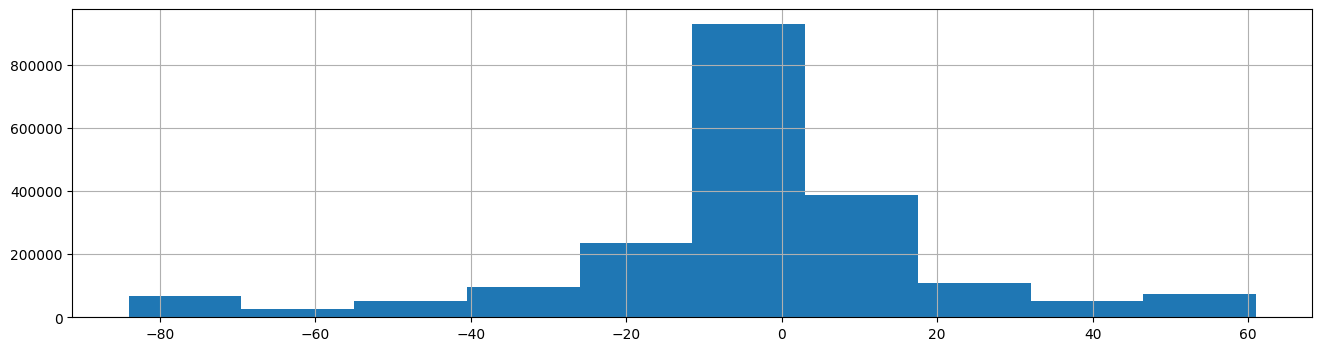

In [ ]:
spread_pdf["delta_actual_forecast_days"].clip(spread_pdf["delta_actual_forecast_days"].quantile(0.025), spread_pdf["delta_actual_forecast_days"].quantile(0.975)).hist(figsize=(16, 4))

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
filter_weeks = spread_pdf["delta_actual_forecast_weeks"] < 0

spread_pdf[filter_weeks].head()

,_id,_observ_end_dt,customer_current_mileage,customer_mileage_per_day,customer_avg_mileage_per_day,customer_last_mileage_per_day,actual_days_until_due,forecast_days_until_due,old_forecast_days_until_due,delta_actual_forecast_days,mse_days,rmse_days,delta_actual_old_forecast_days,mse_old_forecast_days,rmse_old_forecast_days,actual_weeks_until_due,forecast_weeks_until_due,old_forecast_weeks_until_due,delta_actual_forecast_weeks,mse_weeks,rmse_weeks,delta_actual_old_forecast_weeks,mse_old_forecast_weeks,rmse_old_forecast_weeks,actual_months_until_due,forecast_months_until_due,old_forecast_months_until_due,delta_actual_forecast_months,mse_months,rmse_months,delta_actual_old_forecast_months,mse_old_forecast_months,rmse_old_forecast_months
2,0005AXG__966507526206,2024-05-31,368675.0,195.035714,166.014340,150.297521,25.0,31.0,33.0,6.0,22.250000,4.716991,8.0,990.250000,31.468238,3.0,4.0,4.0,-1.0,0.500000,0.707107,-1.0,16.750000,4.092676,0.0,1.0,1.0,-1.0,0.500000,0.707107,-1.0,2.750000,1.658312
3,0005AXG__966507526206,2024-07-31,380956.0,204.683333,173.748139,195.035714,24.0,30.0,25.0,6.0,25.000000,5.000000,1.0,792.400000,28.149600,3.0,4.0,3.0,-1.0,0.600000,0.774597,0.0,13.400000,3.660601,0.0,1.0,0.0,-1.0,0.600000,0.774597,0.0,2.200000,1.483240
7,0006RSG__966530400641,2024-04-30,488517.0,31.105590,31.105590,55.000000,160.0,161.0,90.0,1.0,1.000000,1.000000,-70.0,4900.000000,70.000000,22.0,23.0,12.0,-1.0,1.000000,1.000000,10.0,100.000000,10.000000,5.0,5.0,3.0,0.0,0.000000,0.000000,2.0,4.000000,2.000000
11,0016ABD__966559405724,2024-12-31,438753.0,142.581522,112.491662,96.011111,35.0,51.0,52.0,16.0,445.250000,21.100948,17.0,1042.166667,32.282606,5.0,7.0,7.0,-2.0,9.000000,3.000000,-2.0,20.833333,4.564355,1.0,1.0,1.0,0.0,0.250000,0.500000,0.0,0.916667,0.957427
13,0016VBD__966501222843,2024-05-31,190660.0,112.195652,68.553063,63.323077,44.0,92.0,78.0,48.0,410.636364,20.264165,34.0,297.090909,17.236325,6.0,13.0,11.0,-7.0,9.090909,3.015113,-5.0,6.727273,2.593699,1.0,3.0,2.0,-2.0,0.909091,0.953463,-1.0,0.545455,0.738549


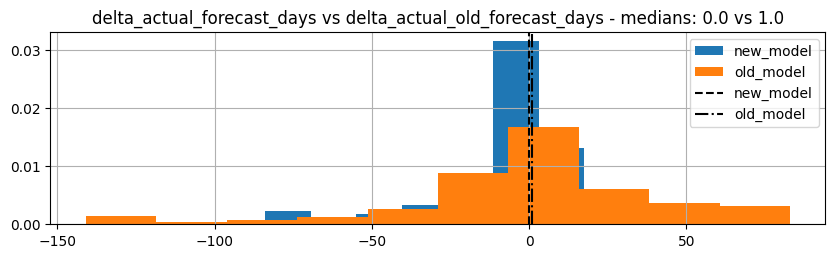

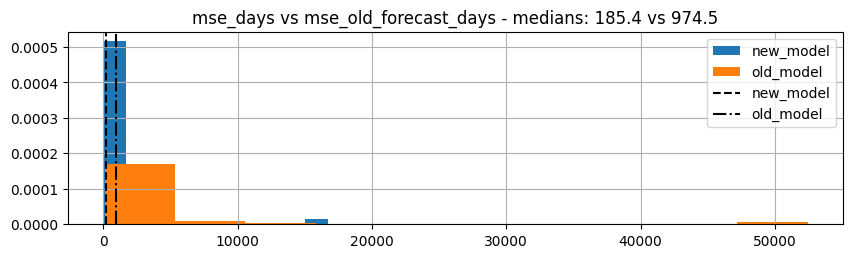

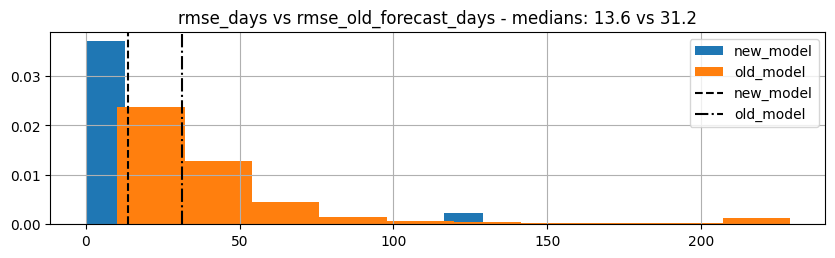

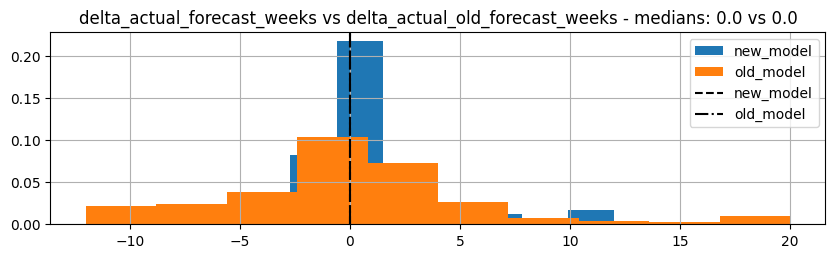

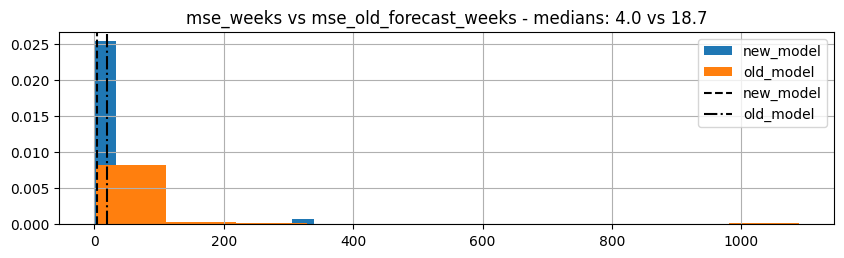

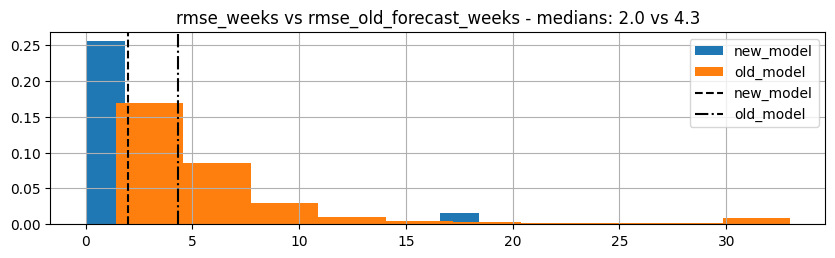

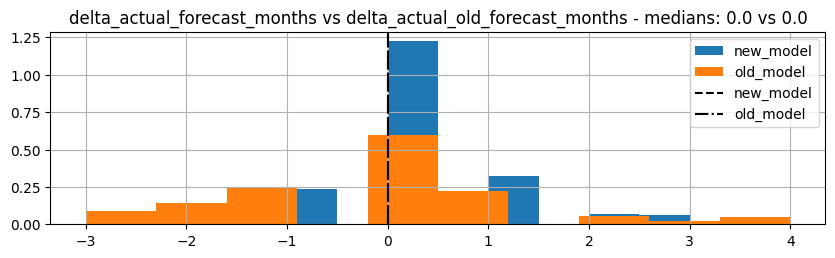

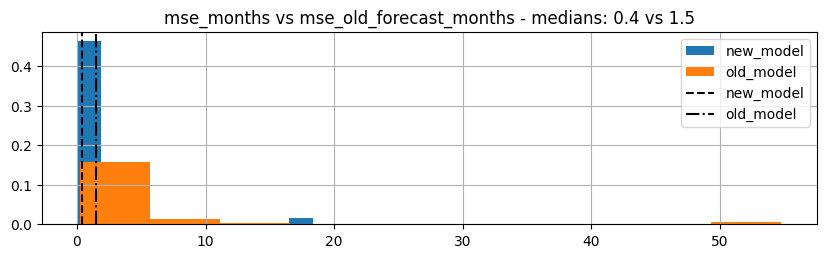

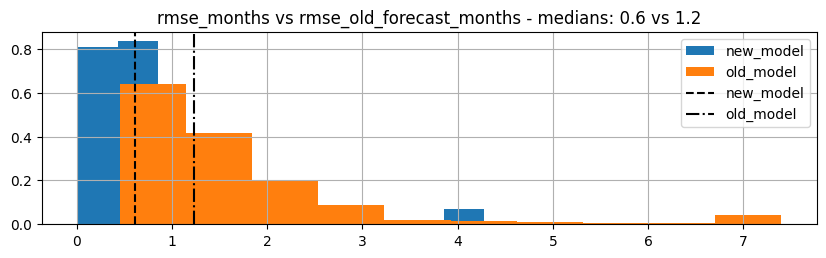

In [ ]:
col_pairs_list = [
    ["delta_actual_forecast_days", "delta_actual_old_forecast_days"],
    ["mse_days", "mse_old_forecast_days"],
    ["rmse_days", "rmse_old_forecast_days"],
    ["delta_actual_forecast_weeks", "delta_actual_old_forecast_weeks"],
    ["mse_weeks", "mse_old_forecast_weeks"],
    ["rmse_weeks", "rmse_old_forecast_weeks"],
    ["delta_actual_forecast_months", "delta_actual_old_forecast_months"],
    ["mse_months", "mse_old_forecast_months"],
    ["rmse_months", "rmse_old_forecast_months"],
]

for pair in col_pairs_list:
    col_0 = pair[0]
    col_1 = pair[1]
    ax = spread_pdf[col_0].clip(spread_pdf[col_0].quantile(0.025), spread_pdf[col_0].quantile(0.975)).hist(figsize=(10, 2.5), label="new_model", density=True)
    ax = spread_pdf[col_1].clip(spread_pdf[col_1].quantile(0.025), spread_pdf[col_1].quantile(0.975)).hist(figsize=(10, 2.5), ax=ax, label="old_model", density=True)
    col_0_median = spread_pdf[col_0].clip(spread_pdf[col_0].quantile(0.025), spread_pdf[col_0].quantile(0.975)).median()
    col_1_median = spread_pdf[col_1].clip(spread_pdf[col_1].quantile(0.025), spread_pdf[col_1].quantile(0.975)).median()
    ax.axvline(col_0_median, label="new_model", color="black", linestyle="--")
    ax.axvline(col_1_median, label="old_model", color="black", linestyle="-.")
    ax.legend()
    ax.set_title(f"{col_0} vs {col_1} - medians: {col_0_median:.1f} vs {col_1_median:.1f}")
    plt.show()

In [ ]:
col_pairs_list = [
    ["delta_actual_forecast_days", "delta_actual_old_forecast_days"],
    ["mse_days", "mse_old_forecast_days"],
    ["rmse_days", "rmse_old_forecast_days"],
    ["delta_actual_forecast_weeks", "delta_actual_old_forecast_weeks"],
    ["mse_weeks", "mse_old_forecast_weeks"],
    ["rmse_weeks", "rmse_old_forecast_weeks"],
    ["delta_actual_forecast_months", "delta_actual_old_forecast_months"],
    ["mse_months", "mse_old_forecast_months"],
    ["rmse_months", "rmse_old_forecast_months"],
]

metrics_list = [item for sublist in col_pairs_list for item in sublist]


clipped_spread_pdf = spread_pdf.copy()

for col in metrics_list:
    clipped_spread_pdf[col] = clipped_spread_pdf[col].clip(clipped_spread_pdf[col].quantile(0.025), clipped_spread_pdf[col].quantile(0.975))


In [ ]:
metrics_quantile_df = clipped_spread_pdf[metrics_list].quantile([0, 0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.975, 1])
metrics_quantile_df.index.name = "quantiles"
metrics_quantile_df

,delta_actual_forecast_days,delta_actual_old_forecast_days,mse_days,mse_old_forecast_days,rmse_days,rmse_old_forecast_days,delta_actual_forecast_weeks,delta_actual_old_forecast_weeks,mse_weeks,mse_old_forecast_weeks,rmse_weeks,rmse_old_forecast_weeks,delta_actual_forecast_months,delta_actual_old_forecast_months,mse_months,mse_old_forecast_months,rmse_months,rmse_old_forecast_months
quantiles,,,,,,,,,,,,,,,,,,
0.000,-84.0,-141.0,0.000000,106.301584,0.000000,10.310266,-9.0,-12.0,0.000000,2.000000,0.000000,1.414214,-2.0,-3.0,0.000000,0.200000,0.000000,0.447214
0.025,-84.0,-141.0,0.000000,106.304943,0.000000,10.310429,-9.0,-12.0,0.000000,2.000000,0.000000,1.414214,-2.0,-3.0,0.000000,0.200000,0.000000,0.447214
0.050,-53.0,-79.0,0.000000,181.666667,0.000000,13.478378,-5.0,-9.0,0.000000,3.666667,0.000000,1.914854,-1.0,-3.0,0.000000,0.357143,0.000000,0.597614
0.100,-31.0,-42.0,0.000000,269.368421,0.000000,16.412447,-3.0,-7.0,0.000000,5.058824,0.000000,2.249183,-1.0,-2.0,0.000000,0.500000,0.000000,0.707107
0.250,-10.0,-13.0,32.000000,481.571429,5.656854,21.944736,-1.0,-3.0,0.714286,9.100000,0.845154,3.016621,0.0,-1.0,0.000000,0.857143,0.000000,0.925820
0.500,0.0,1.0,185.400000,974.500000,13.616167,31.216983,0.0,0.0,4.000000,18.692308,2.000000,4.323460,0.0,0.0,0.375000,1.500000,0.612372,1.224745
0.750,5.0,21.0,704.800000,2305.000000,26.548070,48.010416,2.0,2.0,14.500000,45.750000,3.807887,6.763875,0.0,0.0,1.000000,3.785714,1.000000,1.945691
0.900,20.0,52.0,2501.783333,5929.000000,50.017830,77.000000,4.0,6.0,50.750000,121.000000,7.123903,11.000000,1.0,1.0,3.000000,9.000000,1.732051,3.000000
0.950,37.0,68.0,6160.500000,16430.500000,78.488853,128.181512,8.0,11.0,126.290714,341.666667,11.237914,18.484228,2.0,3.0,7.000000,16.666667,2.645751,4.082483


In [ ]:
metrics_quantile_df[[metric for metric in metrics_list if "rmse" in metric]]

,rmse_days,rmse_old_forecast_days,rmse_weeks,rmse_old_forecast_weeks,rmse_months,rmse_old_forecast_months
quantiles,,,,,,
0.000,0.000000,10.310266,0.000000,1.414214,0.000000,0.447214
0.025,0.000000,10.310429,0.000000,1.414214,0.000000,0.447214
0.050,0.000000,13.478378,0.000000,1.914854,0.000000,0.597614
0.100,0.000000,16.412447,0.000000,2.249183,0.000000,0.707107
0.250,5.656854,21.944736,0.845154,3.016621,0.000000,0.925820
0.500,13.616167,31.216983,2.000000,4.323460,0.612372,1.224745
0.750,26.548070,48.010416,3.807887,6.763875,1.000000,1.945691
0.900,50.017830,77.000000,7.123903,11.000000,1.732051,3.000000
0.950,78.488853,128.181512,11.237914,18.484228,2.645751,4.082483


In [ ]:
clipped_spread_pdf["rmse_days"].le(30).mean().round(2), clipped_spread_pdf["rmse_old_forecast_days"].le(30).mean().round(2)

(0.64, 0.39)

In [ ]:
import numpy as np

In [ ]:
clipped_spread_pdf["rmse_old_forecast_days"].quantile([i for i in np.arange(0.4, 0.5, 0.01)])

0.40    27.125224
0.41    27.534826
0.42    27.941904
0.43    28.296054
0.44    28.714108
0.45    29.071324
0.46    29.517488
0.47    29.966648
0.48    30.355303
0.49    30.818465
Name: rmse_old_forecast_days, dtype: float64

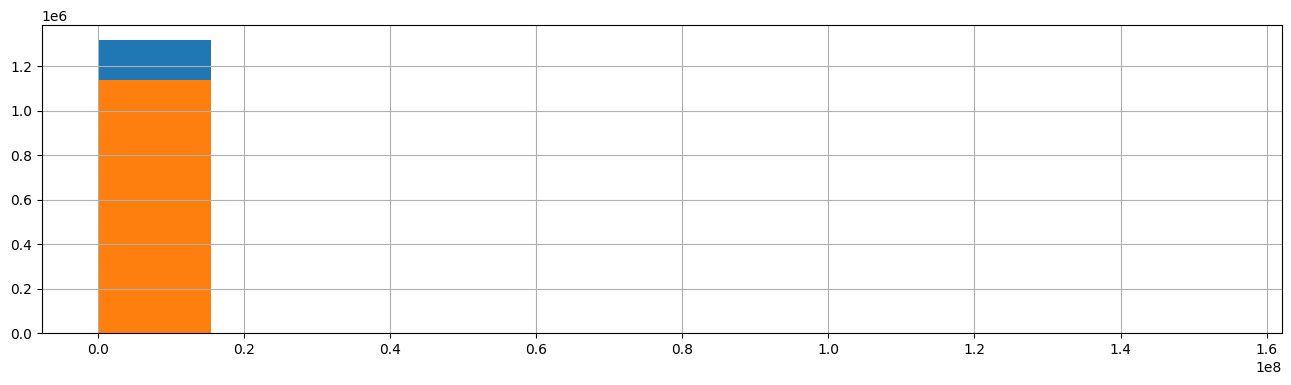

In [ ]:
ax = spread_pdf[["rmse_months", "rmse_old_forecast_months"][0]].hist(figsize=(16, 4))
ax = spread_pdf[["rmse_months", "rmse_old_forecast_months"][1]].hist(figsize=(16, 4), ax=ax)

In [ ]:
working_ids = [
    "0016VBD__966501222843",
    "1033LNB__966501030453",
    "1036LEJ__966568889070",
    "1065XJJ__966569554791",
    "1118NTA__966506100298",
    "1255RRD__966582390577",
    "1556KSD__966591539962",
]

In [ ]:
spread_df.filter(
    f.col("_id") == working_ids[0]
).select(
    "_id",
    "_observ_end_dt",
    "current_mileage",
    "oil_mileage_per_day",
    "actual_days_until_due",
    "oil_avg_mileage_per_day",
    "forecast_days_until_due",
    "delta_actual_forecast",
    "mse",
    "rmse",
).show(50, truncate=False)

+---------------------+--------------+---------------+-------------------+---------------------+-----------------------+-----------------------+---------------------+------------------+------------------+
|_id                  |_observ_end_dt|current_mileage|oil_mileage_per_day|actual_days_until_due|oil_avg_mileage_per_day|forecast_days_until_due|delta_actual_forecast|mse               |rmse              |
+---------------------+--------------+---------------+-------------------+---------------------+-----------------------+-----------------------+---------------------+------------------+------------------+
|0016VBD__966501222843|2021-04-30    |122397.0       |NULL               |NULL                 |57.0                   |NULL                   |NULL                 |NULL              |NULL              |
|0016VBD__966501222843|2021-05-31    |NULL           |NULL               |NULL                 |57.0                   |87                     |NULL                 |NULL          

In [ ]:
spread_df.filter(
    f.year("_observ_end_dt") == 2024
).filter(
    f.col("current_mileage").isNotNull()
).groupBy(
    "_observ_end_dt",
).agg(
    f.percentile("delta_actual_forecast", 0.05).alias("delta_actual_forecast_005"),
    f.percentile("delta_actual_forecast", 0.1).alias("delta_actual_forecast_010"),
    f.percentile("delta_actual_forecast", 0.5).alias("delta_actual_forecast_050"),
    f.percentile("delta_actual_forecast", 0.9).alias("delta_actual_forecast_090"),
    f.percentile("delta_actual_forecast", 0.95).alias("delta_actual_forecast_095"),

    f.percentile("mse", 0.05).alias("mse_005"),
    f.percentile("mse", 0.1).alias("mse_010"),
    f.percentile("mse", 0.5).alias("mse_050"),
    f.percentile("mse", 0.9).alias("mse_090"),
    f.percentile("mse", 0.95).alias("mse_095"),

    f.percentile("rmse", 0.05).alias("rmse_005"),
    f.percentile("rmse", 0.1).alias("rmse_010"),
    f.percentile("rmse", 0.25).alias("rmse_025"),
    f.percentile("rmse", 0.5).alias("rmse_050"),
    f.percentile("rmse", 0.75).alias("rmse_075"),
    f.percentile("rmse", 0.9).alias("rmse_090"),
    f.percentile("rmse", 0.95).alias("rmse_095"),
).show(20, truncate=False)

+--------------+-------------------------+-------------------------+-------------------------+-------------------------+-------------------------+-------+------------------+------------------+------------------+-----------------+--------+------------------+------------------+------------------+------------------+------------------+-----------------+
|_observ_end_dt|delta_actual_forecast_005|delta_actual_forecast_010|delta_actual_forecast_050|delta_actual_forecast_090|delta_actual_forecast_095|mse_005|mse_010           |mse_050           |mse_090           |mse_095          |rmse_005|rmse_010          |rmse_025          |rmse_050          |rmse_075          |rmse_090          |rmse_095         |
+--------------+-------------------------+-------------------------+-------------------------+-------------------------+-------------------------+-------+------------------+------------------+------------------+-----------------+--------+------------------+------------------+------------------+-

In [ ]:
spread_df.filter(
    f.year("_observ_end_dt") == 2024
).filter(
    f.col("current_mileage").isNotNull()
).groupBy(
    "_observ_end_dt",
).agg(
    f.percentile("delta_actual_forecast", 0.05).alias("delta_actual_forecast_005"),
    f.percentile("delta_actual_forecast", 0.1).alias("delta_actual_forecast_010"),
    f.percentile("delta_actual_forecast", 0.5).alias("delta_actual_forecast_050"),
    f.percentile("delta_actual_forecast", 0.9).alias("delta_actual_forecast_090"),
    f.percentile("delta_actual_forecast", 0.95).alias("delta_actual_forecast_095"),

    f.percentile("mse", 0.05).alias("mse_005"),
    f.percentile("mse", 0.1).alias("mse_010"),
    f.percentile("mse", 0.5).alias("mse_050"),
    f.percentile("mse", 0.9).alias("mse_090"),
    f.percentile("mse", 0.95).alias("mse_095"),

    f.percentile("rmse", 0.05).alias("rmse_005"),
    f.percentile("rmse", 0.1).alias("rmse_010"),
    f.percentile("rmse", 0.25).alias("rmse_025"),
    f.percentile("rmse", 0.5).alias("rmse_050"),
    f.percentile("rmse", 0.75).alias("rmse_075"),
    f.percentile("rmse", 0.9).alias("rmse_090"),
    f.percentile("rmse", 0.95).alias("rmse_095"),
).select(
    f.mean("delta_actual_forecast_005").alias("delta_actual_forecast_005"),
    f.mean("delta_actual_forecast_010").alias("delta_actual_forecast_010"),
    f.mean("delta_actual_forecast_050").alias("delta_actual_forecast_050"),
    f.mean("delta_actual_forecast_090").alias("delta_actual_forecast_090"),
    f.mean("delta_actual_forecast_095").alias("delta_actual_forecast_095"),

    f.mean("mse_005").alias("mse_005"),
    f.mean("mse_010").alias("mse_010"),
    f.mean("mse_050").alias("mse_050"),
    f.mean("mse_090").alias("mse_090"),
    f.mean("mse_095").alias("mse_095"),

    f.mean("rmse_005").alias("rmse_005"),
    f.mean("rmse_010").alias("rmse_010"),
    f.mean("rmse_025").alias("rmse_025"),
    f.mean("rmse_050").alias("rmse_050"),
    f.mean("rmse_075").alias("rmse_075"),
    f.mean("rmse_090").alias("rmse_090"),
    f.mean("rmse_095").alias("rmse_095"),
).show(20, truncate=False)

+-------------------------+-------------------------+-------------------------+-------------------------+-------------------------+-------+------------------+------------------+------------------+---------------+--------+------------------+-----------------+-----------------+------------------+-----------------+-----------------+
|delta_actual_forecast_005|delta_actual_forecast_010|delta_actual_forecast_050|delta_actual_forecast_090|delta_actual_forecast_095|mse_005|mse_010           |mse_050           |mse_090           |mse_095        |rmse_005|rmse_010          |rmse_025         |rmse_050         |rmse_075          |rmse_090         |rmse_095         |
+-------------------------+-------------------------+-------------------------+-------------------------+-------------------------+-------+------------------+------------------+------------------+---------------+--------+------------------+-----------------+-----------------+------------------+-----------------+-----------------+
|-36

## Client Brand table

In [ ]:
client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") == "2025-05-31"
).select(
    f.sum("oil_is_due").alias("# mineral clients due"),
    f.sum(f.when(f.col("oil_is_due_branch") == "PE", 1)).alias("# mineral clients due PE"),
    f.sum(f.when(f.col("oil_is_due_branch") == "PAC", 1)).alias("# mineral clients due PAC"),
    f.sum("oil_synthetic_is_due").alias("# synthetic clients due"),
    f.sum(f.when(f.col("oil_synthetic_is_due_branch") == "PE", 1)).alias("# synthetic clients due PE"),
    f.sum(f.when(f.col("oil_synthetic_is_due_branch") == "PAC", 1)).alias("# synthetic clients due PAC"),
).show()

+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+
|# mineral clients due|# mineral clients due PE|# mineral clients due PAC|# synthetic clients due|# synthetic clients due PE|# synthetic clients due PAC|
+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+
|              1803607|                 1588692|                   214915|                1595288|                   1404667|                     190621|
+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+



In [ ]:
client_mileage_product_forecast.filter(
    f.col("_observ_end_dt") == "2025-06-30"
).select(
    f.sum("oil_is_due").alias("# mineral clients due"),
    f.sum(f.when(f.col("oil_is_due_branch") == "PE", 1)).alias("# mineral clients due PE"),
    f.sum(f.when(f.col("oil_is_due_branch") == "PAC", 1)).alias("# mineral clients due PAC"),
    f.sum("oil_synthetic_is_due").alias("# synthetic clients due"),
    f.sum(f.when(f.col("oil_synthetic_is_due_branch") == "PE", 1)).alias("# synthetic clients due PE"),
    f.sum(f.when(f.col("oil_synthetic_is_due_branch") == "PAC", 1)).alias("# synthetic clients due PAC"),
).show()

+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+
|# mineral clients due|# mineral clients due PE|# mineral clients due PAC|# synthetic clients due|# synthetic clients due PE|# synthetic clients due PAC|
+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+
|              1880588|                 1657097|                   223491|                1661146|                   1463501|                     197645|
+---------------------+------------------------+-------------------------+-----------------------+--------------------------+---------------------------+



In [ ]:
for date in ["2025-05-31", "2025-06-30"]:
    print("date:", date)
    for cat in major_categories_list:
        print("cat:", cat)
        client_mileage_product_forecast.withColumn(
            "customer_oil",
            f.when(
                f.col("oil_last_transaction_dt").isNull(),
                f.lit("Synthetic")
            ).when(
                f.col("oil_synthetic_last_transaction_dt").isNull(),
                f.lit("Mineral")
            ).when(
                f.col("oil_synthetic_last_transaction_dt") > f.col("oil_last_transaction_dt"),
                f.lit("Synthetic")
            ).otherwise("Mineral")
        # ).withColumn(
        #     "last_transaction_dt",
        #     f.when(
        #         f.col("customer_oil") == "Mineral",
        #         f.col("oil_last_transaction_dt")
        #     ).when(
        #         f.col("customer_oil") == "Synthetic",
        #         f.col("oil_synthetic_last_transaction_dt")
        #     ).otherwise(None)
        # ).withColumn(
        #     "avg_mileage_per_day",
        #     f.when(
        #         f.col("customer_oil") == "Mineral",
        #         f.col("oil_avg_mileage_per_day")
        #     ).when(
        #         f.col("customer_oil") == "Synthetic",
        #         f.col("oil_synthetic_avg_mileage_per_day")
        #     ).otherwise(None)
        # ).withColumn(
        #     "mileage_when_due",
        #     f.when(
        #         f.col("customer_oil") == "Mineral",
        #         f.col("oil_mileage_when_due")
        #     ).when(
        #         f.col("customer_oil") == "Synthetic",
        #         f.col("oil_synthetic_mileage_when_due")
        #     ).otherwise(None)
        # ).withColumn(
        #     "is_due_branch",
        #     f.when(
        #         f.col("customer_oil") == "Mineral",
        #         f.col("oil_is_due_branch")
        #     ).when(
        #         f.col("customer_oil") == "Synthetic",
        #         f.col("oil_synthetic_is_due_branch")
        #     ).otherwise(None)
        ).filter(
            f.col("_observ_end_dt") == date
        ).filter(
            f.col(f"{cat}_is_due") > 0
        ).select(
            "_id",
            "_observ_end_dt",
            "last_mileage",
            "customer_oil",
            f"{cat}_last_transaction_dt",
            f"{cat}_avg_mileage_per_day",
            f"{cat}_mileage_when_due",
            f"{cat}_is_due_branch",
        ).write.mode("overwrite").parquet(f"data_output/mileage_model_{cat}_{date.replace("-","")}.parquet")

date: 2025-05-31
cat: oil


cat: oil_synthetic


date: 2025-06-30
cat: oil


cat: oil_synthetic


In [ ]:
client_mileage_product_forecast.filter(
    f.col("_id") == "00000E2B-FD56-4F34-A54C-159E564F5F79__FF8A2477-4270-4547-B4CB-5706EA4479A0"
).withColumn(
    "customer_oil",
    f.when(
        f.col("oil_synthetic_last_transaction_dt") > f.col("oil_last_transaction_dt"),
        f.lit("Synthetic")
    ).otherwise(f.lit("Mineral"))
).orderBy("_id", "_observ_end_dt").show(50, truncate=False)

+--------------------------------------------------------------------------+--------------+---------------+------------+-----------------------+---------------------------------+-----------------------+---------------------------------+-----------------------+---------------------+----------+--------------------+--------------+--------------+-----------------+---------------------------------+-------------------------------+--------------------+------------------------------+------------------------+------------------------+---------------------------+------------+
|_id                                                                       |_observ_end_dt|current_mileage|last_mileage|oil_avg_mileage_per_day|oil_synthetic_avg_mileage_per_day|oil_last_transaction_dt|oil_synthetic_last_transaction_dt|oil_days_since_last_trx|oil_days_until_change|oil_is_due|oil_mileage_when_due|oil_is_due_40k|oil_is_due_80k|oil_is_due_branch|oil_synthetic_days_since_last_trx|oil_synthetic_days_until_change|

# Loyal Segments

In [ ]:
win_id_transaction = Window.partitionBy("_id").orderBy("transaction_dt")

base_sales = base_sales.withColumn(
    "first_visit_dt",
    f.first("transaction_dt", ignorenulls=True).over(win_id_transaction).over(Window.unboundedPreceding, 0)
).withColumn(
    "last_visit_dt",
    f.last("transaction_dt", ignorenulls=True).over(win_id_transaction).over(Window.unboundedPreceding, 0)
).withColumn(
    "months_since_first_visit",
    f.floor(f.months_between(f.col("_observ_end_dt"), f.col("first_visit_dt")))
).withColumn(
    "months_since_last_visit",
    f.floor(f.months_between(f.col("_observ_end_dt"), f.col("last_visit_dt")))
).withColumn(
    "total_number_of_visits",
    f.countDistinct("transaction_id").over(win_id_transaction).over(Window.unboundedPreceding, 0)
).withColumn(
    "total_number_of_visits_last_12_months",
    f.countDistinct("transaction_id").over(win_id_transaction).over(-11, 0)
).withColumn(
    "expected_number_of_visits_mineral_oil",
    f.floor((f.col("currently_avg_mileage_per_day") * f.lit(365)) / 5000)
).withColumn(
    "expected_number_of_visits_synthetical_oil",
    f.floor((f.col("currently_avg_mileage_per_day") * f.lit(365)) / 10000)
).withColumn(
    "is_new_joiner",
    f.when(
        (f.col("total_number_of_visits") == 1) &
        (f.col("months_since_last_visit") <= 12) &
        (f.col("months_since_last_visit") <= 12),
        1
    ).otherwise(0)
).withColumn(
    "is_uncommited",
    f.when(
        (f.col("total_number_of_visits_last_12_months") == 1) &
        (f.col("months_since_last_visit") <= 24),
        1
    ).otherwise(0)
).withColumn(
    "is_loyal",
    f.when(
        (f.col("total_number_of_visits_last_12_months") >= 3) &
        (((f.col("customer_mineral_oil") > 0) & (f.col("total_number_of_visits_last_12_months") >= f.col("expected_number_of_visits_mineral_oil"))) |
        ((f.col("customer_synthetical_oil") > 0) & (f.col("total_number_of_visits_last_12_months") >= f.col("expected_number_of_visits_synthetical_oil"))))
        1
    ).otherwise(0)
).withColumn(
    "is_potential_loyal",
    f.when(
        (f.col("total_number_of_visits_last_12_months") >= 2) &
        (((f.col("customer_mineral_oil") > 0) & (f.col("total_number_of_visits_last_12_months") < f.col("expected_number_of_visits_mineral_oil"))) |
        ((f.col("customer_synthetical_oil") > 0) & (f.col("total_number_of_visits_last_12_months") < f.col("expected_number_of_visits_synthetical_oil"))))
        1
    ).otherwise(0)
).withColumn(
    "is_lost",
    f.when(
        (f.col("months_since_last_visit") > 12) &
        (f.col("months_since_last_visit") <= 24),
        1
    ).otherwise(0)
).withColumn(
    "is_lost",
    f.when(
        (f.col("months_since_last_visit") > 24),
        1
    ).otherwise(0)
)

## Read customer/vehicle information

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
int_vehicle = pd.read_parquet("../data/02_intermediate/int_vehicles")
int_customer = pd.read_parquet("../data/02_intermediate/int_customers")

In [ ]:
date = "2025-06-30"

In [ ]:
mileage_prediction_mineral = pd.read_parquet(f"data_output/mileage_model_oil_{date.replace("-","")}.parquet")
mileage_prediction_synthetic = pd.read_parquet(f"data_output/mileage_model_oil_synthetic_{date.replace("-","")}.parquet")

In [ ]:
int_vehicle.head(2)

,customer_vehicle_id,creation_on,modified_on,customer_id,maker,model,model_year,transmission_type,pms_name,plate_number,code_vin,is_driver_owner,station_brand,is_truck,vehicle_brand_level,_id
0,918FE112-E062-4A56-8033-000001BFCEC6,2021-03-12,2020-03-26,40AA5E88-1966-4494-B3FE-54112BF3F479,CHEVROLET,SUBURBAN,2013.0,AUTOMATIC,None,5340AAJ,1GNSC8E07DR219313,False,PE,0,LOW,40AA5E88-1966-4494-B3FE-54112BF3F479__918FE112...
1,1B4AA1DD-1E18-4990-AB45-000002BF3307,2021-03-12,2020-03-26,E1EAFA23-0ADC-4AFA-A774-4E27CDA23AA9,LEXUS,LS400,1998.0,AUTOMATIC,TOYOTA,0068LAZ,JTB530F20W0115484,False,PE,0,HIGH,E1EAFA23-0ADC-4AFA-A774-4E27CDA23AA9__1B4AA1DD...


In [ ]:
int_customer.head(2)

,customer_id,creation_on,modified_on,user_title,customer_name,mobile,mobile2,email,gender,nationality,birth_date,location_name,is_owner,is_cash_customer,payterm,age,is_active,station_brand
0,EB5670AA-72D8-49CE-8FAC-00000859EB85,2021-03-12,2020-03-26,None,ABU RAKAN,0555551397,None,None,None,None,1900-01-01,None,True,True,None,NaN,True,PE
1,4C86E939-005E-4611-B4C1-00000A03F8CA,2021-03-12,2020-03-26,None,MR OLAYYAN,0547502121,None,None,None,None,1900-01-01,None,True,True,None,NaN,True,PE


In [ ]:
mileage_prediction_mineral.head(2)

,_id,_observ_end_dt,last_mileage,customer_oil,oil_last_transaction_dt,oil_avg_mileage_per_day,oil_mileage_when_due,oil_is_due_branch
0,00000540-7986-4B85-A946-E1A9D913344F__F40BF538...,2025-06-30,90014.0,Mineral,2023-04-11 16:07:36,68.0,145162.0,PE
1,00000847-CECD-43FB-A2F9-4D4B44A8BFFC__FF645321...,2025-06-30,219209.0,Mineral,2022-07-29 17:54:54,115.0,341914.0,PE


In [ ]:
mileage_prediction_synthetic.head(2)

,_id,_observ_end_dt,last_mileage,customer_oil,oil_synthetic_last_transaction_dt,oil_synthetic_avg_mileage_per_day,oil_synthetic_mileage_when_due,oil_synthetic_is_due_branch
0,00000540-7986-4B85-A946-E1A9D913344F__F40BF538...,2025-06-30,90014.0,Mineral,NaT,68.0,145162.0,PE
1,00000847-CECD-43FB-A2F9-4D4B44A8BFFC__FF645321...,2025-06-30,219209.0,Mineral,NaT,68.0,291765.0,PE


In [ ]:
mileage_prediction_synthetic = mileage_prediction_synthetic[~mileage_prediction_synthetic["oil_synthetic_last_transaction_dt"].isnull()]
mileage_prediction_synthetic.shape

(248608, 8)

In [ ]:
mileage_prediction_mineral = mileage_prediction_mineral[~mileage_prediction_mineral["oil_is_due_branch"].isnull()]
mileage_prediction_mineral.shape

(1880588, 8)

In [ ]:
mileage_prediction_synthetic = mileage_prediction_synthetic[mileage_prediction_synthetic["oil_synthetic_last_transaction_dt"] >= "2024-01-01"]
mileage_prediction_mineral = mileage_prediction_mineral[mileage_prediction_mineral["oil_last_transaction_dt"] >= "2024-01-01"]

In [ ]:
int_vehicle["_id"] = int_vehicle["customer_id"] + "__" + int_vehicle["customer_vehicle_id"]

In [ ]:
vehicles_cols = ["_id", "customer_id", "customer_vehicle_id", "maker", "model", "model_year", "plate_number", "is_truck"]
customer_cols = ["customer_id", "mobile", "gender", "nationality"]

In [ ]:
customer_vehicle_df = pd.merge(
    int_vehicle[vehicles_cols],
    int_customer[customer_cols],
    on="customer_id",
    how="inner"
)

In [ ]:
customer_vehicle_df["plate_number"] = customer_vehicle_df["plate_number"].str.zfill(7)
customer_vehicle_df["mobile"] = customer_vehicle_df["mobile"].astype("string")
customer_vehicle_df["mobile"] = customer_vehicle_df["mobile"].str.zfill(10)
customer_vehicle_df["mobile"] = customer_vehicle_df["mobile"].str.slice_replace(stop=1, repl='966')

In [ ]:
print(int_vehicle.shape)
print(int_customer.shape)
print(customer_vehicle_df.shape)
print(mileage_prediction_mineral.shape)
print(mileage_prediction_synthetic.shape)

(7074963, 16)
(7070056, 18)
(7074963, 11)
(736284, 8)
(84858, 8)


In [ ]:
customer_vehicle_df_mineral = pd.merge(
    customer_vehicle_df,
    mileage_prediction_mineral,
    on="_id",
    how="inner"
)

print(customer_vehicle_df_mineral.shape)

(736284, 18)


In [ ]:
customer_vehicle_df_synthetic = pd.merge(
    customer_vehicle_df,
    mileage_prediction_synthetic,
    on="_id",
    how="inner"
)

print(customer_vehicle_df_synthetic.shape)

(84858, 18)


## Brand Pivot Table

In [ ]:
last_year_customer_vehicle_df = customer_vehicle_df_mineral[customer_vehicle_df_mineral["oil_last_transaction_dt"] >= "2024-01-01"].copy()

In [ ]:
last_year_customer_vehicle_df.to_excel(f"data_output/mileage_model_mineral_{date.replace("-","")}.xlsx", engine="openpyxl", index=False)

In [ ]:
branch_table = last_year_customer_vehicle_df.groupby(["oil_is_due_branch", "customer_oil"]).agg({"_id": "count"})
branch_table.unstack("oil_is_due_branch")

_id        
oil_is_due_branch    PAC      PE
customer_oil                    
Mineral            84750  626347
Synthetic           3051   22136

In [ ]:
brand_table = last_year_customer_vehicle_df[last_year_customer_vehicle_df["maker"].isin(
    ['TOYOTA', 'HYUNDAI', 'NISSAN', 'KIA', 'ISUZU', 'FORD', 'CHEVROLET', 'HONDA', 'MITSUBISHI', 'GMC', 'LEXUS', 'MAZDA', 'SUZUKI', 'CHANGAN', 'RENAULT']
)].groupby(["oil_is_due_branch", "maker", "customer_oil"]).agg({"_id": "count"})
brand_table.unstack("oil_is_due_branch").unstack("customer_oil")

_id                            
oil_is_due_branch     PAC                PE          
customer_oil      Mineral Synthetic Mineral Synthetic
maker                                                
CHANGAN               485        43    3541       292
CHEVROLET            2435       122   17576       880
FORD                 3141       169   23363      1178
GMC                  1460        51   10896       377
HONDA                2293        59   17026       552
HYUNDAI             18129       644  133299      4576
ISUZU                3525         8   26706        30
KIA                  5991       248   44027      1975
LEXUS                1461        70   10319       535
MAZDA                1342       107    9785       655
MITSUBISHI           2236        55   16495       419
NISSAN               6484       277   47530      2009
RENAULT               523        38    3708       247
SUZUKI                585        51    4364       315
TOYOTA              30976       902  230623      6501

### Synthetic

In [ ]:
date = "2025-06-30"

In [ ]:
date

'2025-06-30'

In [ ]:
last_year_customer_vehicle_df = customer_vehicle_df_synthetic[customer_vehicle_df_synthetic["oil_synthetic_last_transaction_dt"] >= "2024-01-01"].copy()

In [ ]:
last_year_customer_vehicle_df.to_excel(f"data_output/mileage_model_synthetic_{date.replace("-","")}.xlsx", engine="openpyxl", index=False)

In [ ]:
branch_table = last_year_customer_vehicle_df.groupby(["oil_synthetic_is_due_branch", "customer_oil"]).agg({"_id": "count"})
branch_table.unstack("oil_synthetic_is_due_branch")

_id       
oil_synthetic_is_due_branch   PAC     PE
customer_oil                            
Mineral                      1613  11094
Synthetic                    8536  63615

In [ ]:
brand_table = last_year_customer_vehicle_df[last_year_customer_vehicle_df["maker"].isin(
    ['TOYOTA', 'HYUNDAI', 'NISSAN', 'KIA', 'ISUZU', 'FORD', 'CHEVROLET', 'HONDA', 'MITSUBISHI', 'GMC', 'LEXUS', 'MAZDA', 'SUZUKI', 'CHANGAN', 'RENAULT']
)].groupby(["oil_synthetic_is_due_branch", "maker", "customer_oil"]).agg({"_id": "count"})
brand_table.unstack("oil_synthetic_is_due_branch").unstack("customer_oil")

_id                            
oil_synthetic_is_due_branch     PAC                PE          
customer_oil                Mineral Synthetic Mineral Synthetic
maker                                                          
CHANGAN                          14        89      97       667
CHEVROLET                        40       376     368      2706
FORD                             66       554     556      4353
GMC                              31       205     176      1546
HONDA                            35       236     260      1858
HYUNDAI                         354      1521    2396     12456
ISUZU                             9         9      45        56
KIA                             151       748     866      5166
LEXUS                            36       246     295      1836
MAZDA                            45       310     347      2122
MITSUBISHI                       26       189     225      1443
NISSAN                          157       783    1076      5890
RENAULT                          17        97     106       693
SUZUKI                           28        82     186       467
TOYOTA                          509      2509    3434     17650

# Validate transactions per month per oil kind

In [ ]:
ftr_transactions = spark.read.parquet("../data/04_feature/ftr_transactions")

In [ ]:
ftr_transactions.filter(
    f.year("_observ_end_dt") >= 2024
).groupBy("_observ_end_dt").agg(
    f.countDistinct("_id"),
    f.sum(f.when(f.col("last_trx_total_sales") > 0, 1).otherwise(0)).alias("sum sales month"),
    f.sum(f.when(
        (f.col("has_oil") > 0) & (f.col("has_oil_synthetic") < 1) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum mineral month"),
    f.sum(f.when(
        (f.col("has_oil") < 1) & (f.col("has_oil_synthetic") > 0) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum synthetic month"),
    f.sum(f.when(
        (f.col("has_oil") > 0) & (f.col("has_oil_synthetic") > 0) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum mixed month"),
    f.sum(f.when(
        (f.col("has_oil") < 1) & (f.col("has_oil_synthetic") < 1) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum none month"),
).orderBy("_observ_end_dt").show()

ftr_transactions.filter(
    f.year("_observ_end_dt") >= 2024
).filter(
    f.col("_observ_end_dt") < "2025-04-30"
).groupBy("_observ_end_dt").agg(
    f.countDistinct("_id"),
    f.sum(f.when(f.col("last_trx_total_sales") > 0, 1).otherwise(0)).alias("sum_sales_month"),
    f.sum(f.when(
        (f.col("has_oil") > 0) & (f.col("has_oil_synthetic") < 1) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum_mineral_month"),
    f.sum(f.when(
        (f.col("has_oil") < 1) & (f.col("has_oil_synthetic") > 0) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum_synthetic_month"),
    f.sum(f.when(
        (f.col("has_oil") > 0) & (f.col("has_oil_synthetic") > 0) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum_mixed_month"),
    f.sum(f.when(
        (f.col("has_oil") < 1) & (f.col("has_oil_synthetic") < 1) & (f.col("last_trx_total_sales") > 0),
        1).otherwise(0)).alias("sum_none_month"),
).select(
    f.round(f.mean("sum_sales_month")).alias("avg_sales_month"),
    f.round(f.mean("sum_mineral_month")).alias("avg_mineral_month"),
    f.round(f.mean("sum_synthetic_month")).alias("avg_synthetic_month"),
    f.round(f.mean("sum_mixed_month")).alias("avg_mixed_month"),
    f.round(f.mean("sum_none_month")).alias("avg_none_month"),
).show()

+--------------+-------------------+---------------+-----------------+-------------------+---------------+--------------+
|_observ_end_dt|count(DISTINCT _id)|sum sales month|sum mineral month|sum synthetic month|sum mixed month|sum none month|
+--------------+-------------------+---------------+-----------------+-------------------+---------------+--------------+
|    2024-01-31|            2803715|         263360|           156400|              91678|             44|         15238|
|    2024-02-29|            2845009|         254004|           152539|              85906|             20|         15539|
|    2024-03-31|            2882290|         247326|           143205|              86574|             31|         17516|
|    2024-04-30|            2919362|         245251|           138821|              84685|             37|         21708|
|    2024-05-31|            2961592|         270107|           149346|              90127|             40|         30594|
|    2024-06-30|        

+---------------+-----------------+-------------------+---------------+--------------+
|avg_sales_month|avg_mineral_month|avg_synthetic_month|avg_mixed_month|avg_none_month|
+---------------+-----------------+-------------------+---------------+--------------+
|       257582.0|         144776.0|            89489.0|           45.0|       23271.0|
+---------------+-----------------+-------------------+---------------+--------------+

